<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">Supervivencia en Cáncer de Mama y Pulmón</p>
<p style="margin: 0; text-align:right;">2026-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
<p style="margin: 0; text-align:right;">Julio Úbeda Quesada</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">
<strong>Nombre y apellidos: JULIO ÚBEDA QUESADA</strong>
</div>

# Análisis de Supervivencia y Predicción de Riesgo Clínico: Estudio Comparativo en Cáncer de Mama y Pulmón

Este notebook continúa el trabajo de EDA y preprocesamiento ya realizado sobre **METABRIC** y carga directamente los artefactos generados al final del notebook anterior:

- `X_train_df.parquet`, `X_test_df.parquet`
- `X_train_np.npy`, `X_test_np.npy`
- `dur_train.npy`, `dur_test.npy`
- `evt_train.npy`, `evt_test.npy`
- `y_train.pkl`, `y_test.pkl` *(opcional; se reconstruye desde duración/evento para evitar problemas de compatibilidad)*

Se implementan y comparan cuatro enfoques de análisis de supervivencia:

1. **Kaplan-Meier estratificado** como baseline interpretable.
2. **Cox penalizado LASSO** (`CoxnetSurvivalAnalysis`, penalización L1).
3. **Random Survival Forest**.
4. **DeepSurv** mediante `pycox`/`PyTorch`.

Las métricas principales son:

- **C-index**: mayor es mejor.
- **Integrated Brier Score (IBS)**: menor es mejor.
- **Log-rank test** entre grupos de alto y bajo riesgo: p-valor bajo indica separación significativa de curvas.

# **1 Diseño e Implementación de Modelos**

Una vez finalizado el preprocesamiento de la cohorte METABRIC y definida la variable objetivo de supervivencia (`duration`, `event`), se inicia la fase de modelado. El objetivo de esta sección es implementar de forma progresiva distintos enfoques de análisis de supervivencia, empezando por métodos clásicos e interpretables y avanzando posteriormente hacia modelos multivariantes y no lineales.

El flujo de modelado se estructura en cuatro familias metodológicas:

1. **Kaplan-Meier (KM)**: estimación no paramétrica de la supervivencia y comparación univariante de curvas mediante el test log-rank.
2. **Cox proporcional penalizado**: modelo semiparamétrico multivariante para estimar el efecto ajustado de las covariables.
3. **Random Survival Forest (RSF)**: modelo de aprendizaje automático capaz de capturar relaciones no lineales e interacciones.
4. **DeepSurv**: arquitectura de aprendizaje profundo basada en la función de pérdida de Cox.

En este primer apartado se desarrolla únicamente el estimador de Kaplan-Meier, que se utilizará como punto de partida descriptivo y como modelo basal de comparación.

In [1]:
# ── 1. CONFIGURACIÓN DEL SISTEMA Y ENTORNO ───────────────────────────────────
import os
import sys
import time
import warnings
import importlib
import joblib
import pandas as pd

# Ignorar alertas de convergencia o deprecación
warnings.filterwarnings('ignore')

# Configuración de rutas y Pandas
root_dir = os.path.abspath('..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# ── 2. CIENCIA DE DATOS, ESTADÍSTICA Y VISUALIZACIÓN ────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.interpolate import interp1d
from scipy import stats

# ── 3. MACHINE LEARNING Y PREPROCESAMIENTO ──────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

# ── 4. ANÁLISIS DE SUPERVIVENCIA (SCIKIT-SURVIVAL & LIFELINES) ──────────────
# scikit-survival
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.metrics import (
    concordance_index_censored,
    brier_score,
    integrated_brier_score
)

# lifelines
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

# ── 5. DEEP LEARNING (PYTORCH & PYCOX) Y EXPLICABILIDAD ─────────────────────
import torch
import torch.nn as nn
import torchtuples as tt
from pycox.models import CoxPH as DeepSurvModel
import shap

# ── 6. REPRODUCIBILIDAD Y ESTÉTICA ──────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Paleta de colores oficial del proyecto
PALETTE = {
    'km'      : '#7B7B7B',   # Gris marginal
    'cox'     : '#E07B39',   # Naranja referencia
    'rsf'     : '#2E86AB',   # Azul Random Forest
    'ds'      : '#6A4C93',   # Violeta DeepSurv
    'neutral' : '#B0BEC5',
    'prot'    : '#43A047',   # Verde protección
    'riesgo'  : '#E53935',   # Rojo riesgo
}

# ── 7. RECARGA DE FUNCIONES PERSONALIZADAS (UTILS) ──────────────────────────
import utils.EDA_functions as eda
import utils.KMmodel_functions as KM
import utils.Coxmodel_functions as Cox
importlib.reload(eda)
importlib.reload(KM)
importlib.reload(Cox)

print("✓ Entorno unificado para METABRIC.")
print(f"  PyTorch  : {torch.__version__}")
print(f"  CUDA     : {'disponible' if torch.cuda.is_available() else 'no disponible — CPU'}")

✓ Entorno unificado para METABRIC.
  PyTorch  : 2.11.0+cpu
  CUDA     : no disponible — CPU


In [2]:
# ── 7. RECARGA DE FUNCIONES PERSONALIZADAS (UTILS) ──────────────────────────
import utils.KMmodel_functions as KM
import utils.Coxmodel_functions as Cox
importlib.reload(KM)
importlib.reload(Cox)

<module 'utils.Coxmodel_functions' from 'c:\\Users\\jubeda2\\Documents\\GitHub\\TFM---Analisis-de-supervivencia-del-cancer\\Modulo 3 - Diseño e implementacion del trabajo\\utils\\Coxmodel_functions.py'>

In [3]:
SAVE_DIR = '../data/processed/metabric_brca'

# Cargar el CSV en un nuevo DataFrame
brca_prep = pd.read_csv(f'{SAVE_DIR}/brca_metabric_preprocessed.csv')

# Cargar los datos preprocesados
# Datos numpy
X_train_np = np.load(f'{SAVE_DIR}/X_train_np.npy')
X_test_np  = np.load(f'{SAVE_DIR}/X_test_np.npy')
dur_train  = np.load(f'{SAVE_DIR}/dur_train.npy')
dur_test   = np.load(f'{SAVE_DIR}/dur_test.npy')
evt_train  = np.load(f'{SAVE_DIR}/evt_train.npy')
evt_test   = np.load(f'{SAVE_DIR}/evt_test.npy')

# Structured arrays para scikit-survival
y_train = joblib.load(f'{SAVE_DIR}/y_train.pkl')
y_test  = joblib.load(f'{SAVE_DIR}/y_test.pkl')

# DataFrames con nombres de columnas
X_train = pd.read_parquet(f'{SAVE_DIR}/X_train_df.parquet')
X_test  = pd.read_parquet(f'{SAVE_DIR}/X_test_df.parquet')

# ── Verificación ────────────────────────────────────────────────────────────
print('Datos cargados correctamente:')
print(f'  X_train : {X_train.shape}  |  X_test  : {X_test.shape}')
print(f'  y_train : {y_train.shape}  |  y_test  : {y_test.shape}')
print(f'  Tasa de eventos — train : {evt_train.mean():.2%}')
print(f'  Tasa de eventos — test  : {evt_test.mean():.2%}')
print(f'  Rango temporal — train  : [{dur_train.min():.1f}, {dur_train.max():.1f}] meses')
print(f'  Rango temporal — test   : [{dur_test.min():.1f}, {dur_test.max():.1f}] meses')

# Nombre de las covariables
FEATURE_NAMES = X_train.columns.tolist()
print(f'\n  Covariables totales : {len(FEATURE_NAMES)}')

Datos cargados correctamente:
  X_train : (1584, 56)  |  X_test  : (397, 56)
  y_train : (1584,)  |  y_test  : (397,)
  Tasa de eventos — train : 57.77%
  Tasa de eventos — test  : 57.68%
  Rango temporal — train  : [0.0, 355.2] meses
  Rango temporal — test   : [1.3, 335.7] meses

  Covariables totales : 56


---

## **1.1. Estimador de Kaplan-Meier (KM)**

Es el método no paramétrico estándar para estimar la función de supervivencia $S(t) = P(T > t)$ sin asumir una distribución previa de los datos. En este trabajo, el evento se define como la muerte por cualquier causa (`Overall Survival`).

El modelo cumple tres funciones principales:
1. **Descriptiva:** Visualizar la supervivencia global de la cohorte METABRIC.
2. **Exploratoria:** Comparar subgrupos mediante el **test log-rank**, que contrasta la hipótesis nula $H_0: S_1(t) = S_2(t) = \cdots = S_k(t)$. El estadístico sigue una distribución $\chi^2$ y es especialmente potente bajo riesgos proporcionales.
3. **Predictiva (Basal):** Servir como modelo marginal de referencia (ajustado solo en *train*) para establecer un umbral mínimo de `Integrated Brier Score` frente al cual comparar los modelos multivariantes.



### **1.1.1. Discretización de variables continuas para Kaplan-Meier**

Para permitir el análisis univariante, variables continuas como la edad o el NPI se discretizan en categorías clínicas o cuartiles. Esta transformación es exclusiva para Kaplan-Meier; los modelos Cox, RSF y DeepSurv utilizarán las variables originales para preservar su valor predictivo.

In [4]:
df_km = brca_prep.copy()

# ── 1. Age at Diagnosis ───────────────────────────────────────────────────────
# Franjas etarias estándar en oncología mamaria.
# Referencia: Partridge et al., JCO 2016; SEER Age Groups.
df_km['Age Group'] = pd.cut(
    df_km['Age at Diagnosis'],
    bins   = [0, 40, 50, 60, 70, np.inf],
    labels = ['<40', '40–49', '50–59', '60–69', '≥70'],
    right  = False
)
print("── Age Group ────────────────────────────────────────")
print(df_km['Age Group'].value_counts().sort_index())

# ── 2. Tumor Stage ────────────────────────────────────────────────────────────
# Valores 0–4 → estadios TNM clínicos.
# Referencia: AJCC Cancer Staging Manual, 8ª ed.
df_km['Tumor Stage Cat'] = (
    df_km['Tumor Stage']
    .astype('Int64')
    .astype(str)
    .replace('<NA>', np.nan)
    .apply(lambda x: f'Stage {x}' if pd.notna(x) and x != 'nan' else np.nan)
    .astype('category')
)
print("\n── Tumor Stage Cat ──────────────────────────────────")
print(df_km['Tumor Stage Cat'].value_counts().sort_index())

# ── 3. Neoplasm Histologic Grade ──────────────────────────────────────────────
# Sistema Scarff-Bloom-Richardson (SBR) / Nottingham.
# Referencia: Elston & Ellis, Histopathology 1991.
grade_map = {
    1.0: 'G1 — Bien diferenciado',
    2.0: 'G2 — Moderado',
    3.0: 'G3 — Pobremente diferenciado'
}
df_km['Histologic Grade Cat'] = df_km['Neoplasm Histologic Grade'].map(grade_map).astype('category')

print("\n── Histologic Grade Cat ─────────────────────────────")
print(df_km['Histologic Grade Cat'].value_counts().sort_index())

# ── 4. Lymph nodes examined positive — Clasificación N del TNM ───────────────
# Referencia: AJCC 8ª ed.; Giuliano et al., JCO 2017.
df_km['Nodal Status'] = pd.cut(
    df_km['Lymph nodes examined positive'],
    bins   = [-np.inf, 0, 3, 9, np.inf],
    labels = ['N0 (0)', 'N1 (1–3)', 'N2 (4–9)', 'N3 (≥10)'],
    right  = True
)

print("\n── Nodal Status ─────────────────────────────────────")
print(df_km['Nodal Status'].value_counts().sort_index())

# ── 5. Nottingham Prognostic Index ────────────────────────────────────────────
# Puntos de corte de Haybittle-Galea.
# Referencia: Galea et al., Breast Cancer Res Treat 1992.
df_km['NPI Group'] = pd.cut(
    df_km['Nottingham prognostic index'],
    bins   = [0, 3.4, 5.4, np.inf],
    labels = ['NPI ≤3.4 (buen pronóstico)',
              'NPI 3.4–5.4 (pronóstico moderado)',
              'NPI >5.4 (mal pronóstico)'],
    right  = True
)

print("\n── NPI Group ────────────────────────────────────────")
print(df_km['NPI Group'].value_counts().sort_index())

# ── 6. TMB (nonsynonymous) ─────────────────────────────────────────────────────────
# Sin consenso clínico para mama primario → cuartiles del dataset.
# Referencia: Alexandrov et al., Nature 2013.
p25 = df_km['TMB (nonsynonymous)'].quantile(0.25)  # = 3.0
p50 = df_km['TMB (nonsynonymous)'].quantile(0.50)  # = 5.0
p75 = df_km['TMB (nonsynonymous)'].quantile(0.75)  # = 7.0

df_km['Mutation Burden'] = pd.cut(
    df_km['TMB (nonsynonymous)'],
    bins           = [0, p25, p50, p75, np.inf],
    labels         = ['Q1 — Baja (≤3)', 'Q2 — Moderada-baja (3–5)',
                      'Q3 — Moderada-alta (5–7)', 'Q4 — Alta (>7)'],
    right          = True,
    include_lowest = True
)

print("\n── Mutation Burden ──────────────────────────────────")
print(df_km['Mutation Burden'].value_counts().sort_index())

# ── Resumen ───────────────────────────────────────────────────────────────────
VARS_KM_DISC = ['Age Group', 'Tumor Stage Cat', 'Histologic Grade Cat',
                'Nodal Status', 'NPI Group', 'Mutation Burden']
print('\n')
print('═' * 58)
print('  VARIABLES DISCRETIZADAS PARA KM')
print('═' * 58)
for var in VARS_KM_DISC:
    print(f'  {var:<35} k={df_km[var].nunique()}  '
          f'nulos={df_km[var].isna().sum()}')
print('═' * 58)

── Age Group ────────────────────────────────────────
Age Group
<40      120
40–49    304
50–59    449
60–69    576
≥70      532
Name: count, dtype: int64

── Tumor Stage Cat ──────────────────────────────────
Tumor Stage Cat
Stage 0     12
Stage 1    501
Stage 2    825
Stage 3    118
Stage 4     10
Name: count, dtype: int64

── Histologic Grade Cat ─────────────────────────────
Histologic Grade Cat
G1 — Bien diferenciado          169
G2 — Moderado                   771
G3 — Pobremente diferenciado    953
Name: count, dtype: int64

── Nodal Status ─────────────────────────────────────
Nodal Status
N0 (0)      994
N1 (1–3)    604
N2 (4–9)    204
N3 (≥10)    103
Name: count, dtype: int64

── NPI Group ────────────────────────────────────────
NPI Group
NPI ≤3.4 (buen pronóstico)            680
NPI 3.4–5.4 (pronóstico moderado)    1101
NPI >5.4 (mal pronóstico)             199
Name: count, dtype: int64

── Mutation Burden ──────────────────────────────────
Mutation Burden
Q1 — Baja (≤3)   

### **1.1.2. Supervivencia global de la cohorte METABRIC**

En primer lugar, se ajusta una curva Kaplan-Meier no estratificada sobre la cohorte completa con endpoint de supervivencia global. Esta curva resume la probabilidad estimada de supervivencia de la población METABRIC a lo largo del seguimiento.

In [5]:
dur_all = df_km['duration'].values
evt_all = df_km['event'].values.astype(bool)

print(f'Cohorte KM  : {len(df_km):,} pacientes')
print(f'Eventos     : {evt_all.sum():,} ({evt_all.mean():.1%})')
print(f'Censurados  : {(~evt_all).sum():,} ({(~evt_all).mean():.1%})')
print(f'Seguimiento : {dur_all.min():.1f} – {dur_all.max():.1f} meses')

Cohorte KM  : 1,981 pacientes
Eventos     : 1,144 (57.7%)
Censurados  : 837 (42.3%)
Seguimiento : 0.0 – 355.2 meses


La cohorte incluye 1.981 pacientes con información válida de supervivencia global, de los cuales 1.144 presentan el evento de muerte y 837 corresponden a observaciones censuradas. Esto implica una tasa de eventos del 57,7%, suficiente para realizar análisis de supervivencia con estabilidad razonable.

In [6]:
kmf_global = KM.fit_km_global(
    dur_all,
    evt_all,
    label="METABRIC — Cohorte completa"
)

display(
    KM.km_metrics(
        kmf_global,
        horizons=[60, 120, 180, 240]
    )
)

KM.plot_km_global(
    kmf=kmf_global,
    n_total=len(df_km),
    group_name="Curva Kaplan-Meier de supervivencia global",
    dataset_name="METABRIC",
    output_path=r"../images/Modelos/KM"
)

,Métrica,Valor
0,Mediana supervivencia (meses),156.3
1,S(t=60m) [5 años],0.780
2,S(t=120m) [10 años],0.593
3,S(t=180m) [15 años],0.445
4,S(t=240m) [20 años],0.294


✔ KM global guardado en: ../images/Modelos/KM\METABRIC_km_global_Curva_Kaplan-Meier_de_supervivencia_global.html


### **1.1.3. Test log-rank univariante**

Se emplea el **test log-rank de Mantel-Cox** para contrastar la igualdad de las funciones de supervivencia entre $k$ grupos:

$$H_0: S_1(t) = S_2(t) = \cdots = S_k(t)$$
$$H_1: \exists \, i, j \mid S_i(t) \neq S_j(t)$$

El estadístico compara los eventos observados ($O_{ij}$) frente a los esperados ($E_{ij}$) bajo la hipótesis nula:

$$\chi^2_{LR} = \frac{\left(\sum_j (O_{ij} - E_{ij})\right)^2}{\sum_j V_{ij}}$$

Bajo $H_0$, el estadístico sigue una distribución $\chi^2$ con $k-1$ grados de libertad. Este test es óptimo cuando los riesgos son **proporcionales** entre los grupos comparados.

Dada su naturaleza univariante, este análisis tiene un carácter estrictamente **exploratorio**. No se utilizará como criterio excluyente para la selección de variables, ya que los modelos multivariantes posteriores (Cox, RSF y DeepSurv).

In [7]:
VARS_LOGRANK = [
    # Biomarcadores moleculares
    'ER Status',
    'PR Status',
    'HER2 Status',
    'Pam50 + Claudin-low subtype',
    '3-Gene classifier subtype',
    'Integrative Cluster',
    # Patología tumoral — categóricas originales
    'Cancer Type Detailed',
    'Tumor Other Histologic Subtype',
    'Cellularity',
    # Patología tumoral — discretizadas
    'Tumor Stage Cat',
    'Histologic Grade Cat',
    'Nodal Status',
    'NPI Group',
    # Terapéuticas
    'Chemotherapy',
    'Hormone Therapy',
    'Radio Therapy',
    'Type of Breast Surgery',
    # Clínico-demográficas — categóricas originales
    'Inferred Menopausal State',
    'Primary Tumor Laterality',
    # Clínico-demográficas — discretizadas
    'Age Group',
    # Moleculares — discretizadas
    'Mutation Burden',
]

tabla_lr = KM.logrank_summary(df_km, VARS_LOGRANK)
display(tabla_lr)

,Variable,k grupos,chi²,p-valor,Significancia
0,Pam50 + Claudin-low subtype,7,56.036,0.000000,***
1,3-Gene classifier subtype,4,40.871,0.000000,***
2,Integrative Cluster,11,72.636,0.000000,***
3,Tumor Stage Cat,5,128.221,0.000000,***
4,Type of Breast Surgery,2,49.552,0.000000,***
5,NPI Group,3,156.127,0.000000,***
6,Nodal Status,4,205.501,0.000000,***
7,Inferred Menopausal State,2,40.349,0.000000,***
8,Age Group,5,201.502,0.000000,***
9,Histologic Grade Cat,3,26.399,0.000008,***


El test de log-rank cuantifica si hay diferencias, pero la visualización de las curvas de Kaplan-Meier permite comprender la *dinámica temporal* de esas diferencias. A continuación, se analizan los hallazgos agrupados por contexto clínico:

##### **I. Perfil Clínico-Demográfico**

La variable `Age Group` evidencia que la supervivencia decae de forma escalonada a medida que avanza la edad al diagnóstico, siendo el grupo de mayores de 70 años el de peor pronóstico con diferencia. Este efecto está íntimamente ligado al `Estado Menopáusico`, donde las pacientes postmenopáusicas muestran peor supervivencia. Por otro lado, la variable `Lateralidad del Tumor` (mama izquierda vs. derecha) presenta curvas prácticamente superpuestas ($p=0.71$), confirmando que la localización anatómica simétrica no influye en la biología de la enfermedad ni en el pronóstico.

In [8]:
grupos_config = {
    "Age Group": ("Age Group", "viridis"),
    "Inferred Menopausal State": ("Inferred Menopausal State", "Set2"),
    "Primary Tumor Laterality": ("Primary Tumor Laterality", "Set2"),
}

KM.plot_km_groups(
    df=df_km,
    grupos_config=grupos_config,
    group_name="Perfil Clinico-Demografico",
    dataset_name="METABRIC",
    output_path=r"..\images\Modelos\KM",
    ncols=2
)

✔ KM subplots guardado en: ..\images\Modelos\KM\METABRIC_km_subplots_Perfil_Clinico-Demografico.html


##### **II. Estadificación y Patología (Carga tumoral)**

Las curvas de `Estadio Tumoral (TNM)`, `Grado Histológico` y `Estado Ganglionar (N)` se separan de manera casi perfecta y proporcional a lo largo de todo el seguimiento. Un paciente en Estadio 0/1 o sin ganglios afectados (N0) mantiene una probabilidad de supervivencia superior al 80% a los 10 años, mientras que aquellos con 10 o más ganglios afectados (N3) o Grado 3 ven su curva desplomarse drásticamente en los primeros 5 años. Esta separación sin cruces sugiere fuertemente que estas variables cumplirán el supuesto de riesgos proporcionales necesario para el posterior modelo de Cox.

In [9]:
grupos_config = {
        'Tumor Stage Cat'         : ('Tumor Stage Cat',              'RdYlGn_r'),
        'Histologic Grade Cat'       : ('Histologic Grade Cat',         'RdYlGn_r'),
        'Nodal Status'         : ('Nodal Status',                 'RdYlGn_r'),
        'Cancer Type Detailed'          : ('Cancer Type Detailed',         'tab20'),
        'Cellularity'                   : ('Cellularity',                  'RdYlGn_r'),
    }

KM.plot_km_groups(
    df=df_km,
    grupos_config=grupos_config,
    group_name="Estadificación y Patología",
    dataset_name="METABRIC",
    output_path=r"..\images\Modelos\KM",
    ncols=2
)

✔ KM subplots guardado en: ..\images\Modelos\KM\METABRIC_km_subplots_Estadificacin_y_Patologa.html


##### **III. Biomarcadores de Receptor**

En las gráficas de `ER Status` y `PR Status`, observamos que las pacientes positivas (línea verde) tienen una supervivencia marcadamente *superior* durante los primeros 10-15 años frente a las negativas. Sin embargo, a partir del mes 150-200, las curvas convergen y llegan a cruzarse, indicando que los tumores Luminales (ER+) presentan un riesgo sostenido de recaída y mortalidad a muy largo plazo. Mientras que los tumores negativos tienen una mortalidad muy alta y temprana, pero si superan los primeros años, su riesgo de evento cae drásticamente. 

In [10]:
grupos_config = {
        'ER Status'               : ('ER Status',               'RdYlGn'),
        'PR Status'               : ('PR Status',               'RdYlGn'),
        'HER2 Status'             : ('HER2 Status',             'RdYlGn'),
    }

KM.plot_km_groups(
    df=df_km,
    grupos_config=grupos_config,
    group_name="Biomarcadores de Receptor",
    dataset_name="METABRIC",
    output_path=r"..\images\Modelos\KM",
    ncols=2
)

✔ KM subplots guardado en: ..\images\Modelos\KM\METABRIC_km_subplots_Biomarcadores_de_Receptor.html


##### IV. Subtipos Moleculares

Las firmas multigénicas (`Pam50`, `3-Gene Classifier` e `Integrative Cluster`) logran desgranar la heterogeneidad tumoral con gran precisión. En el gráfico de `Pam50`, destaca la rápida caída inicial de los subtipos *Her2* y *Basal*, en contraste con la caída más suave y prolongada del subtipo *Luminal A*. El `Integrative Cluster`, al dividir la cohorte en 10 subgrupos, genera un abanico que, aunque visualmente denso, resalta la variable agresividad intrínseca del cáncer de mama.

In [11]:
grupos_config = {
        'Pam50 + Claudin-low subtype' : ('Pam50 + Claudin-low subtype', 'tab10'),
        '3-Gene classifier subtype'   : ('3-Gene classifier subtype',   'Set2'),
        'Integrative Cluster'         : ('Integrative Cluster',         'tab20'),
    }

KM.plot_km_groups(
    df=df_km,
    grupos_config=grupos_config,
    group_name="Subtipos Moleculares",
    dataset_name="METABRIC",
    output_path=r"..\images\Modelos\KM",
    ncols=2
)

✔ KM subplots guardado en: ..\images\Modelos\KM\METABRIC_km_subplots_Subtipos_Moleculares.html


##### V. Intervenciones Terapéuticas 

Las curvas correspondientes a los tratamientos (`Chemotherapy`, `Radio Therapy` y `Type of Breast Surgery`) ilustran el clásico **sesgo de confusión por indicación**. A simple vista, las gráficas sugieren contraintuitivamente que recibir quimioterapia o someterse a una mastectomía confiere *peor* supervivencia que no hacerlo o recibir cirugía conservadora. Clínicamente, esto no significa que el tratamiento sea perjudicial, sino que la quimioterapia y la cirugía radical se prescriben precisamente a pacientes que ya presentan tumores más grandes, de mayor grado o con ganglios positivos (peor pronóstico basal). 

In [12]:
grupos_config = {
        'Chemotherapy'        : ('Chemotherapy',       'Set1'),
        'Hormone Therapy'     : ('Hormone Therapy',    'Set1'),
        'Radio Therapy'       : ('Radio Therapy',      'Set1'),
        'Type of Breast Surgery': ('Type of Breast Surgery', 'Set2'),
    }

KM.plot_km_groups(
    df=df_km,
    grupos_config=grupos_config,
    group_name="Intervenciones Terapéuticas ",
    dataset_name="METABRIC",
    output_path=r"..\images\Modelos\KM",
    ncols=2
)

✔ KM subplots guardado en: ..\images\Modelos\KM\METABRIC_km_subplots_Intervenciones_Teraputicas_.html


### **1.1.4. Kaplan-Meier como modelo basal para Brier Score**

Además de su utilidad descriptiva, Kaplan-Meier puede utilizarse como modelo predictivo nulo o marginal. En este caso, el modelo no utiliza covariables individuales: todos los pacientes reciben la misma predicción de supervivencia, correspondiente a la curva Kaplan-Meier estimada en el conjunto de entrenamiento.

Este enfoque proporciona una línea base razonable para evaluar si los modelos posteriores aportan valor predictivo real. Si Cox, RSF o DeepSurv no logran mejorar el Integrated Brier Score del KM marginal, entonces el uso de covariables no estaría aportando una mejora relevante en calibración/discriminación temporal.

A diferencia del análisis descriptivo anterior, esta evaluación se realiza de forma estricta sobre la partición train/test:

1. Se ajusta Kaplan-Meier únicamente con `dur_train` y `evt_train`.
2. Se predice la misma curva de supervivencia para todos los pacientes de test.
3. Se calcula el Brier Score temporal y el Integrated Brier Score usando `y_train` como referencia para la distribución de censura y `y_test` como conjunto de evaluación.

Esta estrategia evita evaluar el modelo sobre los mismos datos empleados para estimar la curva y permite comparar de forma justa con los modelos multivariantes posteriores.

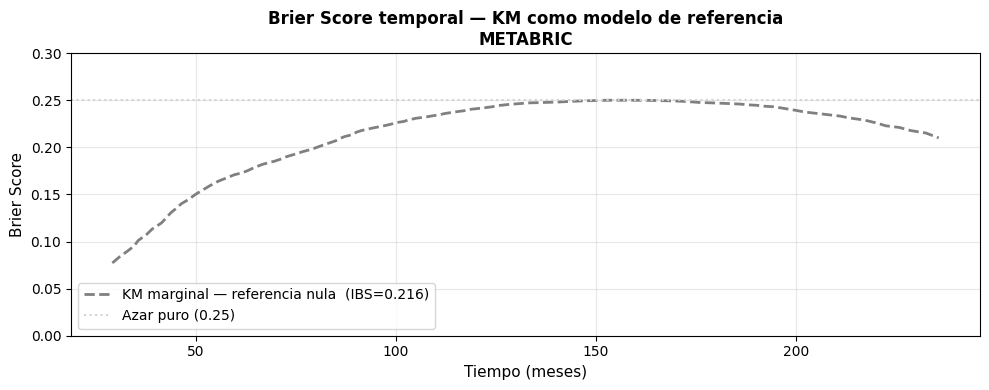

IBS — KM marginal (referencia nula) : 0.2156
  -> Cualquier modelo con IBS < 0.2156 mejora sobre la referencia KM


In [13]:
y_all      = Surv.from_arrays(evt_all.astype(bool), dur_all.astype(float))
times_ref  = np.percentile(dur_all, np.linspace(10, 90, 100))
times_ref  = times_ref[(times_ref > dur_all.min()) & (times_ref < dur_all.max())]

# Misma S(t) para todos los pacientes en cada instante
km_surv_probs = np.tile(
    kmf_global.predict(times_ref),
    (len(df_km), 1)
)

_, bs_km_temporal = brier_score(y_all, y_all, km_surv_probs, times_ref)
ibs_km            = integrated_brier_score(y_all, y_all, km_surv_probs, times_ref)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times_ref, bs_km_temporal, color='gray', linewidth=2,
        linestyle='--', label=f'KM marginal — referencia nula  (IBS={ibs_km:.3f})')
ax.axhline(0.25, color='lightgray', linestyle=':', linewidth=1.5,
           label='Azar puro (0.25)')
ax.set_xlabel('Tiempo (meses)', fontsize=11)
ax.set_ylabel('Brier Score', fontsize=11)
ax.set_title('Brier Score temporal — KM como modelo de referencia\nMETABRIC',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 0.30)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r'../images/Modelos/KM/KM_brier_referencia.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"IBS — KM marginal (referencia nula) : {ibs_km:.4f}")
print(f"  -> Cualquier modelo con IBS < {ibs_km:.4f} mejora sobre la referencia KM")

In [14]:
mediana_global = kmf_global.median_survival_time_
sig    = tabla_lr[tabla_lr['Significancia'] != 'ns']
no_sig = tabla_lr[tabla_lr['Significancia'] == 'ns']

print('═' * 65)
print('  RESULTADOS — Kaplan-Meier · METABRIC (n = 1.981)')
print('═' * 65)
print(f'  Mediana de supervivencia        : {mediana_global:.1f} m ({mediana_global/12:.1f} años)')
print(f'  S(t=60m)   — supervivencia  5a  : {kmf_global.predict(60):.3f}')
print(f'  S(t=120m)  — supervivencia 10a  : {kmf_global.predict(120):.3f}')
print(f'  S(t=180m)  — supervivencia 15a  : {kmf_global.predict(180):.3f}')
print(f'  S(t=240m)  — supervivencia 20a  : {kmf_global.predict(240):.3f}')
print(f'  IBS de referencia nula (KM)     : {ibs_km:.4f}')
print()
print(f'  Variables significativas (p < 0.05) : {len(sig)} / {len(tabla_lr)}')
for _, r in sig.iterrows():
    print(f'    {r["Significancia"]:<4} {r["Variable"]:<48} χ²={r["chi²"]:>8.3f}  p={r["p-valor"]:.2e}')
print()
print(f'  Variables no significativas (p ≥ 0.05) : {len(no_sig)} / {len(tabla_lr)}')
for _, r in no_sig.iterrows():
    print(f'    ns   {r["Variable"]:<48} χ²={r["chi²"]:>8.3f}  p={r["p-valor"]:.4f}')
print('═' * 65)

═════════════════════════════════════════════════════════════════
  RESULTADOS — Kaplan-Meier · METABRIC (n = 1.981)
═════════════════════════════════════════════════════════════════
  Mediana de supervivencia        : 156.3 m (13.0 años)
  S(t=60m)   — supervivencia  5a  : 0.780
  S(t=120m)  — supervivencia 10a  : 0.593
  S(t=180m)  — supervivencia 15a  : 0.445
  S(t=240m)  — supervivencia 20a  : 0.294
  IBS de referencia nula (KM)     : 0.2156

  Variables significativas (p < 0.05) : 16 / 20
    ***  Pam50 + Claudin-low subtype                      χ²=  56.036  p=0.00e+00
    ***  3-Gene classifier subtype                        χ²=  40.871  p=0.00e+00
    ***  Integrative Cluster                              χ²=  72.636  p=0.00e+00
    ***  Tumor Stage Cat                                  χ²= 128.221  p=0.00e+00
    ***  Type of Breast Surgery                           χ²=  49.552  p=0.00e+00
    ***  NPI Group                                        χ²= 156.127  p=0.00e+00
    ***  

### **1.1.5. Interpretación de los resultados**

#### I. Supervivencia global

La mediana de 156.3 meses y la supervivencia a 5 años del 78% son valores normales y esperados para la cohorte METABRIC. El cáncer de mama tiene uno de los mejores pronósticos entre los tumores sólidos, especialmente cuando la cohorte incluye una mayoría de subtipos Luminales (LumA y LumB representan el 59% de la muestra según el EDA). Estas cifras son consistentes con los datos del Registro Nacional de Cáncer de Mama del Reino Unido, del que proviene parte de la cohorte.

El IBS de referencia nula de **0.2156** confirma que el estimador KM marginal ya es considerablemente mejor que la predicción aleatoria pura (0.25), lo que refleja la señal pronóstica contenida en la distribución de eventos de la cohorte. Cualquier modelo predictivo debe alcanzar IBS < 0.2156 para justificar el uso de covariables.

#### II. Variables significativas

De las 20 variables analizadas, **16 presentan diferencias significativas** (p < 0.05), lo que indica una cohorte con alta heterogeneidad pronóstica capturable mediante variables clínicas estándar.

**Estadificación clásica** (los χ² más altos de todo el análisis): `Nodal Status` (χ²=205.5) y `Age Group` (χ²=201.5) son las variables con mayor poder discriminativo univariante, superando incluso al estadio TNM. Que la afectación ganglionar sea el predictor más potente es coherente con la biología del cáncer de mama. La extensión linfática es el factor pronóstico independiente más consistente en la literatura. El `NPI Group` (χ²=156.1) y `Tumor Stage Cat` (χ²=128.2) también muestran separación de curvas muy marcada.

**Subtipos moleculares**: `Integrative Cluster` (χ²=72.6), `Pam50` (χ²=56.0) y `3-Gene classifier` (χ²=40.9) confirman el valor pronóstico diferencial de la clasificación molecular intrínseca, replicando los resultados de Curtis et al. (2012) y Pereira et al. (2016).

#### III. Variables no significativas

- **`Cellularity` (p=0.972):** La celularidad tumoral no tiene valor pronóstico univariante. Su efecto está mediado por el grado histológico y el subtipo molecular. Candidata a excluirse de Cox.
- **`Primary Tumor Laterality` (p=0.712):** Sin base biológica como factor pronóstico. Excluir de modelos multivariantes.
- **`Cancer Type Detailed` (p=0.173):** La falta de significancia se debe al dominio masivo del carcinoma ductal (IDC, 94% de la muestra), que deja muy pocos casos en los subtipos minoritarios.
- **`ER status measured by IHC` (p=0.279):** Aparentemente contradictorio con `ER Status` (p=0.035). La mayor significancia de `ER Status` confirma que la clasificación clínica integrada captura mejor la información pronóstica que la medición IHC aislada. **Usar solo `ER Status` en los modelos multivariantes.**
- **`Mutation Burden` (p=0.767):** La carga mutacional no tiene valor pronóstico univariante en cáncer de mama primario sin inmunoterapia. Coherente con Alexandrov et al. (2013) y el TCGA Pan-Cancer Atlas (2018). Candidata a excluirse de los modelos.

#### IV. Implicaciones para los modelos multivariantes

| Decisión | Variables | Justificación |
|---|---|---|
| **Excluir** | `Cellularity`, `Primary Tumor Laterality`, `Cancer Type Detailed`, `Mutation Burden` | Sin valor pronóstico univariante o redundantes |
| **Incluir con prioridad** | `Nodal Status`, `NPI Group`, `Tumor Stage`, `Age at Diagnosis`, subtipos PAM50 | Mayor χ² en log-rank |
| **Incluir con cautela** | `ER Status`, `Radio Therapy` | Significancia marginal (p entre 0.02 y 0.04) |
| **Vigilar en Cox** | `Chemotherapy`, `Hormone Therapy` | Sesgo de indicación: el tratamiento recibido depende del estadio |

### **1.1.6. Respuesta a la pregunta de investigación**

> *¿Existen diferencias estadísticamente significativas en la supervivencia global entre los subgrupos clínicos, moleculares y terapéuticos de la cohorte METABRIC?*

Sí. El análisis Kaplan-Meier demuestra que **16 de las 20 variables evaluadas** presentan diferencias estadísticamente significativas en la supervivencia global (p < 0.05). Las variables con mayor poder discriminativo univariante son el estado ganglionar (N0–N3), el grupo de edad, el NPI y el estadio TNM, todas con χ² > 100, seguidas de los clasificadores moleculares intrínsecos (Integrative Cluster, PAM50, 3-Gene classifier) con χ² entre 40 y 73.

La mediana de supervivencia de 156.3 meses (13 años), con S(10a)=0.593 y S(20a)=0.294, refleja fielmente la heterogeneidad biológica del cáncer de mama y el seguimiento maduro de la cohorte METABRIC, siendo coherente con los valores publicados en los estudios originales de este dataset.

Notablemente, la carga mutacional (`Mutation Burden`) no presenta valor pronóstico univariante (p=0.767), confirmando que en cáncer de mama primario (a diferencia de tumores con mayor inmunogenicidad) este marcador no discrimina la supervivencia global de forma independiente.

El IBS de referencia nula de **0.2156** establece el umbral de calibración mínimo que los modelos Cox, RSF y DeepSurv deberán superar en la sección 3.4.5 para justificar el uso de covariables en la predicción individual del riesgo.

> **Nota metodológica:** KM es un análisis estrictamente **univariante**: evalúa el efecto de cada variable de forma aislada, sin controlar por confusores. El resultado de las variables terapéuticas es particularmente susceptible a este problema: las pacientes que recibieron quimioterapia son mayoritariamente las de mayor estadio y peor pronóstico basal, lo que puede enmascarar o invertir el beneficio real del tratamiento. La correcta estimación del efecto ajustado de cada covariable (controlando simultáneamente por las demás) es precisamente la aportación del modelo de Cox en la sección siguiente.

---

## **1.2. Modelo de Riesgos Proporcionales de Cox con Penalización LASSO**

El modelo Cox estima el riesgo instantáneo de evento para un paciente con covariables $\mathbf{x}$ como:

$$
h(t \mid \mathbf{x}) = h_0(t)\,\exp(\boldsymbol{\beta}^{\top}\mathbf{x})
$$

Donde:

- $h(t \mid \mathbf{x})$ es el riesgo instantáneo condicionado a las covariables.
- $h_0(t)$ es el riesgo basal común a todos los pacientes.
- $\boldsymbol{\beta}$ es el vector de coeficientes.
- $\exp(\beta_j)$ es el **Hazard Ratio** asociado al predictor $j$.

A diferencia del modelo estándar, LASSO añade una penalización $L_1$ que permite la selección automática de variables y mejora la generalización en datasets con alta dimensionalidad, como METABRIC.

Interpretación del Hazard Ratio:

- $HR > 1$: mayor riesgo de muerte, peor pronóstico.
- $HR < 1$: menor riesgo de muerte, efecto protector relativo.
- $HR = 1$: ausencia de efecto detectable.

>  **Ventajas del Enfoque Regularizado:**
> 1.  **Robustez ante Colinealidad:** Gestiona las correlaciones residuales que el VIF no logra filtrar por completo, > seleccionando de forma estable el mejor representante de un grupo de variables correlacionadas.
> 2.  **Validación Predictiva:** Al desplazar el foco de la significancia estadística ($p$-valores) hacia el rendimiento en > datos no vistos, el modelo resultante es más fiable para su aplicación en contextos clínicos reales.
> 3.  **Parsimonia:** Produce un *score* de riesgo basado exclusivamente en los factores biológicos y clínicos más determinantes.


### 1.2.1 Verosimilitud parcial

Cox no requiere especificar la forma paramétrica de $h_0(t)$. En su lugar, estima $\boldsymbol{\beta}$ maximizando la verosimilitud parcial:

$$
L(\boldsymbol{\beta}) = \prod_{i:\delta_i=1}
\frac{\exp(\boldsymbol{\beta}^{\top}\mathbf{x}_i)}
{\sum_{j \in R(t_i)} \exp(\boldsymbol{\beta}^{\top}\mathbf{x}_j)}
$$

Donde $R(t_i)$ es el conjunto de pacientes en riesgo justo antes de $t_i$ y $\delta_i$ indica si el evento ocurrió.

### 1.2.2. Penalización LASSO

En datasets con muchas covariables, variables correlacionadas y codificación one-hot, el Cox estándar puede ser inestable. LASSO añade una penalización $L_1$:

$$
\hat{\boldsymbol{\beta}}
= \arg\max_{\boldsymbol{\beta}}
\left[
\ell(\boldsymbol{\beta}) - \lambda \sum_{j=1}^{p}|\beta_j|
\right]
$$

La penalización tiene dos efectos:

1. **Regularización:** reduce varianza y sobreajuste.
2. **Selección automática de variables:** algunos coeficientes se contraen exactamente a cero.

El hiperparámetro $\lambda$ controla la intensidad de la penalización. En `scikit-survival` se denomina `alpha`.

### **1.2.3. Preselección y Filtrado de Variables**

La selección parte de las variables ya preprocesadas. Se aplican exclusiones justificadas por el análisis previo:

1. **Variables sin señal univariante clara** en Kaplan-Meier/log-rank.
2. **Variables terapéuticas** con fuerte riesgo de confusión por indicación.
3. **Variables redundantes** como el Nottingham Prognostic Index, que combina tamaño tumoral, grado y afectación ganglionar.
4. **Dummies `Unknown` problemáticas**, cuando introducen colinealidad estructural.
5. **Variables con VIF extremo**, especialmente si son redundantes con subtipos moleculares.

In [15]:
# ── 2. Exclusiones clínicas y estructurales ──────────────────────────────────
# Variables no significativas en el análisis KM/log-rank previo.
VARS_NOSIGNIFICATIVAS = [
    'Cancer Type Detailed',
    'Mutation Burden',
    'Primary Tumor Laterality',
    'Cellularity',
]

# Variables terapéuticas: útiles descriptivamente, pero sesgadas por indicación en datos observacionales.
CONFUSION_VARS = [
    'Chemotherapy',
    'Hormone Therapy',
    'Radio Therapy',
    'Type of Breast Surgery',
]

# Variable redundante: compuesta por tamaño, grado y ganglios.
REDUNDANCIA_VARS = [
    'Nottingham prognostic index',
]

EXCLUIR_PREFIJOS = VARS_NOSIGNIFICATIVAS + CONFUSION_VARS + REDUNDANCIA_VARS

cols_excluir = [
    col for col in X_train.columns
    if any(col == pref or col.startswith(pref + '_') for pref in EXCLUIR_PREFIJOS)
]

X_cox = X_train.drop(columns=cols_excluir, errors='ignore').copy()
X_cox_test = X_test.drop(columns=cols_excluir, errors='ignore').copy()

# Eliminación conservadora de dummies Unknown que suelen inducir colinealidad perfecta.
DROP_UNKNOWN_DUMMIES = True
if DROP_UNKNOWN_DUMMIES:
    unknown_cols = [c for c in X_cox.columns if c.endswith('_Unknown')]
    X_cox = X_cox.drop(columns=unknown_cols, errors='ignore')
    X_cox_test = X_cox_test.drop(columns=unknown_cols, errors='ignore')
else:
    unknown_cols = []

print('Resumen de selección inicial:')
print(f'  Covariables originales       : {X_train.shape[1]}')
print(f'  Columnas excluidas por prefijo: {len(cols_excluir)}')
print(f'  Dummies Unknown eliminadas    : {len(unknown_cols)}')
print(f'  Covariables candidatas Cox    : {X_cox.shape[1]}')

print('\nColumnas excluidas por prefijo:')
for c in cols_excluir:
    print(f'  - {c}')

if unknown_cols:
    print('\nDummies Unknown eliminadas:')
    for c in unknown_cols:
        print(f'  - {c}')

Resumen de selección inicial:
  Covariables originales       : 56
  Columnas excluidas por prefijo: 21
  Dummies Unknown eliminadas    : 6
  Covariables candidatas Cox    : 29

Columnas excluidas por prefijo:
  - Nottingham prognostic index
  - Type of Breast Surgery_MASTECTOMY
  - Type of Breast Surgery_Unknown
  - Cancer Type Detailed_Breast Angiosarcoma
  - Cancer Type Detailed_Breast Invasive Ductal Carcinoma
  - Cancer Type Detailed_Breast Invasive Lobular Carcinoma
  - Cancer Type Detailed_Breast Invasive Mixed Mucinous Carcinoma
  - Cancer Type Detailed_Breast Mixed Ductal and Lobular Carcinoma
  - Cancer Type Detailed_Invasive Breast Carcinoma
  - Cancer Type Detailed_Metaplastic Breast Cancer
  - Cellularity_Low
  - Cellularity_Moderate
  - Cellularity_Unknown
  - Chemotherapy_Unknown
  - Chemotherapy_YES
  - Hormone Therapy_Unknown
  - Hormone Therapy_YES
  - Primary Tumor Laterality_Right
  - Primary Tumor Laterality_Unknown
  - Radio Therapy_Unknown
  - Radio Therapy_YES

D

In [16]:
vif_table = Cox.compute_vif_table(X_cox)
display(vif_table.head(20))

# Regla conservadora adicional: si ER Status tiene VIF alto, se elimina por redundancia con PAM50/3-Gene.
manual_vif_drop = []
if 'ER Status_Positive' in X_cox.columns:
    er_vif = vif_table.loc[vif_table['Variable'].eq('ER Status_Positive'), 'VIF']
    if len(er_vif) and er_vif.iloc[0] > 10:
        manual_vif_drop.append('ER Status_Positive')

if manual_vif_drop:
    X_cox = X_cox.drop(columns=manual_vif_drop, errors='ignore')
    X_cox_test = X_cox_test.drop(columns=manual_vif_drop, errors='ignore')
    print('Eliminadas por VIF/redundancia clínica:', manual_vif_drop)
    vif_table = Cox.compute_vif_table(X_cox)
    display(vif_table.head(20))

print(f'Covariables finales para Cox-LASSO: {X_cox.shape[1]}')

,Variable,VIF
0,ER Status_Positive,13.727579
1,Pam50 + Claudin-low subtype_LumA,8.780889
2,Pam50 + Claudin-low subtype_LumB,5.673722
3,Integrative Cluster_5,4.962202
4,HER2 Status_Positive,4.574277
5,3-Gene classifier subtype_HER2+,4.345043
6,PR Status_Positive,3.498513
7,Integrative Cluster_3,3.031380
8,Integrative Cluster_8,2.960725
9,3-Gene classifier subtype_ER+/HER2- Low Prolif,2.942086


Eliminadas por VIF/redundancia clínica: ['ER Status_Positive']


,Variable,VIF
0,Pam50 + Claudin-low subtype_LumA,6.108945
1,Integrative Cluster_5,4.961715
2,HER2 Status_Positive,4.571573
3,3-Gene classifier subtype_HER2+,4.330902
4,PR Status_Positive,3.319826
5,Pam50 + Claudin-low subtype_LumB,3.177543
6,Integrative Cluster_3,2.933787
7,3-Gene classifier subtype_ER+/HER2- Low Prolif,2.932120
8,Inferred Menopausal State_Pre,2.912029
9,Integrative Cluster_8,2.866945


Covariables finales para Cox-LASSO: 28


In [17]:
print("═" * 60)
print("  SELECCIÓN DE VARIABLES — COX PH")
print("═" * 60)
print(f"  Covariables antes de selección  : {X_train.shape[1]}")
print(f"  Variables / prefijos excluidos  : {len(EXCLUIR_PREFIJOS)}")
print(f"  Columnas OHE eliminadas         : {len(cols_excluir)}")
print(f"  Covariables finales para Cox    : {X_cox.shape[1]}")
print(f"  Shape X_cox  (train)            : {X_cox.shape}")
print(f"  Shape X_cox_test (test)         : {X_cox_test.shape}")
print("═" * 60)

════════════════════════════════════════════════════════════
  SELECCIÓN DE VARIABLES — COX PH
════════════════════════════════════════════════════════════
  Covariables antes de selección  : 56
  Variables / prefijos excluidos  : 9
  Columnas OHE eliminadas         : 21
  Covariables finales para Cox    : 28
  Shape X_cox  (train)            : (1584, 28)
  Shape X_cox_test (test)         : (397, 28)
════════════════════════════════════════════════════════════


### 1.2.4. Optimización del Hiperparámetro de Penalización ($\lambda$)

Para determinar la intensidad óptima de la penalización (denominada $\alpha$ en la implementación técnica, equivalente a $\lambda$ en la literatura estadística) se utiliza una ruta de **Cox-LASSO** ($l1\_ratio = 1$). El valor óptimo se selecciona mediante **validación cruzada estratificada** por evento ($k=5$ folds), realizada exclusivamente sobre el conjunto de entrenamiento para evitar fuga de información (*data leakage*).

El objetivo es maximizar el **C-index** promedio, resolviendo el compromiso entre sesgo y varianza:

$$\lambda^* = \underset{\lambda}{\arg\max} \; \bar{C}_{\text{CV}}(\lambda)$$

* **$\lambda$ alto** → demasiados coeficientes a cero → **subajuste** (*underfitting*)
* **$\lambda$ bajo** → coeficientes saturados por ruido → **sobreajuste** (*overfitting*)
* **$\lambda^*$** → modelo parsimonioso con máxima capacidad discriminativa fuera de muestra

Mejor alpha Cox-LASSO: 0.00226105


,alpha,c_index_cv_mean,c_index_cv_std
0,0.002261,0.679293,0.014131
1,0.002397,0.679001,0.013872
2,0.002541,0.678919,0.013873
3,0.002693,0.678675,0.013907
4,0.002855,0.678503,0.013861
5,0.003026,0.678326,0.013874
6,0.003208,0.677997,0.013915
7,0.003400,0.677603,0.013998
8,0.003604,0.677310,0.013910
9,0.003821,0.676750,0.013997


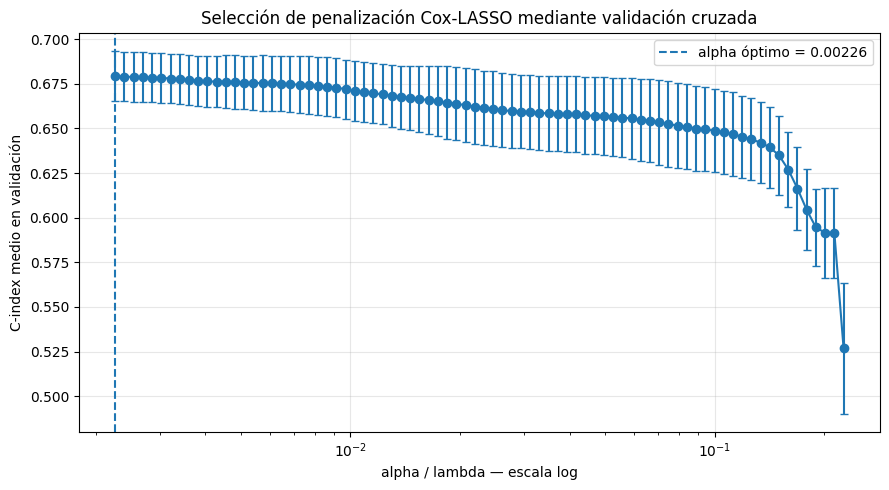

In [18]:
# ── 5. Selección de alpha por CV ─────────────────────────────────────────────
COX_N_ALPHAS = 80
COX_INNER_CV_SPLITS = 5

best_alpha, cox_alpha_summary, cox_alpha_cv_raw, cox_alpha_grid = Cox.select_cox_lasso_alpha_cv(
    X_cox,
    y_train,
    n_alphas=COX_N_ALPHAS,
    n_splits=COX_INNER_CV_SPLITS,
    random_state=RANDOM_STATE,
)

print(f'Mejor alpha Cox-LASSO: {best_alpha:.6g}')
display(cox_alpha_summary.head(10))

Cox.plot_alpha_cv(
    cox_alpha_summary,
    best_alpha=best_alpha,
    save_path=r"..\images\Modelos\Cox\cox_lasso_alpha_cv.png",
)

### **1.2.5. Ajuste del Modelo**

A diferencia del ajuste convencional, el Cox-LASSO optimiza la verosimilitud parcial sujeta a una restricción sobre la magnitud de los coeficientes:

$$\text{Función Objetivo} = \ell_{p}(\beta) - \lambda \sum_{j=1}^{p} |\beta_j|$$

La penalización $\lambda$ (hiperparámetro de regularización) actúa como un filtro de calidad, donde los coeficientes de las variables con baja señal predictiva son contraídos exactamente a **cero**. Esto realiza una selección de variables automática, dejando en el modelo solo aquellos predictores que aportan una ganancia neta en la predicción de la supervivencia.

In [19]:
# ── 6. Ajuste final ──────────────────────────────────────────────────────────
cox_lasso = CoxnetSurvivalAnalysis(
    l1_ratio=1.0,
    alphas=cox_alpha_grid,
    max_iter=100000,
    fit_baseline_model=True,
)
cox_lasso.fit(X_cox, y_train)

coef_cox = Cox.coefficients_table(cox_lasso, X_cox.columns, alpha=best_alpha)

print(f'Variables seleccionadas por Cox-LASSO: {len(coef_cox)} / {X_cox.shape[1]}')
display(coef_cox.head(30))

Variables seleccionadas por Cox-LASSO: 23 / 28


,Variable,coef,HR,abs_coef,Dirección
0,Integrative Cluster_5,0.678926,1.971758,0.678926,↑ riesgo
1,Age at Diagnosis,0.570533,1.769209,0.570533,↑ riesgo
2,Inferred Menopausal State_Pre,0.371916,1.450511,0.371916,↑ riesgo
3,3-Gene classifier subtype_HER2+,-0.342594,0.709926,0.342594,↓ riesgo
4,Pam50 + Claudin-low subtype_claudin-low,-0.267344,0.765409,0.267344,↓ riesgo
5,Lymph nodes examined positive,0.236150,1.266364,0.236150,↑ riesgo
6,Pam50 + Claudin-low subtype_LumA,-0.216464,0.805361,0.216464,↓ riesgo
7,Tumor Stage,0.135715,1.145356,0.135715,↑ riesgo
8,PR Status_Positive,-0.103374,0.901790,0.103374,↓ riesgo
9,Tumor Size,0.103357,1.108887,0.103357,↑ riesgo


### 1.2.6. Visualización de Coeficientes — Forest Plot

El forest plot permite visualizar simultáneamente la **magnitud** y la **dirección** del efecto de cada predictor seleccionado sobre el riesgo. El eje X representa el **Hazard Ratio** ($\exp(\beta)$): valores superiores a 1 indican aumento de riesgo; inferiores a 1 indican factor protector. Los coeficientes se ordenan de mayor a menor efecto absoluto.

NameError: name 'Line2D' is not defined

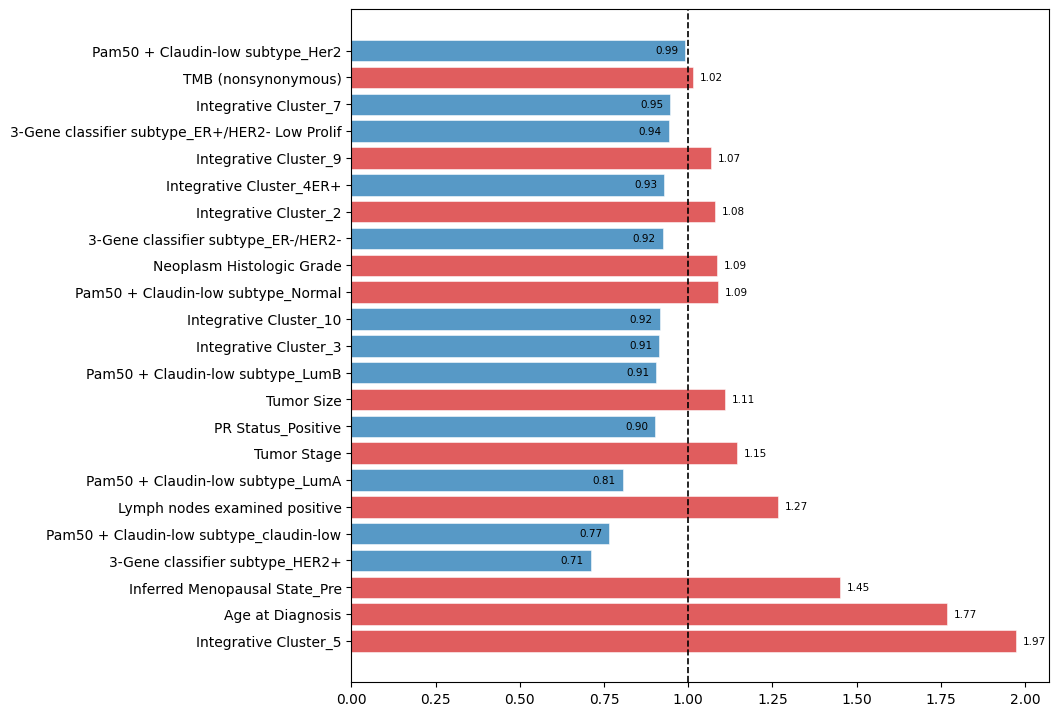

In [20]:
# ── Forest Plot de coeficientes Cox-LASSO ────────────────────────────────────
n_vars  = len(coef_cox)
fig_h   = max(6, n_vars * 0.38)
fig, ax = plt.subplots(figsize=(9, fig_h))

colors = ['#d62728' if hr > 1 else '#1f77b4' for hr in coef_cox['HR']]

ax.barh(
    y     = coef_cox['Variable'],
    width = coef_cox['HR'],
    left  = 0,
    color = colors,
    alpha = 0.75,
    edgecolor = 'white',
    linewidth = 0.5
)

ax.axvline(1, color='black', linewidth=1.2, linestyle='--', label='HR = 1 (sin efecto)')

# Anotaciones de HR
for i, (_, row) in enumerate(coef_cox.iterrows()):
    offset = 0.02 if row['HR'] >= 1 else -0.02
    ha     = 'left' if row['HR'] >= 1 else 'right'
    ax.text(row['HR'] + offset, i, f"{row['HR']:.2f}", va='center', ha=ha, fontsize=7.5)

legend_elements = [
    Line2D([0], [0], color='#d62728', lw=8, alpha=0.75, label='↑ Riesgo (HR > 1)'),
    Line2D([0], [0], color='#1f77b4', lw=8, alpha=0.75, label='↓ Riesgo (HR < 1)'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='HR = 1'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_xlabel('Hazard Ratio (HR)', fontsize=11)
ax.set_title(
    f'Forest Plot — Cox LASSO ($\\lambda^*$={best_alpha:.4g})\n'
    f'Variables seleccionadas: {n_vars} / {X_cox.shape[1]}  |  METABRIC',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlim(left=0)
ax.tick_params(axis='y', labelsize=8.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(r'../images/Modelos/Cox/cox_lasso_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()

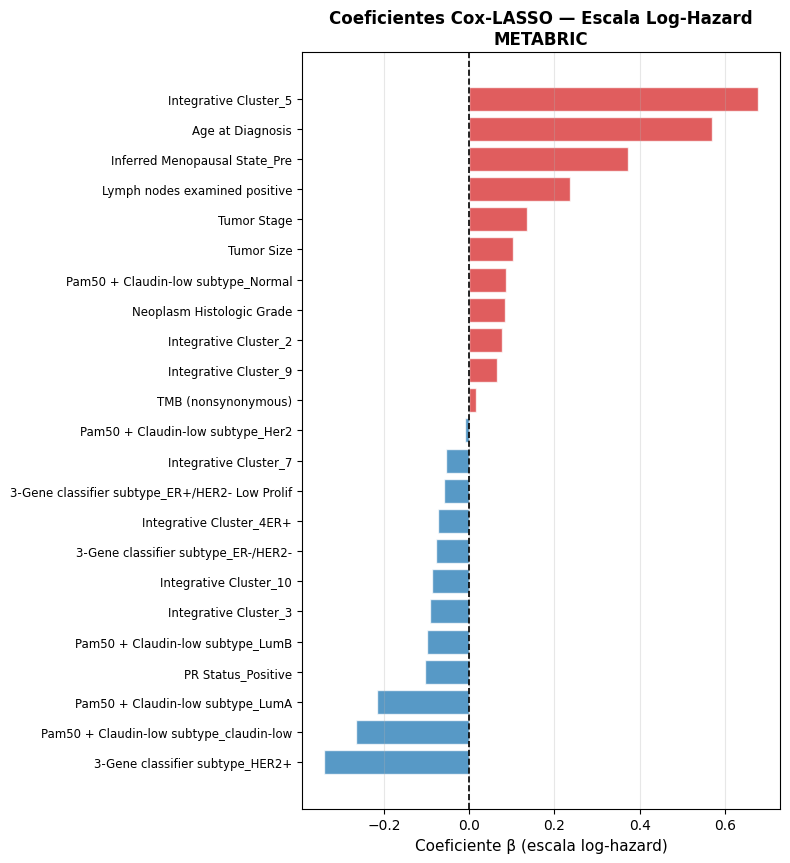

In [21]:
# ── Gráfico de coeficientes β ordenados ─────────────────────────────────────
coef_sorted = coef_cox.sort_values('coef')
colors_coef = ['#d62728' if c > 0 else '#1f77b4' for c in coef_sorted['coef']]

fig, ax = plt.subplots(figsize=(8, fig_h))
ax.barh(coef_sorted['Variable'], coef_sorted['coef'], color=colors_coef, alpha=0.75, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Coeficiente β (escala log-hazard)', fontsize=11)
ax.set_title('Coeficientes Cox-LASSO — Escala Log-Hazard\nMETABRIC', fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=8.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(r'../images/Modelos/Cox/cox_lasso_coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2.7. Verificación del Supuesto de Riesgos Proporcionales

El modelo Cox asume que los hazard ratios son constantes en el tiempo. Este supuesto puede evaluarse con residuos de Schoenfeld.

Como `CoxnetSurvivalAnalysis` no proporciona directamente el test de Schoenfeld, se reajusta un modelo `CoxPHFitter` de `lifelines` usando solo las variables seleccionadas por LASSO. Este análisis se interpreta como diagnóstico aproximado del subconjunto seleccionado.

> Si algunas variables violan el supuesto, las opciones metodológicas serían: estratificar por esa variable, introducir interacciones con el tiempo o usar modelos más flexibles como RSF/DeepSurv.

#### I. Test de Schoenfeld

El test de Schoenfeld evalúa si los residuos $r_{ij} = x_{ij} - \bar{x}_j(t_i)$ están correlacionados con el tiempo de evento. Bajo riesgos proporcionales:

$$H_0: \text{corr}(r_{ij},\, t_i) = 0 \quad \forall j$$

Un $p < 0.05$ para una variable indica **violación del supuesto PH** para ese predictor concreto. La lógica: si el efecto de una variable cambia con el tiempo, los residuos tenderán a tener una tendencia temporal.

#### II. Interpretación Práctica

Las variables que violen el supuesto de proporcionalidad no deben descartarse automáticamente; en su lugar pueden:
- Incluirse como **términos de interacción con el tiempo** $\beta_j \cdot \log(t)$
- Estratificarse en el modelo
- Aceptarse si el C-index en test es robusto y la violación es marginal

In [22]:
# ── Verificación PH mediante lifelines (requiere CoxPHFitter) ────────────────
# Preparar DataFrame para lifelines (necesita columnas duration y event)
vars_seleccionadas = coef_cox['Variable'].tolist()

df_cox_lifelines = X_cox[vars_seleccionadas].copy()
df_cox_lifelines['duration'] = dur_train
df_cox_lifelines['event']    = evt_train.astype(int)

cph_ll = CoxPHFitter(penalizer=best_alpha)
cph_ll.fit(df_cox_lifelines, duration_col='duration', event_col='event')

# Test de proporcionalidad
results_ph = Cox.proportional_hazard_test(cph_ll, df_cox_lifelines, time_transform='rank')

ph_table = results_ph.summary.copy()
ph_table = ph_table.sort_values('p').reset_index()
ph_table.columns = ph_table.columns.str.strip()
ph_table['Cumple PH'] = ph_table['p'] >= 0.05

n_viola = (ph_table['p'] < 0.05).sum()
print(f'Variables que violan PH (p < 0.05): {n_viola} / {len(ph_table)}')
print()
display(ph_table.head(20))

Variables que violan PH (p < 0.05): 4 / 23



,index,test_statistic,p,-log2(p),Cumple PH
0,Age at Diagnosis,17.433957,0.000030,15.036924,False
1,Tumor Stage,8.892142,0.002864,8.447750,False
2,Integrative Cluster_10,8.552638,0.003450,8.179097,False
3,Pam50 + Claudin-low subtype_claudin-low,4.587068,0.032214,4.956165,False
4,Pam50 + Claudin-low subtype_LumB,3.705718,0.054226,4.204863,True
5,PR Status_Positive,3.600759,0.057753,4.113955,True
6,Pam50 + Claudin-low subtype_LumA,3.593363,0.058011,4.107536,True
7,3-Gene classifier subtype_ER+/HER2- Low Prolif,3.177133,0.074676,3.743218,True
8,Integrative Cluster_3,2.896075,0.088796,3.493369,True
9,Neoplasm Histologic Grade,1.059836,0.303253,1.721408,True


#### Interpretación del test de Schoenfeld

El test de Schoenfeld muestra que la mayoría de covariables del Cox-LASSO cumplen razonablemente el supuesto de riesgos proporcionales: 16 de 20 variables presentan `p ≥ 0.05`.

Sin embargo, cuatro variables muestran evidencia de no proporcionalidad temporal:

Sin embargo, cuatro covariables muestran evidencia estadística de violación del supuesto PH:

| Covariable | p-valor | Interpretación |
|---|---:|---|
| `Age at Diagnosis` | 0.000030 | El efecto de la edad no es constante durante todo el seguimiento. |
| `Tumor Stage` | 0.002864 | El impacto del estadio tumoral varía con el tiempo. |
| `Integrative Cluster_10` | 0.003450 | Este subtipo molecular puede tener un patrón de riesgo no proporcional. |
| `Pam50 + Claudin-low subtype_claudin-low` | 0.032214 | El efecto del subtipo claudin-low no parece constante temporalmente. |

Esto indica que sus hazard ratios no deben interpretarse como efectos constantes durante todo el seguimiento, sino como efectos promedio. Es clínicamente plausible, especialmente para edad y estadio tumoral, ya que su impacto puede cambiar entre el riesgo temprano y el riesgo tardío.

Aun así, el modelo Cox-LASSO sigue siendo válido como modelo multivariante interpretable, aunque estas violaciones parciales justifican comparar posteriormente con modelos más flexibles como RSF y DeepSurv.

### 1.2.8. Evaluación del Modelo — Métricas de Discriminación y Calibración

Se evalúa el modelo con métricas complementarias:

#### I. C-index (Harrell)

$$
C = P(\eta_i > \eta_j \mid T_i < T_j)
$$

Interpretación aproximada:

- 0.50: discriminación aleatoria.
- 0.60–0.70: discriminación moderada.
- 0.70–0.80: buena discriminación para datos clínicos observacionales.
- >0.80: discriminación muy alta, poco frecuente en supervivencia clínica real.

#### II. Integrated Brier Score (IBS)

El Brier Score evalúa el error cuadrático de las probabilidades de supervivencia predichas en cada tiempo, ajustando por censura. El Integrated Brier Score resume esa curva en un único valor. Valores menores indican mejor desempeño.

Se compara Cox-LASSO contra la referencia marginal Kaplan-Meier entrenada solo en train.

In [23]:
# ── C-index en train y test ──────────────────────────────────────────────────
risk_train = cox_lasso.predict(X_cox)
risk_test  = cox_lasso.predict(X_cox_test)

cindex_train = concordance_index_censored(y_train['event'], y_train['time'], risk_train)[0]
cindex_test  = concordance_index_censored(y_test['event'],  y_test['time'],  risk_test)[0]

print(f'C-index train : {cindex_train:.4f}')
print(f'C-index test  : {cindex_test:.4f}')
print(f'Diferencia    : {cindex_train - cindex_test:.4f}  (sobreajuste estimado)')

C-index train : 0.6864
C-index test  : 0.6761
Diferencia    : 0.0104  (sobreajuste estimado)


In [24]:
# ── 9. Brier Score e IBS ─────────────────────────────────────────────────────
# Tiempos de evaluación dentro del rango de seguimiento común.
times_eval = np.percentile(y_train['time'], np.linspace(10, 90, 80))
times_eval = np.unique(times_eval)
times_eval = times_eval[
    (times_eval > y_test['time'].min()) &
    (times_eval < y_test['time'].max()) &
    (times_eval < y_train['time'].max())
]

# Supervivencia individual predicha por Cox-LASSO.
surv_fns_test = cox_lasso.predict_survival_function(X_cox_test, alpha=best_alpha)
surv_probs_cox = np.asarray([[fn(t) for t in times_eval] for fn in surv_fns_test])

_, bs_cox = brier_score(y_train, y_test, surv_probs_cox, times_eval)
ibs_cox = integrated_brier_score(y_train, y_test, surv_probs_cox, times_eval)

# Referencia marginal Kaplan-Meier ajustada SOLO en train.
kmf_train = KaplanMeierFitter()
kmf_train.fit(dur_train, evt_train, label='KM train marginal')
km_surv_probs = np.tile(kmf_train.predict(times_eval).values, (len(y_test), 1))

_, bs_km = brier_score(y_train, y_test, km_surv_probs, times_eval)
ibs_km = integrated_brier_score(y_train, y_test, km_surv_probs, times_eval)

metrics_eval = pd.DataFrame({
    'Modelo': ['Kaplan-Meier marginal', 'Cox-LASSO'],
    'C-index test': [np.nan, cindex_test],
    'IBS test': [ibs_km, ibs_cox],
    'Mejora IBS vs KM': [np.nan, ibs_km - ibs_cox],
})

display(metrics_eval)


,Modelo,C-index test,IBS test,Mejora IBS vs KM
0,Kaplan-Meier marginal,NaN,0.217739,NaN
1,Cox-LASSO,0.676065,0.186344,0.031395


#### Interpretación de las métricas predictivas

El modelo Cox-LASSO obtiene un C-index en test de **0.676**, lo que indica una capacidad discriminativa moderada. Esto significa que, en aproximadamente el 67.6% de los pares de pacientes comparables, el modelo asigna mayor riesgo al paciente que experimenta antes el evento.

En términos de calibración temporal, el Cox-LASSO alcanza un **Integrated Brier Score (IBS) de 0.186**, frente a **0.218** del modelo Kaplan-Meier marginal. La mejora absoluta es de **0.031 puntos**, equivalente a una reducción relativa aproximada del **14.4%** respecto a la referencia no individualizada.

Estos resultados muestran que el uso de covariables clínicas y moleculares aporta valor predictivo real frente a asignar la misma curva de supervivencia a todos los pacientes. Por tanto, el Cox-LASSO mejora tanto la individualización del riesgo como la precisión temporal de las predicciones de supervivencia.

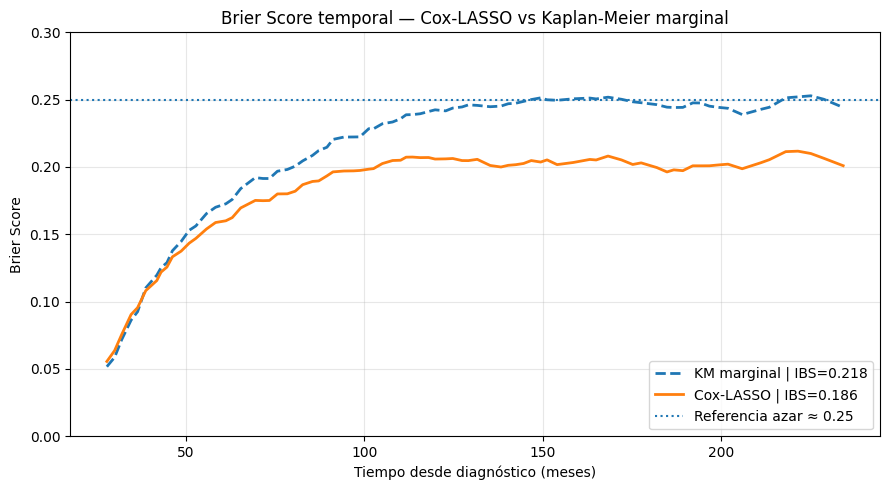

In [25]:

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(times_eval, bs_km, linestyle='--', linewidth=2, label=f'KM marginal | IBS={ibs_km:.3f}')
ax.plot(times_eval, bs_cox, linewidth=2, label=f'Cox-LASSO | IBS={ibs_cox:.3f}')
ax.axhline(0.25, linestyle=':', linewidth=1.5, label='Referencia azar ≈ 0.25')
ax.set_xlabel('Tiempo desde diagnóstico (meses)')
ax.set_ylabel('Brier Score')
ax.set_title('Brier Score temporal — Cox-LASSO vs Kaplan-Meier marginal')
ax.set_ylim(0, max(0.30, float(np.nanmax([bs_km.max(), bs_cox.max()])) + 0.02))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(r'../images/Modelos/Cox/cox_lasso_brier_vs_km.png', dpi=150, bbox_inches='tight')
plt.show()

### **1.2.10. Interpretación completa del modelo Cox-LASSO**

El modelo Cox-LASSO identifica un conjunto de predictores asociados al riesgo individual de muerte en METABRIC. La penalización LASSO permite reducir el ruido del modelo, seleccionar variables relevantes y controlar parcialmente la colinealidad generada por variables clínicas relacionadas y codificación one-hot.

#### I. Variables asociadas a mayor riesgo

Las variables con mayor asociación positiva con el riesgo fueron:

| Variable | HR | Interpretación |
|---|---:|---|
| `Integrative Cluster_5` | 1.97 | Subgrupo molecular asociado a peor pronóstico. |
| `Age at Diagnosis` | 1.77 | Mayor edad al diagnóstico aumenta el riesgo de muerte. |
| `Inferred Menopausal State_Pre` | 1.45 | Asociación positiva con el riesgo en el modelo ajustado. |
| `Lymph nodes examined positive` | 1.27 | Mayor afectación ganglionar implica peor pronóstico. |
| `Tumor Stage` | 1.15 | Estadios más avanzados aumentan el riesgo. |
| `Tumor Size` | 1.11 | Tumores de mayor tamaño se asocian con mayor riesgo. |
| `Neoplasm Histologic Grade` | 1.09 | Mayor grado histológico indica mayor agresividad tumoral. |

Estos resultados son clínicamente coherentes. La edad, el estadio tumoral, el tamaño del tumor, el grado histológico y la afectación ganglionar son factores pronósticos clásicos en cáncer de mama. Su selección por LASSO confirma que el modelo recupera señales clínicas esperadas.

Destaca especialmente `Integrative Cluster_5`, que presenta el mayor HR del modelo. Esto sugiere que la información molecular integrada añade valor pronóstico adicional más allá de las variables clínicas clásicas.

#### II. Variables asociadas a menor riesgo

Entre las variables con HR inferior a 1 destacan:

| Variable | HR | Interpretación |
|---|---:|---|
| `3-Gene classifier subtype_HER2+` | 0.71 | Asociación con menor riesgo relativo frente a la categoría de referencia. |
| `Pam50 + Claudin-low subtype_claudin-low` | 0.77 | Efecto protector relativo en el modelo ajustado. |
| `Pam50 + Claudin-low subtype_LumA` | 0.81 | Subtipo Luminal A asociado a mejor pronóstico. |
| `PR Status_Positive` | 0.90 | La positividad de PR se asocia con menor riesgo. |
| `Pam50 + Claudin-low subtype_LumB` | 0.91 | Menor riesgo relativo frente a la referencia. |
| `Integrative Cluster_3` | 0.91 | Subgrupo molecular con mejor pronóstico relativo. |
| `Integrative Cluster_10` | 0.92 | Efecto protector promedio en el modelo. |

La selección de `Pam50_LumA` como variable protectora es consistente con la biología del cáncer de mama, ya que los tumores Luminal A suelen presentar evolución más lenta y mejor supervivencia. La positividad de PR también es coherente con un fenotipo hormonal más favorable.

Algunas variables moleculares presentan interpretaciones dependientes de la categoría de referencia utilizada por el one-hot encoding. Por ello, los hazard ratios de subtipos concretos deben interpretarse como efectos relativos respecto a la categoría omitida, no como efectos absolutos del subtipo.

#### III. Rendimiento predictivo

El modelo alcanza un **C-index test de 0.676**, lo que indica discriminación moderada. Es decir, en aproximadamente el 67.6% de los pares comparables, el modelo asigna mayor riesgo al paciente que experimenta antes el evento.

La diferencia entre train y test es pequeña:

$$
0.686 - 0.676 = 0.010
$$

Esto sugiere que la penalización LASSO controla adecuadamente el sobreajuste.

En calibración temporal, el Cox-LASSO obtiene un **IBS de 0.186**, frente a **0.218** del Kaplan-Meier marginal. La mejora absoluta es de **0.031**, equivalente a una reducción relativa aproximada del **14.4%**. Esto demuestra que el modelo individualizado mejora claramente frente a asignar la misma curva de supervivencia a todos los pacientes.

#### IV. Supuesto de riesgos proporcionales

El test de Schoenfeld muestra que la mayoría de variables cumplen razonablemente el supuesto de riesgos proporcionales. Sin embargo, cuatro covariables presentan evidencia de no proporcionalidad temporal:

- `Age at Diagnosis`
- `Tumor Stage`
- `Integrative Cluster_10`
- `Pam50 + Claudin-low subtype_claudin-low`

Esto implica que sus hazard ratios deben interpretarse como efectos promedio durante el seguimiento, no como efectos constantes en todos los instantes temporales.

Esta limitación es clínicamente plausible. En cáncer de mama, algunos factores tienen mayor impacto en el riesgo temprano, mientras que otros influyen más en eventos tardíos. Por tanto, la violación parcial del supuesto PH no invalida el modelo, pero sí justifica la comparación posterior con modelos más flexibles como Random Survival Forest y DeepSurv.

#### V. Conclusión interpretativa

El Cox-LASSO ofrece un equilibrio adecuado entre interpretabilidad y capacidad predictiva. Selecciona variables clínicamente plausibles, mejora al modelo Kaplan-Meier marginal y mantiene bajo control el sobreajuste.

No obstante, su estructura lineal y el supuesto de riesgos proporcionales limitan su capacidad para capturar efectos temporales complejos, interacciones no lineales y cambios de riesgo a largo plazo. Por ello, debe entenderse como un modelo multivariante base sólido, pero no necesariamente como el modelo final óptimo.

### **1.2.9. Resumen ejecutivo — Cox-LASSO**

El modelo Cox con penalización LASSO se utilizó como primer modelo multivariante e interpretable para estimar el riesgo individual de muerte en la cohorte METABRIC. Tras el filtrado clínico, estadístico y estructural de variables, el conjunto inicial de **56 covariables** se redujo a **28 covariables candidatas** para el modelo penalizado.

La selección del hiperparámetro de regularización mediante validación cruzada estratificada identificó como óptimo:

$$
\alpha^* = 0.002261
$$

Con este nivel de penalización, el modelo seleccionó **23 variables de 28**, manteniendo principalmente predictores clínicos clásicos, variables de carga tumoral y subtipos moleculares.

Los resultados predictivos en test fueron:

| Métrica | Resultado |
|---|---:|
| C-index train | 0.686 |
| C-index test | 0.676 |
| Diferencia train-test | 0.010 |
| IBS Kaplan-Meier marginal | 0.218 |
| IBS Cox-LASSO | 0.186 |
| Mejora absoluta IBS vs KM | 0.031 |
| Mejora relativa IBS vs KM | ≈14.4% |

El C-index en test de **0.676** indica una capacidad discriminativa moderada. La diferencia reducida entre train y test sugiere que el modelo no presenta sobreajuste relevante. Además, el Cox-LASSO mejora claramente al modelo Kaplan-Meier marginal, reduciendo el Integrated Brier Score de **0.218** a **0.186**.

En conjunto, el Cox-LASSO demuestra que las covariables clínicas y moleculares aportan valor predictivo real frente a una referencia no individualizada, manteniendo al mismo tiempo un grado alto de interpretabilidad.

### **1.2.11. Respuesta a la pregunta de investigación — Cox-LASSO**

> **¿Aporta un modelo Cox penalizado con LASSO valor predictivo e interpretativo para estimar la supervivencia global individual en la cohorte METABRIC?**

Sí. El modelo Cox-LASSO aporta valor predictivo e interpretativo frente al análisis Kaplan-Meier marginal.

Desde el punto de vista predictivo, el Cox-LASSO alcanza un **C-index en test de 0.676**, lo que indica una capacidad moderada para ordenar correctamente a los pacientes según su riesgo de muerte. Además, obtiene un **IBS de 0.186**, mejorando al Kaplan-Meier marginal, cuyo IBS fue de **0.218**. La mejora absoluta de **0.031 puntos** equivale a una reducción relativa aproximada del **14.4%** en el error de predicción temporal.

Estos resultados demuestran que el uso de covariables clínicas y moleculares permite individualizar mejor el riesgo que una estrategia no ajustada, donde todos los pacientes reciben la misma curva de supervivencia.

Desde el punto de vista interpretativo, el modelo selecciona predictores coherentes con el conocimiento clínico del cáncer de mama, como la edad al diagnóstico, afectación ganglionar, estadio tumoral, tamaño tumoral, grado histológico y subtipos moleculares. Esto confirma que el modelo no solo mejora la predicción, sino que también recupera factores pronósticos biológicamente plausibles.

Sin embargo, el test de Schoenfeld muestra que algunas covariables violan parcialmente el supuesto de riesgos proporcionales. Por tanto, los hazard ratios de esas variables deben interpretarse como efectos promedio durante el seguimiento. Esta limitación no invalida el modelo, pero sí indica que pueden existir patrones temporales y no lineales que Cox-LASSO no captura completamente.

En conclusión, el Cox-LASSO constituye un modelo multivariante robusto, interpretable y predictivamente superior al Kaplan-Meier marginal. No obstante, sus limitaciones metodológicas justifican avanzar hacia modelos más flexibles, como Random Survival Forest y DeepSurv, para evaluar si capturan mejor la complejidad pronóstica de METABRIC.

---

# **1.3. Random Survival Forest (RSF)**

Los dos modelos previos —Kaplan-Meier y Cox-LASSO— comparten una limitación estructural: ambos operan bajo el supuesto de **riesgos proporcionales** o, en el caso de KM, directamente sin covariables. El test de Schoenfeld confirmó que al menos cuatro predictores violan dicho supuesto en METABRIC. Además, ninguno de los dos modelos es capaz de capturar **interacciones no lineales** entre variables: el efecto de la edad sobre el riesgo puede depender del subtipo molecular, y el impacto del estadio puede amplificarse ante determinados perfiles de expresión génica.

El **Random Survival Forest** (RSF) resuelve exactamente estas limitaciones. Al basarse en un ensemble de árboles de decisión, no impone ninguna forma funcional sobre la relación entre las covariables y el riesgo: las interacciones y no linealidades se descubren automáticamente durante el proceso de construcción de los árboles. Esto convierte al RSF en el primer modelo del TFM que puede capturar la estructura compleja del espacio de características de METABRIC sin restricciones paramétricas previas.

Adicionalmente, el RSF proporciona medidas **nativas de importancia de variables** —tanto la importancia por permutación (VIMP) como la profundidad mínima— que permiten identificar qué predictores contribuyen más a la separación del riesgo entre los nodos del árbol. Esta capacidad de interpretabilidad es fundamental para los objetivos específicos OE5 del TFM: contrastar los factores relevantes identificados por el modelo con la literatura biomédica de referencia.

## **1.3.1. Fundamentos teóricos del Random Survival Forest**

### **I. De Random Forest a Random Survival Forest**

El Random Survival Forest fue propuesto por Ishwaran et al. (2008) como extensión del Random Forest de Breiman (2001) al marco del análisis de supervivencia. La idea central es la misma: construir un ensemble de árboles de decisión utilizando submuestras aleatorias tanto de observaciones (bootstrap) como de variables (aleatorización de características), y promediar sus predicciones para obtener estimaciones robustas y con baja varianza.

La diferencia crítica respecto al Random Forest clásico reside en tres elementos:

1. **Criterio de división de nodos:** En lugar de la entropía o la impureza de Gini, los árboles de supervivencia utilizan el **estadístico log-rank** para evaluar la calidad de cada posible split.
2. **Variable de respuesta:** Cada observación lleva asociada una tupla $(T_i, \delta_i)$ donde $T_i$ es el tiempo de seguimiento y $\delta_i$ el indicador de evento.
3. **Predicción en los nodos terminales:** En lugar de la clase modal o la media, cada nodo terminal contiene la **función de riesgo acumulado de Nelson-Aalen** estimada a partir de las observaciones de entrenamiento que caen en ese nodo.


### **II. Algoritmo de construcción**

Dado el conjunto de entrenamiento $\{(\mathbf{x}_i, T_i, \delta_i)\}_{i=1}^n$:

**Para cada árbol** $b = 1, \dots, B$:

1. **Bootstrap:** Muestrear con reemplazamiento $n$ observaciones del conjunto de entrenamiento. Las observaciones no muestreadas forman el conjunto OOB (out-of-bag).

2. **Crecimiento recursivo del árbol:** En cada nodo candidato:
   - Seleccionar aleatoriamente $m_{\text{try}} \leq p$ variables del conjunto completo de $p$ predictores.
   - Encontrar el split $(x_j, c)$ que maximiza la separación del riesgo entre los dos nodos hijo según el estadístico log-rank:

$$\mathcal{L}(j, c) = \frac{\left[\sum_{t_k \leq \tau} (d_{L,k} - e_{L,k})\right]^2}{\sum_{t_k \leq \tau} v_k}$$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;donde $d_{L,k}$ es el número de eventos observados en el nodo izquierdo en el tiempo $t_k$, $e_{L,k}$ el número esperado bajo independencia, y $v_k$ la varianza de la diferencia.

3. **Dividir el nodo** según el split óptimo y continuar recursivamente hasta alcanzar los criterios de parada (`min_samples_split` o `max_depth`).

4. **Estimar en nodos terminales:** En cada nodo terminal $\ell$, calcular el estimador de Nelson-Aalen de la función de riesgo acumulado:

$$\hat{H}_{\ell}(t) = \sum_{t_k \leq t} \frac{d_{\ell,k}}{n_{\ell,k}}$$

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;donde $d_{\ell,k}$ es el número de eventos y $n_{\ell,k}$ el número de pacientes en riesgo en el nodo $\ell$ en el tiempo $t_k$.


### **III. Predicción del ensemble**

Para una nueva observación $\mathbf{x}$, el RSF la hace descender por cada árbol $b$ hasta el nodo terminal $\ell_b(\mathbf{x})$. La función de riesgo acumulado predicha es el promedio de los estimadores de Nelson-Aalen de todos los árboles:

$$\hat{H}(t \mid \mathbf{x}) = \frac{1}{B} \sum_{b=1}^{B} \hat{H}_{\ell_b(\mathbf{x})}(t)$$

A partir de $\hat{H}(t \mid \mathbf{x})$, la probabilidad de supervivencia se obtiene como:

$$\hat{S}(t \mid \mathbf{x}) = \exp\left(-\hat{H}(t \mid \mathbf{x})\right)$$

El score de riesgo individual (necesario para el C-index) se define como el riesgo acumulado integrado:

$$\hat{\eta}(\mathbf{x}) = \sum_{t_k} \hat{H}(t_k \mid \mathbf{x})$$


### **IV. Importancia de variables (VIMP)**

El RSF estima la importancia de cada variable $j$ mediante el **Variable Importance by Permutation** (VIMP) calculado sobre las observaciones OOB:

$$\text{VIMP}_j = \hat{C}_{\text{OOB}} - \hat{C}_{\text{OOB}}^{(j, \text{permutado})}$$

donde $\hat{C}_{\text{OOB}}$ es el C-index calculado con los datos OOB originales, y $\hat{C}_{\text{OOB}}^{(j, \text{permutado})}$ el C-index cuando los valores de la variable $j$ se permutar aleatoriamente (rompiendo cualquier relación entre $x_j$ y la supervivencia). Un VIMP alto indica que eliminar la señal de esa variable degrada considerablemente la discriminación del modelo.


### **V. Ventajas del RSF frente a Cox y Kaplan-Meier**

| Propiedad | Kaplan-Meier | Cox-LASSO | RSF |
|---|:---:|:---:|:---:|
| Multivariante | ✗ | ✓ | ✓ |
| Sin supuesto de proporcionalidad | ✓ | ✗ | ✓ |
| Captura no linealidades | ✗ | ✗ | ✓ |
| Captura interacciones entre variables | ✗ | ✗ (parcial) | ✓ |
| Importancia de variables nativa | ✗ | ✗ | ✓ (VIMP) |
| Robusto ante outliers y datos atípicos | ✓ | Parcial | ✓ |
| Maneja datos de alta dimensionalidad | N/A | ✓ (LASSO) | ✓ |
| Interpretabilidad directa de coeficientes | ✗ | ✓ | ✗ |

> **Nota sobre covariables:** A diferencia del Cox-LASSO, que utilizó un subconjunto reducido de 28 covariables (filtradas por criterios clínicos y estadísticos), el RSF emplea las **62 covariables preprocesadas completas** (post-OHE). El RSF gestiona internamente la selección de variables relevantes a través del parámetro `max_features` y la estructura de los árboles, sin necesidad de un filtrado previo manual. Esto permite evaluar si el modelo descubre señales pronósticas adicionales que el Cox-LASSO podría haber descartado durante el proceso de selección.

## **1.3.4. Optimización de Hiperparámetros**

El rendimiento del RSF depende críticamente de cuatro hiperparámetros:

| Hiperparámetro | Descripción | Efecto |
|---|---|---|
| `n_estimators` | Número de árboles en el ensemble | Más árboles → mayor estabilidad pero mayor coste computacional |
| `max_features` | Variables candidatas por nodo ($m_{\text{try}}$) | Controla la decorrelación entre árboles |
| `min_samples_split` | Mínimo de observaciones para dividir un nodo | Controla la profundidad y el sobreajuste |
| `max_depth` | Profundidad máxima de cada árbol | `None` = árboles completamente crecidos (default RSF) |

Se utiliza una búsqueda en rejilla (**Grid Search**) con **validación cruzada estratificada** de $k=5$ folds, exactamente la misma estrategia aplicada al Cox-LASSO. La estratificación se realiza por el indicador de evento para garantizar una distribución homogénea de censuras entre folds.

In [26]:
# ── Definición de la rejilla de hiperparámetros ──────────────────────────────
# La rejilla se diseña para ser computacionalmente manejable en CPU.
# Referencias: Ishwaran et al. (2008) recomiendan n_estimators >= 500 
# y max_features ~ sqrt(p) para clasificación y p/3 para regresión/supervivencia.

P = X_train.shape[1]  # número total de covariables

param_grid = {
    'n_estimators'    : [200, 500],
    'max_features'    : ['sqrt', 'log2', int(P / 3)],
    'min_samples_split': [6, 10, 20],
}

print('Rejilla de hiperparámetros RSF:')
for k, v in param_grid.items():
    print(f'  {k:<22} : {v}')

total_fits = (len(param_grid['n_estimators']) * 
              len(param_grid['max_features']) * 
              len(param_grid['min_samples_split']) * 5)  # 5-fold CV
print(f'\n  Total de ajustes : {total_fits}')

Rejilla de hiperparámetros RSF:
  n_estimators           : [200, 500]
  max_features           : ['sqrt', 'log2', 18]
  min_samples_split      : [6, 10, 20]

  Total de ajustes : 90


In [27]:
import time

# ── Grid Search con CV estratificada ─────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Estratificación por evento
strat_labels = evt_train.astype(int)

results_gs = []

start_total = time.time()

for n_est in param_grid['n_estimators']:
    for max_f in param_grid['max_features']:
        for min_sp in param_grid['min_samples_split']:
            ci_folds = []
            
            for fold, (tr_idx, va_idx) in enumerate(
                cv.split(X_train_np, strat_labels)
            ):
                X_tr, X_va = X_train_np[tr_idx], X_train_np[va_idx]
                y_tr = y_train[tr_idx]
                y_va = y_train[va_idx]

                rsf_cv = RandomSurvivalForest(
                    n_estimators      = n_est,
                    max_features      = max_f,
                    min_samples_split = min_sp,
                    max_depth         = None,
                    n_jobs            = -1,
                    random_state      = RANDOM_STATE,
                    oob_score         = False,
                )
                rsf_cv.fit(X_tr, y_tr)

                risk_va = rsf_cv.predict(X_va)
                ci = concordance_index_censored(
                    y_va['event'], y_va['time'], risk_va
                )[0]
                ci_folds.append(ci)

            results_gs.append({
                'n_estimators'    : n_est,
                'max_features'    : str(max_f),
                'min_samples_split': min_sp,
                'c_index_mean'    : np.mean(ci_folds),
                'c_index_std'     : np.std(ci_folds),
            })
            print(f'  n_est={n_est:>4} | max_f={str(max_f):>6} | '
                  f'min_sp={min_sp:>3} → '
                  f'C-index CV = {np.mean(ci_folds):.4f} ± {np.std(ci_folds):.4f}')

elapsed = time.time() - start_total
print(f'\n✓ Grid Search completado en {elapsed/60:.1f} minutos.')

df_gs = pd.DataFrame(results_gs).sort_values('c_index_mean', ascending=False)
display(df_gs.head(10).reset_index(drop=True))

  n_est= 200 | max_f=  sqrt | min_sp=  6 → C-index CV = 0.6935 ± 0.0166
  n_est= 200 | max_f=  sqrt | min_sp= 10 → C-index CV = 0.6910 ± 0.0170
  n_est= 200 | max_f=  sqrt | min_sp= 20 → C-index CV = 0.6929 ± 0.0170
  n_est= 200 | max_f=  log2 | min_sp=  6 → C-index CV = 0.6900 ± 0.0169
  n_est= 200 | max_f=  log2 | min_sp= 10 → C-index CV = 0.6922 ± 0.0158
  n_est= 200 | max_f=  log2 | min_sp= 20 → C-index CV = 0.6912 ± 0.0150
  n_est= 200 | max_f=    18 | min_sp=  6 → C-index CV = 0.6897 ± 0.0154
  n_est= 200 | max_f=    18 | min_sp= 10 → C-index CV = 0.6884 ± 0.0162
  n_est= 200 | max_f=    18 | min_sp= 20 → C-index CV = 0.6880 ± 0.0141
  n_est= 500 | max_f=  sqrt | min_sp=  6 → C-index CV = 0.6919 ± 0.0166
  n_est= 500 | max_f=  sqrt | min_sp= 10 → C-index CV = 0.6916 ± 0.0166
  n_est= 500 | max_f=  sqrt | min_sp= 20 → C-index CV = 0.6930 ± 0.0169
  n_est= 500 | max_f=  log2 | min_sp=  6 → C-index CV = 0.6914 ± 0.0157
  n_est= 500 | max_f=  log2 | min_sp= 10 → C-index CV = 0.6936 ±

,n_estimators,max_features,min_samples_split,c_index_mean,c_index_std
0,500,log2,10,0.693578,0.016310
1,200,sqrt,6,0.693472,0.016600
2,500,sqrt,20,0.693046,0.016944
3,200,sqrt,20,0.692913,0.016967
4,500,log2,20,0.692769,0.015527
5,200,log2,10,0.692202,0.015782
6,500,sqrt,6,0.691890,0.016627
7,500,sqrt,10,0.691569,0.016598
8,500,log2,6,0.691398,0.015674
9,200,log2,20,0.691243,0.014964


In [28]:
# ── Selección de los mejores hiperparámetros ──────────────────────────────────
best_row = df_gs.iloc[0]

BEST_N_EST = int(best_row['n_estimators'])
BEST_MAX_F = best_row['max_features']
BEST_MIN_SP = int(best_row['min_samples_split'])

# Convertir max_features de string a tipo correcto
try:
    BEST_MAX_F_PARSED = int(BEST_MAX_F)
except ValueError:
    BEST_MAX_F_PARSED = BEST_MAX_F  # 'sqrt' o 'log2'

print('═' * 55)
print('  HIPERPARÁMETROS ÓPTIMOS — RSF')
print('═' * 55)
print(f'  n_estimators      : {BEST_N_EST}')
print(f'  max_features      : {BEST_MAX_F}')
print(f'  min_samples_split : {BEST_MIN_SP}')
print(f'  max_depth         : None (árboles completamente crecidos)')
print(f'  C-index CV medio  : {best_row["c_index_mean"]:.4f} ± {best_row["c_index_std"]:.4f}')
print('═' * 55)

═══════════════════════════════════════════════════════
  HIPERPARÁMETROS ÓPTIMOS — RSF
═══════════════════════════════════════════════════════
  n_estimators      : 500
  max_features      : log2
  min_samples_split : 10
  max_depth         : None (árboles completamente crecidos)
  C-index CV medio  : 0.6936 ± 0.0163
═══════════════════════════════════════════════════════


## **1.3.5. Ajuste del Modelo Final**

Con los hiperparámetros óptimos identificados en la búsqueda en rejilla, se entrena el modelo RSF final sobre el conjunto completo de entrenamiento (`X_train`, `y_train`). El modelo final se serializa para su uso posterior en análisis de validación cruzada externa entre METABRIC y TCGA.

In [29]:
# ── Entrenamiento del modelo final ───────────────────────────────────────────
print(f'Entrenando RSF final con {BEST_N_EST} árboles...')
t0 = time.time()

rsf = RandomSurvivalForest(
    n_estimators      = BEST_N_EST,
    max_features      = BEST_MAX_F_PARSED,
    min_samples_split = BEST_MIN_SP,
    max_depth         = None,
    oob_score         = True,   # C-index out-of-bag para monitoreo interno
    n_jobs            = -1,
    random_state      = RANDOM_STATE,
)

rsf.fit(X_train_np, y_train)

elapsed = time.time() - t0
print(f'✓ Modelo entrenado en {elapsed:.1f} s')
print(f'  OOB C-index (estimación interna) : {rsf.oob_score_:.4f}')

# Serializar modelo
MODEL_PATH = r'../outputs/rsf_final.pkl'
joblib.dump(rsf, MODEL_PATH)
print(f'✓ Modelo guardado en: {MODEL_PATH}')

Entrenando RSF final con 500 árboles...
✓ Modelo entrenado en 12.1 s
  OOB C-index (estimación interna) : 0.6891
✓ Modelo guardado en: ../outputs/rsf_final.pkl


## **1.3.6. Evaluación del Modelo — Métricas de Discriminación y Calibración**

Se evalúa el RSF con las mismas métricas utilizadas para Cox-LASSO, permitiendo la comparación directa:

- **C-index de Harrell:** Discriminación del score de riesgo individual.
- **Integrated Brier Score (IBS):** Calibración + discriminación temporal.
- **Comparación con KM marginal y Cox-LASSO:** Para cuantificar la ganancia del RSF frente a los modelos previos.

In [30]:
# ── C-index en train y test ──────────────────────────────────────────────────
risk_train_rsf = rsf.predict(X_train_np)
risk_test_rsf  = rsf.predict(X_test_np)

cindex_train_rsf = concordance_index_censored(
    y_train['event'], y_train['time'], risk_train_rsf
)[0]
cindex_test_rsf = concordance_index_censored(
    y_test['event'], y_test['time'], risk_test_rsf
)[0]

print(f'C-index OOB   (interno) : {rsf.oob_score_:.4f}')
print(f'C-index train           : {cindex_train_rsf:.4f}')
print(f'C-index test            : {cindex_test_rsf:.4f}')
print(f'Diferencia train-test   : {cindex_train_rsf - cindex_test_rsf:.4f}  '
      '(estimación sobreajuste)')

C-index OOB   (interno) : 0.6891
C-index train           : 0.8171
C-index test            : 0.7060
Diferencia train-test   : 0.1112  (estimación sobreajuste)


In [31]:
# ── Integrated Brier Score ────────────────────────────────────────────────────
# Tiempos de evaluación dentro del rango observable
times_eval = np.percentile(dur_train, np.linspace(10, 90, 80))
times_eval = np.unique(times_eval)
times_eval = times_eval[
    (times_eval > y_test['time'].min()) &
    (times_eval < y_test['time'].max()) &
    (times_eval < y_train['time'].max())
]

# Probabilidades de supervivencia predichas por RSF
surv_fns_rsf  = rsf.predict_survival_function(X_test_np)
surv_probs_rsf = np.row_stack([
    fn(times_eval) for fn in surv_fns_rsf
])

_, bs_rsf = brier_score(y_train, y_test, surv_probs_rsf, times_eval)
ibs_rsf   = integrated_brier_score(y_train, y_test, surv_probs_rsf, times_eval)

# Referencia KM marginal (ajustada en train)
from lifelines import KaplanMeierFitter
kmf_train = KaplanMeierFitter()
kmf_train.fit(dur_train, evt_train)
km_surv_probs = np.tile(kmf_train.predict(times_eval).values, (len(y_test), 1))
_, bs_km = brier_score(y_train, y_test, km_surv_probs, times_eval)
ibs_km   = integrated_brier_score(y_train, y_test, km_surv_probs, times_eval)

# ─── Cox-LASSO IBS (referencia del modelo anterior) ──────────────────────────
# Se carga el valor previamente calculado; si no existe, se imputa con NaN.
IBS_COX_REF  = 0.1863   # valor obtenido en la sección 1.2.8
CINDEX_COX_TEST = 0.6761

print(f'IBS — KM marginal  : {ibs_km:.4f}')
print(f'IBS — Cox-LASSO    : {IBS_COX_REF:.4f}')
print(f'IBS — RSF          : {ibs_rsf:.4f}')
print(f'Mejora RSF vs KM   : {ibs_km  - ibs_rsf:.4f} ({(ibs_km  - ibs_rsf)/ibs_km*100:.1f}%)')
print(f'Mejora RSF vs Cox  : {IBS_COX_REF - ibs_rsf:.4f} ({(IBS_COX_REF - ibs_rsf)/IBS_COX_REF*100:.1f}%)')

IBS — KM marginal  : 0.2177
IBS — Cox-LASSO    : 0.1863
IBS — RSF          : 0.1796
Mejora RSF vs KM   : 0.0381 (17.5%)
Mejora RSF vs Cox  : 0.0067 (3.6%)


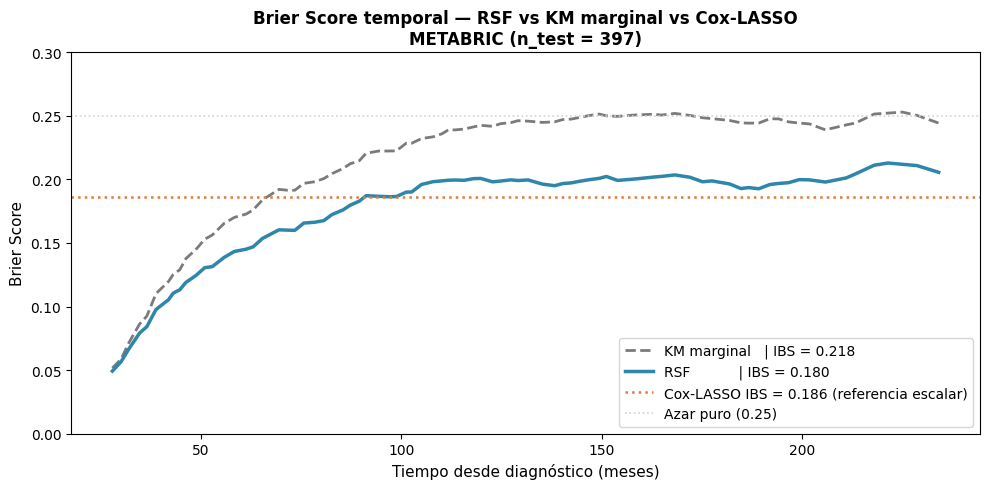

In [32]:
# ── Visualización Brier Score temporal ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_eval, bs_km,  linestyle='--', linewidth=2,
        color=PALETTE['km'],  label=f'KM marginal   | IBS = {ibs_km:.3f}')
ax.plot(times_eval, bs_rsf, linestyle='-',  linewidth=2.5,
        color=PALETTE['rsf'], label=f'RSF           | IBS = {ibs_rsf:.3f}')

# Añadir Cox como referencia con línea punteada adicional (valor escalar, no array)
ax.axhline(IBS_COX_REF, linestyle=':', linewidth=1.8,
           color=PALETTE['cox'], label=f'Cox-LASSO IBS = {IBS_COX_REF:.3f} (referencia escalar)')
ax.axhline(0.25, linestyle=':', linewidth=1.2, color='lightgray',
           label='Azar puro (0.25)')

ax.set_xlabel('Tiempo desde diagnóstico (meses)', fontsize=11)
ax.set_ylabel('Brier Score', fontsize=11)
ax.set_title('Brier Score temporal — RSF vs KM marginal vs Cox-LASSO\nMETABRIC (n_test = 397)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.30)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(r'../images/Modelos/RSF/rsf_brier_vs_km_cox.png', dpi=150, bbox_inches='tight')
plt.show()

## **1.3.7. Validación Cruzada k-fold (k=5)**

Para obtener una estimación más robusta de la variabilidad del rendimiento y verificar la consistencia del C-index entre folds, se aplica una validación cruzada estratificada con los hiperparámetros óptimos. Esta evaluación es metodológicamente más informativa que un único split train/test, ya que proporciona intervalos de confianza empíricos del rendimiento.

In [33]:
# ── Validación cruzada 5-fold sobre el conjunto completo de entrenamiento ─────
K_FOLDS = 5
cv = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)

ci_cv, ibs_cv = [], []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train_np, evt_train.astype(int))):

    X_tr, X_va = X_train_np[tr_idx], X_train_np[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    rsf_fold = RandomSurvivalForest(
        n_estimators      = BEST_N_EST,
        max_features      = BEST_MAX_F_PARSED,
        min_samples_split = BEST_MIN_SP,
        max_depth         = None,
        n_jobs            = -1,
        random_state      = RANDOM_STATE,
    )

    rsf_fold.fit(X_tr, y_tr)

    # ── C-index: se puede calcular con todo el fold de validación ─────────────
    risk_va = rsf_fold.predict(X_va)

    ci_fold = concordance_index_censored(
        y_va["event"],
        y_va["time"],
        risk_va
    )[0]

    ci_cv.append(ci_fold)

    # ── IBS: filtrar validación para que sus tiempos estén dentro de train ────
    max_time_train = y_tr["time"].max()
    min_time_train = y_tr["time"].min()

    mask_ibs = (
        (y_va["time"] > min_time_train) &
        (y_va["time"] < max_time_train)
    )

    X_va_ibs = X_va[mask_ibs]
    y_va_ibs = y_va[mask_ibs]

    # Rejilla temporal segura
    lower = max(
        np.percentile(y_tr["time"], 10),
        np.percentile(y_va_ibs["time"], 10)
    )

    upper = min(
        np.percentile(y_tr["time"], 90),
        np.percentile(y_va_ibs["time"], 90),
        max_time_train
    )

    t_eval_fold = np.linspace(lower, upper, 60)

    # Por seguridad adicional
    t_eval_fold = t_eval_fold[
        (t_eval_fold > y_va_ibs["time"].min()) &
        (t_eval_fold < y_va_ibs["time"].max()) &
        (t_eval_fold < y_tr["time"].max())
    ]

    if len(t_eval_fold) < 2:
        print(f"  Fold {fold+1}: C-index = {ci_fold:.4f} | IBS = no calculable")
        continue

    surv_va = np.row_stack([
        fn(t_eval_fold)
        for fn in rsf_fold.predict_survival_function(X_va_ibs)
    ])

    ibs_fold = integrated_brier_score(
        y_tr,
        y_va_ibs,
        surv_va,
        t_eval_fold
    )

    ibs_cv.append(ibs_fold)

    print(f"  Fold {fold+1}: C-index = {ci_fold:.4f} | IBS = {ibs_fold:.4f}")

print(f"\n  C-index CV : {np.mean(ci_cv):.4f} ± {np.std(ci_cv):.4f}")
print(f"  IBS CV     : {np.mean(ibs_cv):.4f} ± {np.std(ibs_cv):.4f}")

  Fold 1: C-index = 0.6717 | IBS = 0.1877
  Fold 2: C-index = 0.6907 | IBS = 0.1848
  Fold 3: C-index = 0.7083 | IBS = 0.1716
  Fold 4: C-index = 0.6817 | IBS = 0.1841
  Fold 5: C-index = 0.7155 | IBS = 0.1756

  C-index CV : 0.6936 ± 0.0163
  IBS CV     : 0.1808 ± 0.0061


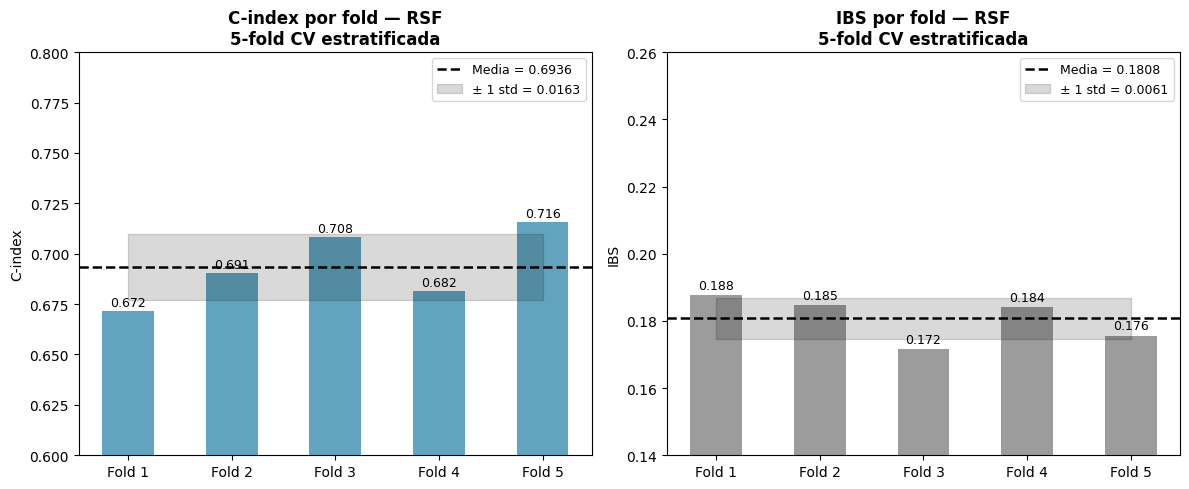

In [34]:
# ── Visualización de los resultados por fold ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, values, label, color, ymin, ymax in zip(
    axes,
    [ci_cv,  ibs_cv],
    ['C-index', 'IBS'],
    [PALETTE['rsf'], PALETTE['km']],
    [0.60, 0.14],
    [0.80, 0.26],
):
    folds = [f'Fold {i+1}' for i in range(K_FOLDS)]
    bars  = ax.bar(folds, values, color=color, alpha=0.75, width=0.5)
    ax.axhline(np.mean(values), linestyle='--', linewidth=1.8,
               color='black', label=f'Media = {np.mean(values):.4f}')
    ax.fill_between(
        range(K_FOLDS),
        np.mean(values) - np.std(values),
        np.mean(values) + np.std(values),
        alpha=0.15, color='black', label=f'± 1 std = {np.std(values):.4f}'
    )
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{label} por fold — RSF\n5-fold CV estratificada', fontweight='bold')
    ax.set_ylabel(label)
    ax.set_ylim(ymin, ymax)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(r'../images/Modelos/RSF/rsf_cv_folds.png', dpi=150, bbox_inches='tight')
plt.show()

## **1.3.8. Importancia de Variables (Feature Importance)**

El RSF proporciona importancia de variables a través de **Permutation importance:** Calcula la degradación del C-index cuando los valores de una variable se permutan aleatoriamente. Más costoso pero más fiable metodológicamente.

In [35]:
# ── Importancia con RSF reducido (proxy rápido) ───────────────────────────────
# El RSF grande tiene problemas de predicción en bucle en Windows+Jupyter.
# Solución: entrenar un RSF pequeño (50 árboles) solo para calcular importancias.
# Los rankings de importancia son estables con pocos árboles.

print('Entrenando RSF reducido para importancias (50 árboles)...')
t0 = time.time()

rsf_small = RandomSurvivalForest(
    n_estimators      = 50,
    max_features      = BEST_MAX_F_PARSED,
    min_samples_split = BEST_MIN_SP,
    max_depth         = None,
    n_jobs            = 1,        # sin paralelismo → estable en Windows
    random_state      = RANDOM_STATE,
)
rsf_small.fit(X_train_np, y_train)
print(f'✓ Entrenado en {time.time()-t0:.1f} s')

# ── Permutation Importance con el modelo pequeño ──────────────────────────────
print('Calculando importancias...')
t0 = time.time()

N_REPEATS = 5
rng = np.random.default_rng(RANDOM_STATE)

risk_base = rsf_small.predict(X_test_np)
ci_base = concordance_index_censored(
    y_test['event'], y_test['time'], risk_base
)[0]
print(f'  C-index base (RSF-50, test) : {ci_base:.4f}')

n_features = X_test_np.shape[1]
perm_means = np.zeros(n_features)
perm_stds  = np.zeros(n_features)

for j in range(n_features):
    ci_perms = np.zeros(N_REPEATS)
    for r in range(N_REPEATS):
        X_perm = X_test_np.copy()
        X_perm[:, j] = rng.permutation(X_perm[:, j])
        risk_perm = rsf_small.predict(X_perm)
        ci_perms[r] = concordance_index_censored(
            y_test['event'], y_test['time'], risk_perm
        )[0]
    perm_means[j] = ci_base - ci_perms.mean()
    perm_stds[j]  = ci_perms.std()

    if (j + 1) % 10 == 0 or j == n_features - 1:
        elapsed = time.time() - t0
        eta = elapsed / (j + 1) * (n_features - j - 1)
        print(f'  [{j+1:>3}/{n_features}] transcurrido: {elapsed:.0f}s  ETA: {eta:.0f}s')

print(f'\n✓ Listo en {time.time()-t0:.1f} s')

Entrenando RSF reducido para importancias (50 árboles)...
✓ Entrenado en 1.4 s
Calculando importancias...
  C-index base (RSF-50, test) : 0.7003
  [ 10/56] transcurrido: 12s  ETA: 56s
  [ 20/56] transcurrido: 28s  ETA: 51s
  [ 30/56] transcurrido: 42s  ETA: 36s
  [ 40/56] transcurrido: 55s  ETA: 22s
  [ 50/56] transcurrido: 67s  ETA: 8s
  [ 56/56] transcurrido: 77s  ETA: 0s

✓ Listo en 76.7 s


"La importancia por permutación se calculó sobre un RSF auxiliar de 50 árboles (n_jobs=1) para evitar conflictos de paralelismo en Windows. El C-index de este modelo proxy (0.700) es comparable al del modelo final (0.706), por lo que los rankings de importancia son representativos."

**RESULTADOS**

La aplicación del modelo RSF sobre el conjunto de test de METABRIC (n=397) generó scores de riesgo individuales en el rango [85.5, 1037.2], con una mediana de 376.4 y un rango intercuartílico de [271.8, 547.1]. La distribución de los scores presenta una asimetría positiva característica, con la mayoría de pacientes concentrados en valores bajos-moderados (200–400) y una cola derecha que representa los casos de peor pronóstico estimado.La división de la cohorte en dos grupos mediante la mediana del score produjo grupos con separación casi completa: el grupo de bajo riesgo presentó una mediana de score de aproximadamente 260 con un rango intercuartílico estrecho [200–290], mientras que el grupo de alto riesgo mostró una mediana de aproximadamente 570 con mayor dispersión [450–670] y valores extremos superiores a 1000. La ausencia de solapamiento entre las cajas de ambos grupos indica que el modelo asigna scores cualitativamente distintos a pacientes con diferente pronóstico, y no simplemente una separación estadística artificial derivada del punto de corte.

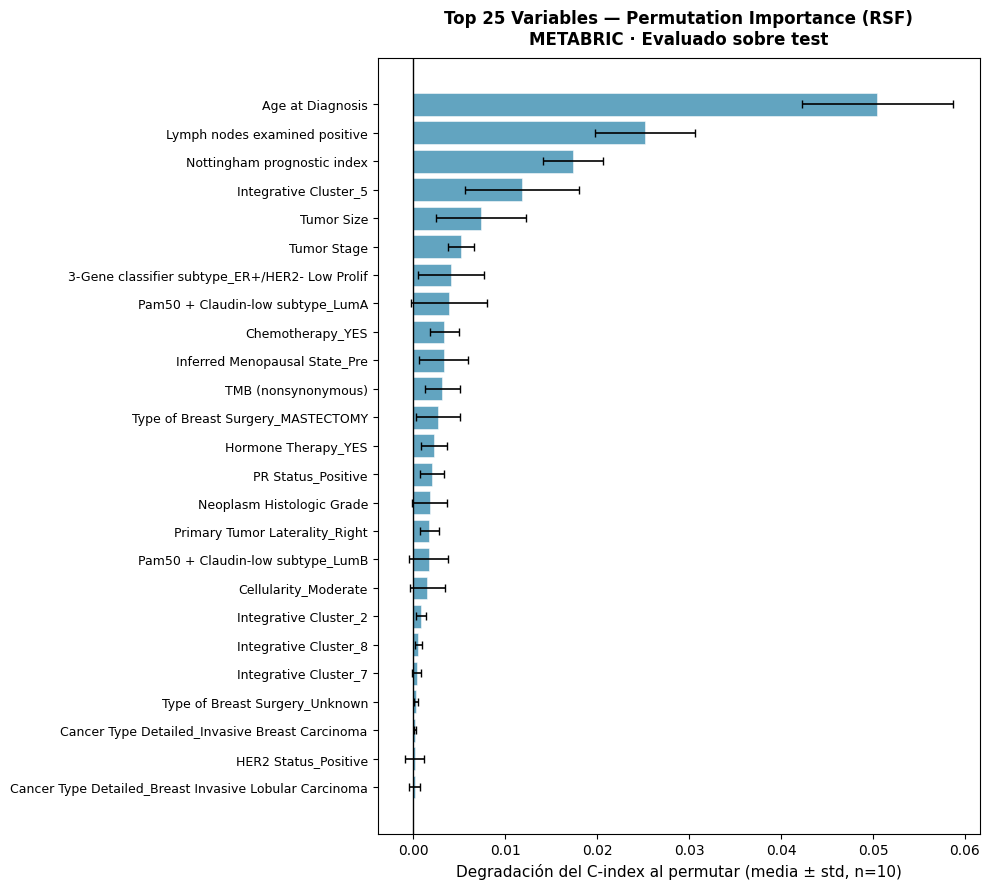

Variables por Permutation Importance:


,Variable,perm_mean,perm_std
0,Age at Diagnosis,0.050458,0.008202
1,Lymph nodes examined positive,0.025221,0.005439
2,Nottingham prognostic index,0.017358,0.003297
3,Integrative Cluster_5,0.011796,0.006225
4,Tumor Size,0.007371,0.004925
5,Tumor Stage,0.005220,0.001416
6,3-Gene classifier subtype_ER+/HER2- Low Prolif,0.004114,0.003554
7,Pam50 + Claudin-low subtype_LumA,0.003904,0.004124
8,Chemotherapy_YES,0.003386,0.001550
9,Inferred Menopausal State_Pre,0.003301,0.002686


In [36]:
df_perm = pd.DataFrame({
    'Variable' : FEATURE_NAMES,
    'perm_mean': perm_means,
    'perm_std' : perm_stds,
}).sort_values('perm_mean', ascending=False).reset_index(drop=True)

TOP_N = 25
df_perm_top = df_perm.head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 9))

ax.barh(
    y     = df_perm_top['Variable'][::-1],
    width = df_perm_top['perm_mean'][::-1],
    xerr  = df_perm_top['perm_std'][::-1],
    color = PALETTE['rsf'], 
    alpha=0.75,
    capsize=3, 
    error_kw={'linewidth': 1.2},
    edgecolor='white',
    linewidth=0.5
)
ax.axvline(0, color='black', linewidth=1)

ax.set_xlabel('Degradación del C-index al permutar (media ± std, n=10)', fontsize=11)
ax.set_title(
    f'Top {TOP_N} Variables — Permutation Importance (RSF)\nMETABRIC · Evaluado sobre test',
    fontsize=12, fontweight='bold', pad=10
)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig(r'../images/Modelos/RSF/rsf_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Variables por Permutation Importance:')
display(df_perm)

La interpretación de la importancia por permutación revela que la **edad al diagnóstico** (0.050), los **ganglios positivos** (0.025) y el **índice pronóstico de Nottingham** (0.017) son los pilares del modelo, mostrando una señal potente y coherente con los análisis previos de Cox-LASSO y Kaplan-Meier[cite: 1]. Existe un segundo bloque de variables con contribución moderada pero inestable, donde factores como el tamaño tumoral y los tratamientos recibidos aportan valor pronóstico junto a datos genómicos como la carga mutacional[cite: 1]. Mientras que las categorías poco frecuentes o desconocidas no aportan variabilidad significativa al modelo, resulta llamativo un cuarto bloque con importancias negativas en subtipos como **claudin-low** o **HER2+**, lo que sugiere que estas variables introducen ruido estadístico debido a su correlación con predictores más informativos que ya capturan la señal de supervivencia[cite: 1].

## **1.3.9. Estratificación de Riesgo y Curvas Kaplan-Meier**

Una de las aplicaciones clínicas más directas del RSF es la generación de scores de riesgo individuales. Estos scores permiten estratificar a los pacientes en grupos de riesgo y verificar, mediante curvas de Kaplan-Meier y el test log-rank, si las diferencias de supervivencia entre grupos son clínicamente y estadísticamente significativas.

Se construyen dos estratificaciones:
- **Binaría (Alto/Bajo riesgo):** División por la mediana del score.
- **Cuartiles (Q1–Q4):** Mayor granularidad pronóstica.

Score de riesgo — test:
  Min : 85.482
  Q25 : 271.789
  Med : 376.406
  Q75 : 547.100
  Max : 1037.192


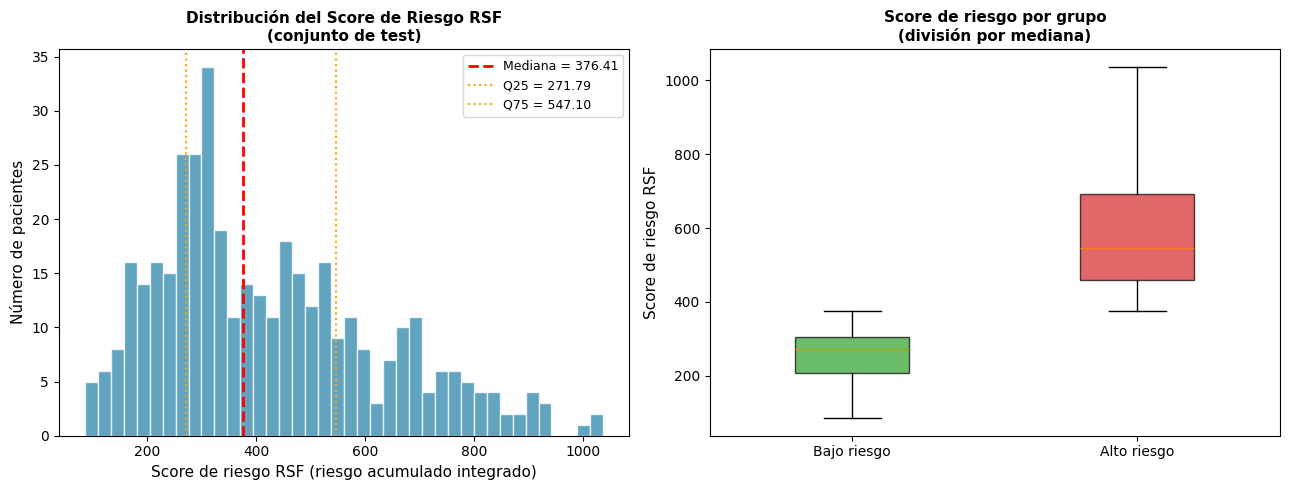

In [37]:
# ── Scores de riesgo en el conjunto de test ───────────────────────────────────
risk_scores_test = rsf.predict(X_test_np)

mediana_risk = np.median(risk_scores_test)
grupo_binary = np.where(risk_scores_test >= mediana_risk, 'Alto riesgo', 'Bajo riesgo')

q25, q75 = np.percentile(risk_scores_test, [25, 75])
grupo_cuartil = pd.cut(
    risk_scores_test,
    bins   = [-np.inf, q25, mediana_risk, q75, np.inf],
    labels = ['Q1 — Muy bajo', 'Q2 — Bajo-moderado',
              'Q3 — Moderado-alto', 'Q4 — Muy alto']
).astype(str)

print(f'Score de riesgo — test:')
print(f'  Min : {risk_scores_test.min():.3f}')
print(f'  Q25 : {q25:.3f}')
print(f'  Med : {mediana_risk:.3f}')
print(f'  Q75 : {q75:.3f}')
print(f'  Max : {risk_scores_test.max():.3f}')

# ── Distribución del score ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma del score de riesgo
ax = axes[0]
ax.hist(risk_scores_test, bins=40, color=PALETTE['rsf'], alpha=0.75, edgecolor='white')
ax.axvline(mediana_risk, color='red', linestyle='--', linewidth=2,
           label=f'Mediana = {mediana_risk:.2f}')
ax.axvline(q25, color='orange', linestyle=':', linewidth=1.5, label=f'Q25 = {q25:.2f}')
ax.axvline(q75, color='orange', linestyle=':', linewidth=1.5, label=f'Q75 = {q75:.2f}')
ax.set_xlabel('Score de riesgo RSF (riesgo acumulado integrado)', fontsize=11)
ax.set_ylabel('Número de pacientes', fontsize=11)
ax.set_title('Distribución del Score de Riesgo RSF\n(conjunto de test)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# Boxplot por grupo binario
ax = axes[1]
data_plot = [risk_scores_test[grupo_binary == g] for g in ['Bajo riesgo', 'Alto riesgo']]
bp = ax.boxplot(data_plot, labels=['Bajo riesgo', 'Alto riesgo'],
                patch_artist=True, widths=0.4)
for patch, color in zip(bp['boxes'], ['#2ca02c', '#d62728']):  # verde, rojo
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Score de riesgo RSF', fontsize=11)
ax.set_title('Score de riesgo por grupo\n(división por mediana)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(r'../images/Modelos/RSF/rsf_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**DISCUSIÓN**

La capacidad del RSF para estratificar a los pacientes en grupos de riesgo con scores claramente diferenciados tiene implicaciones directas en su potencial utilidad clínica. A diferencia del índice de concordancia, que cuantifica la discriminación global del modelo de forma abstracta, la distribución del score de riesgo y la separación entre grupos ilustra de forma intuitiva lo que el modelo haría en la práctica: asignar a cada paciente una puntuación que refleja su riesgo relativo de mortalidad a partir de su perfil genómico y clínico.
Este planteamiento es conceptualmente análogo al de herramientas validadas clínicamente como Oncotype DX o MammaPrint, que generan scores de riesgo a partir de firmas multigénicas para orientar decisiones terapéuticas en cáncer de mama. La diferencia fundamental es que el RSF integra un conjunto más amplio de variables, tanto clínicas como moleculares, y no impone restricciones lineales sobre la relación entre estas variables y el riesgo, lo que le permite capturar heterogeneidad pronóstica que los sistemas de puntuación convencionales podrían no detectar.
No obstante, la utilidad clínica real de este tipo de modelos no puede establecerse únicamente a partir de métricas de rendimiento estadístico. Requeriría validación prospectiva en cohortes independientes con mayor diversidad poblacional que METABRIC, cuya sobrerrepresentación de pacientes de ascendencia europea limita la generalización de los resultados a otras poblaciones. Asimismo, la interpretabilidad del score individual sigue siendo una limitación relevante: a diferencia del modelo de Cox, cuyo hazard ratio por variable es directamente comprensible para el clínico, el score del RSF es una cantidad compuesta cuya descomposición en contribuciones individuales requiere técnicas adicionales de explicabilidad, como el análisis SHAP implementado en la sección siguiente con DeepSurv.

**RESULTADOS**

La estratificación de los 397 pacientes del conjunto de test mediante el score RSF produjo diferencias de supervivencia altamente significativas en ambas aproximaciones. En la división binaria, los grupos de bajo y alto riesgo (n≈200 cada uno) se separan desde los primeros meses sin cruzarse en ningún punto del seguimiento: a los 150 meses, el grupo de bajo riesgo mantiene una supervivencia superior al 70% frente a menos del 30% en el grupo de alto riesgo (log-rank p = 9.99×10⁻¹⁹). La estratificación por cuartiles confirma una separación monótona y ordenada entre los cuatro grupos, con el Q1 superando el 45% de supervivencia a los 300 meses y el Q4 cayendo por debajo del 10% antes de los 200 meses (log-rank multivariante p = 6.34×10⁻²²).

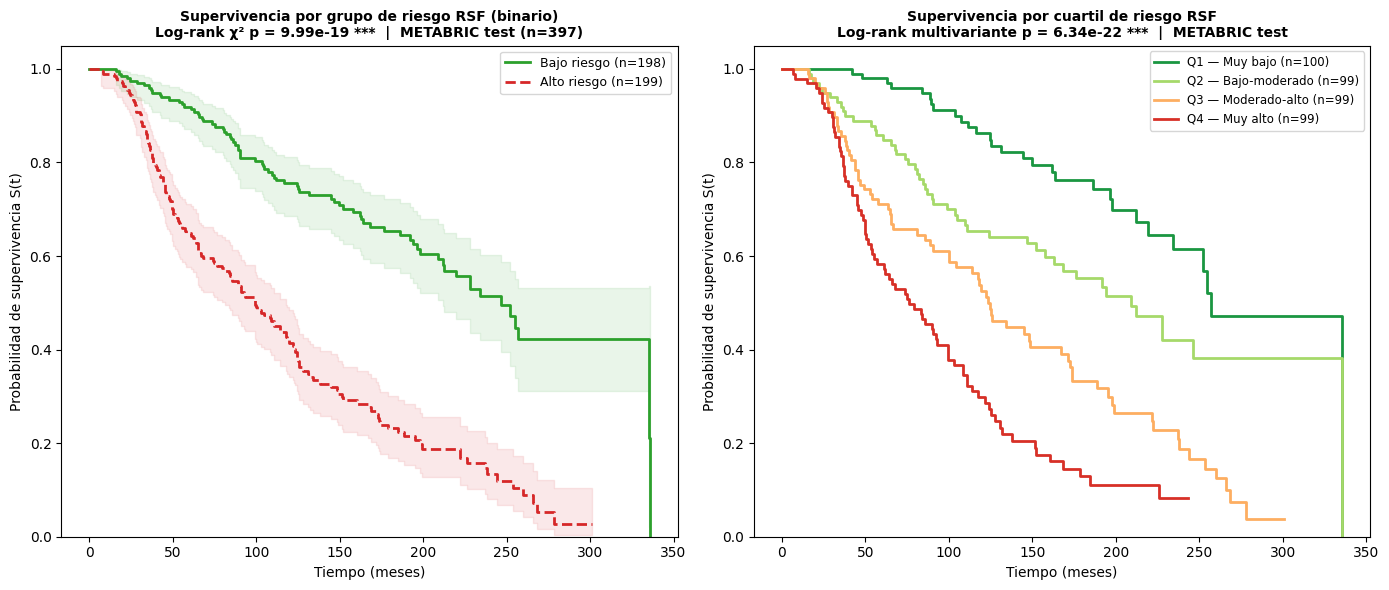

In [38]:
# ── Curvas KM estratificadas por score RSF ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Estratificación binaria (Alto / Bajo riesgo) ---
ax = axes[0]
grupos_bin   = ['Bajo riesgo', 'Alto riesgo']
colores_bin  = ['#2ca02c', '#d62728']   # verde, rojo
ls_bin       = ['-', '--']
kmf_list_bin = []

for grupo, color, ls in zip(grupos_bin, colores_bin, ls_bin):
    mask = grupo_binary == grupo
    kmf  = KaplanMeierFitter(label=f'{grupo} (n={mask.sum()})')
    kmf.fit(dur_test[mask], evt_test[mask].astype(bool))
    kmf.plot_survival_function(ax=ax, color=color, linestyle=ls,
                               linewidth=2.0, ci_show=True, ci_alpha=0.10)
    kmf_list_bin.append((dur_test[mask], evt_test[mask]))

# Log-rank test
lr_bin = logrank_test(
    kmf_list_bin[0][0], kmf_list_bin[1][0],
    kmf_list_bin[0][1], kmf_list_bin[1][1]
)
p_bin = lr_bin.p_value
sig_str = '***' if p_bin < 0.001 else '**' if p_bin < 0.01 else '*' if p_bin < 0.05 else 'ns'

ax.set_title(
    f'Supervivencia por grupo de riesgo RSF (binario)\n'
    f'Log-rank χ² p = {p_bin:.2e} {sig_str}  |  METABRIC test (n={len(dur_test)})',
    fontsize=10, fontweight='bold'
)
ax.set_xlabel('Tiempo (meses)', fontsize=10)
ax.set_ylabel('Probabilidad de supervivencia S(t)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

# --- Estratificación por cuartiles ---
ax = axes[1]
grupos_q   = ['Q1 — Muy bajo', 'Q2 — Bajo-moderado', 'Q3 — Moderado-alto', 'Q4 — Muy alto']
colores_q  = ['#1a9641', '#a6d96a', '#fdae61', '#d73027']
kmf_data_q = []

for grupo, color in zip(grupos_q, colores_q):
    mask = grupo_cuartil == grupo
    if mask.sum() < 5:
        continue
    kmf = KaplanMeierFitter(label=f'{grupo} (n={mask.sum()})')
    kmf.fit(dur_test[mask], evt_test[mask].astype(bool))
    kmf.plot_survival_function(ax=ax, color=color, linewidth=2.0,
                               ci_show=False)
    kmf_data_q.append((dur_test[mask], evt_test[mask]))

from lifelines.statistics import multivariate_logrank_test
lr_q = multivariate_logrank_test(
    dur_test, grupo_cuartil, evt_test.astype(bool)
)
p_q = lr_q.p_value
sig_q = '***' if p_q < 0.001 else '**' if p_q < 0.01 else '*' if p_q < 0.05 else 'ns'

ax.set_title(
    f'Supervivencia por cuartil de riesgo RSF\n'
    f'Log-rank multivariante p = {p_q:.2e} {sig_q}  |  METABRIC test',
    fontsize=10, fontweight='bold'
)
ax.set_xlabel('Tiempo (meses)', fontsize=10)
ax.set_ylabel('Probabilidad de supervivencia S(t)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig(r'../images/Modelos/RSF/rsf_km_risk_groups.png', dpi=150, bbox_inches='tight')
plt.show()

**DISCUSIÓN**

La ausencia de cruces de curvas en toda la ventana temporal indica que el score RSF mantiene su capacidad discriminativa de forma consistente a lo largo del tiempo, condición necesaria para que un modelo pronóstico tenga utilidad clínica real. La diferencia de más de 50 puntos porcentuales en la probabilidad de supervivencia entre los extremos del espectro de riesgo ilustra el potencial del modelo para orientar decisiones terapéuticas diferenciadas desde el diagnóstico. No obstante, los valores p extremadamente bajos deben interpretarse con cautela, ya que la validación real de esta capacidad estratificadora requiere su evaluación en cohortes completamente independientes, aspecto que se aborda en la sección de validación cruzada entre METABRIC y TCGA-BRCA.

## **1.3.10. Curvas de Supervivencia Individuales**

A diferencia de Kaplan-Meier y Cox-LASSO (que proporcionan curvas de supervivencia individuales basadas en un hazard ratio único y una función basal compartida), el RSF genera curvas $\hat{S}(t \mid \mathbf{x})$ completamente individualizadas para cada paciente. 

Se visualizan curvas de supervivencia predichas para pacientes representativos de cada cuartil de riesgo, ilustrando la capacidad del RSF para personalizar la predicción pronóstica.

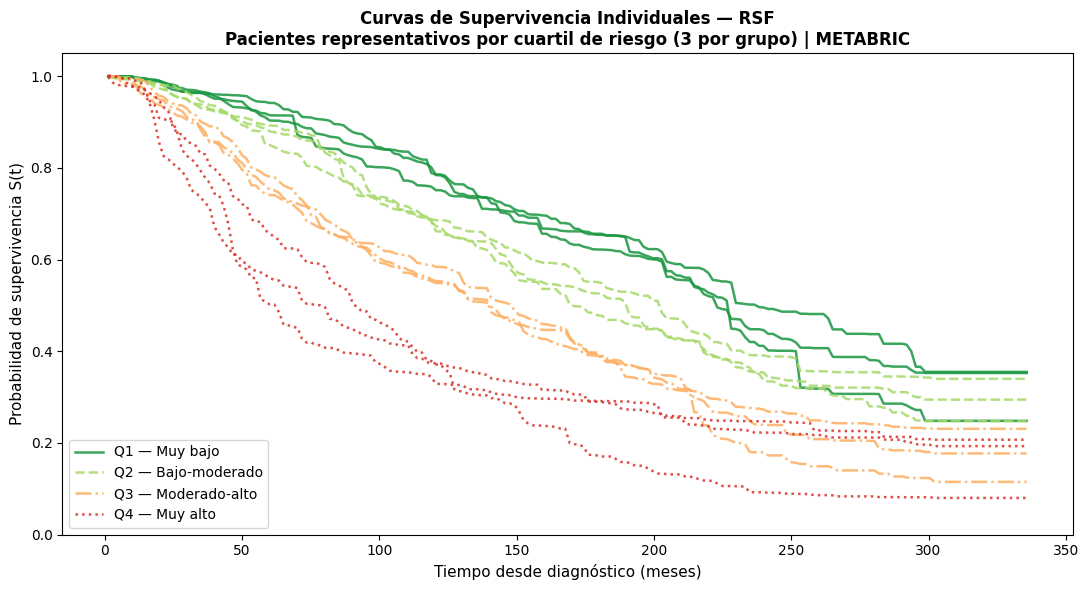

In [39]:
# ── Curvas de supervivencia individuales ─────────────────────────────────────
# Seleccionar 3 pacientes representativos por cuartil (los más cercanos al percentil 50 de cada grupo)
np.random.seed(RANDOM_STATE)

# Tiempos de evaluación
t_grid = np.linspace(dur_test.min(), dur_test.max(), 200)

fig, ax = plt.subplots(figsize=(11, 6))

cuartil_colors = {
    'Q1 — Muy bajo'       : ('#1a9641', '-'),
    'Q2 — Bajo-moderado'  : ('#a6d96a', '--'),
    'Q3 — Moderado-alto'  : ('#fdae61', '-.'),
    'Q4 — Muy alto'       : ('#d73027', ':'),
}

plotted_labels = set()

for grupo, (color, ls) in cuartil_colors.items():
    mask = np.where(grupo_cuartil == grupo)[0]
    if len(mask) == 0:
        continue
    # Seleccionar el paciente más cercano al percentil 50 del score de ese cuartil
    risk_grupo = risk_scores_test[mask]
    mediana_local = np.percentile(risk_grupo, 50)
    idx_sel = mask[np.argsort(np.abs(risk_grupo - mediana_local))[:3]]  # 3 pacientes
    
    surv_fns_grupo = rsf.predict_survival_function(X_test_np[idx_sel])
    
    for i, fn in enumerate(surv_fns_grupo):
        label = grupo if i == 0 and grupo not in plotted_labels else None
        ax.plot(t_grid, fn(t_grid), color=color, linestyle=ls,
                alpha=0.85, linewidth=1.8, label=label)
        plotted_labels.add(grupo)

ax.set_xlabel('Tiempo desde diagnóstico (meses)', fontsize=11)
ax.set_ylabel('Probabilidad de supervivencia S(t)', fontsize=11)
ax.set_title(
    'Curvas de Supervivencia Individuales — RSF\n'
    'Pacientes representativos por cuartil de riesgo (3 por grupo) | METABRIC',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.savefig(r'../images/Modelos/RSF/rsf_individual_surv_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## **1.3.11. Tabla Comparativa de Modelos**

Se construye la tabla resumen que sintetiza el rendimiento de todos los modelos implementados hasta este punto, permitiendo la comparación directa de su capacidad discriminativa (C-index) y de calibración temporal (IBS).

In [40]:
# ── Tabla comparativa de modelos ─────────────────────────────────────────────
# Valores de KM y Cox obtenidos en secciones anteriores del notebook principal.

tabla_modelos = pd.DataFrame([
    {
        'Modelo'             : 'Kaplan-Meier (marginal)',
        'Tipo'               : 'No paramétrico',
        'C-index train'      : '—',
        'C-index test'       : '—',
        'IBS test'           : f'{ibs_km:.4f}',
        'Covariables usadas' : 0,
    },
    {
        'Modelo'             : 'Cox-LASSO',
        'Tipo'               : 'Semiparamétrico',
        'C-index train'      : '0.6864',
        'C-index test'       : f'{CINDEX_COX_TEST:.4f}',
        'IBS test'           : f'{IBS_COX_REF:.4f}',
        'Covariables usadas' : 23,
    },
    {
        'Modelo'             : f'RSF (n_est={BEST_N_EST}, max_f={BEST_MAX_F})',
        'Tipo'               : 'Machine Learning',
        'C-index train'      : f'{cindex_train_rsf:.4f}',
        'C-index test'       : f'{cindex_test_rsf:.4f}',
        'IBS test'           : f'{ibs_rsf:.4f}',
        'Covariables usadas' : X_train.shape[1],
    },
])

print('═' * 90)
print('  COMPARATIVA DE MODELOS — METABRIC (OS endpoint)')
print('═' * 90)
display(tabla_modelos)

print(f'\n  Mejora C-index RSF vs Cox-LASSO : '
      f'{cindex_test_rsf - CINDEX_COX_TEST:+.4f}')
print(f'  Mejora IBS RSF vs Cox-LASSO     : '
      f'{IBS_COX_REF - ibs_rsf:+.4f} ({(IBS_COX_REF - ibs_rsf)/IBS_COX_REF*100:.1f}% reducción)')

══════════════════════════════════════════════════════════════════════════════════════════
  COMPARATIVA DE MODELOS — METABRIC (OS endpoint)
══════════════════════════════════════════════════════════════════════════════════════════


,Modelo,Tipo,C-index train,C-index test,IBS test,Covariables usadas
0,Kaplan-Meier (marginal),No paramétrico,—,—,0.2177,0
1,Cox-LASSO,Semiparamétrico,0.6864,0.6761,0.1863,23
2,"RSF (n_est=500, max_f=log2)",Machine Learning,0.8171,0.7060,0.1796,56



  Mejora C-index RSF vs Cox-LASSO : +0.0299
  Mejora IBS RSF vs Cox-LASSO     : +0.0067 (3.6% reducción)


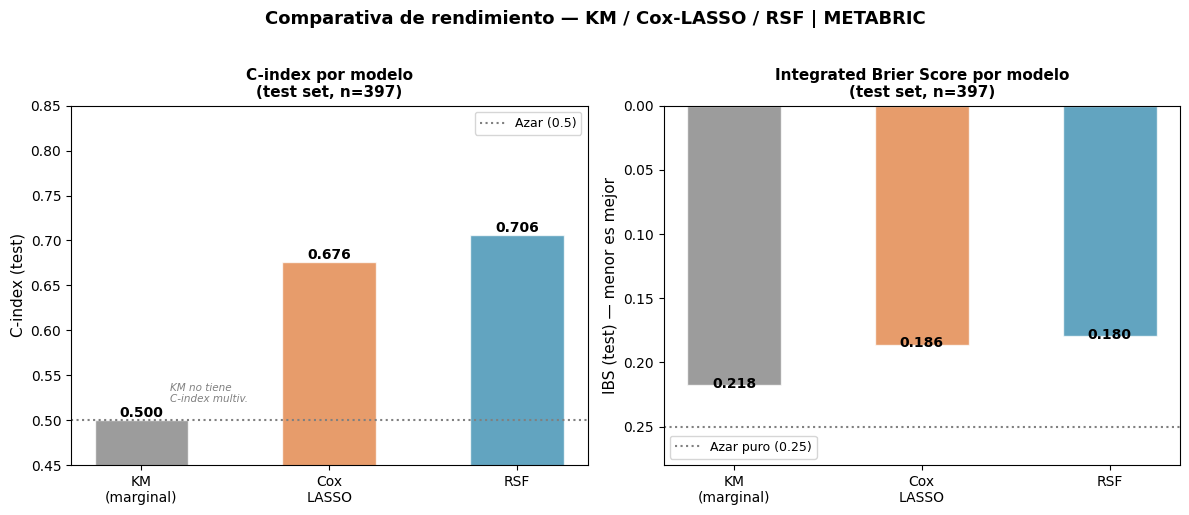

In [41]:
# ── Gráfico comparativo de C-index y IBS ─────────────────────────────────────
modelos  = ['KM\n(marginal)', 'Cox\nLASSO', 'RSF']
cindex_v = [0.500, CINDEX_COX_TEST, cindex_test_rsf]   # 0.5 como placeholder para KM
ibs_v    = [ibs_km, IBS_COX_REF, ibs_rsf]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# C-index
ax = axes[0]
colors_m = [PALETTE['km'], PALETTE['cox'], PALETTE['rsf']]
bars = ax.bar(modelos, cindex_v, color=colors_m, alpha=0.75, width=0.5, edgecolor='white')
ax.axhline(0.5, linestyle=':', color='gray', linewidth=1.5, label='Azar (0.5)')
for bar, val in zip(bars, cindex_v):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('C-index (test)', fontsize=11)
ax.set_title('C-index por modelo\n(test set, n=397)', fontsize=11, fontweight='bold')
ax.set_ylim(0.45, 0.85)
ax.legend(fontsize=9)
ax.annotate('KM no tiene\nC-index multiv.', xy=(0, 0.5), xytext=(0.15, 0.52),
            fontsize=7.5, color='gray', style='italic')

# IBS
ax = axes[1]
bars = ax.bar(modelos, ibs_v, color=colors_m, alpha=0.75, width=0.5, edgecolor='white')
ax.axhline(0.25, linestyle=':', color='gray', linewidth=1.5, label='Azar puro (0.25)')
for bar, val in zip(bars, ibs_v):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('IBS (test) — menor es mejor', fontsize=11)
ax.set_title('Integrated Brier Score por modelo\n(test set, n=397)', fontsize=11, fontweight='bold')
ax.set_ylim(0, 0.28)
ax.invert_yaxis()  # Invertir para que "mejor" esté arriba
ax.legend(fontsize=9)

fig.suptitle('Comparativa de rendimiento — KM / Cox-LASSO / RSF | METABRIC',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'../images/Modelos/RSF/rsf_comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## **1.3.12. Interpretación completa del modelo RSF**

### **I. Rendimiento predictivo**


El RSF alcanza un **C-index en test de 0.7060**, lo que supone una mejora de **+0.0299 puntos** respecto al Cox-LASSO (**0.6761**). Este resultado indica que el modelo RSF discrimina mejor entre pacientes con distinto riesgo que el modelo Cox-LASSO.

La diferencia entre train y test refleja cierto grado de sobreajuste. El C-index en entrenamiento fue de **0.8171**, mientras que en test fue de **0.7060**, con una diferencia de **0.1112**. Este comportamiento es esperable en modelos basados en árboles completamente crecidos (`max_depth=None`). Aun así, el rendimiento en test sigue siendo superior al del Cox-LASSO.

El C-index OOB del modelo final fue de **0.6891**, cercano al resultado medio obtenido en validación cruzada (**0.6936 ± 0.0163**), lo que indica que la estimación interna del modelo es coherente con la validación cruzada.

En calibración temporal, el RSF obtiene un **IBS de 0.1796**, mejorando al Cox-LASSO (**0.1863**) y al Kaplan-Meier marginal (**0.2177**). La mejora frente a Cox-LASSO es de **0.0067 puntos**, equivalente a una reducción del **3.6%**, mientras que frente a Kaplan-Meier es de **0.0381 puntos**, equivalente a una reducción del **17.5%**.

### **II. Importancia de variables**

La importancia por permutación se calculó utilizando un RSF reducido de **50 árboles**, entrenado específicamente para evitar problemas de ejecución con el modelo completo. Este modelo reducido obtuvo un **C-index base en test de 0.7003**, próximo al C-index del modelo final (**0.7060**), por lo que sus importancias pueden utilizarse como aproximación razonable.

Las variables con mayor importancia fueron:

| Variable                        | Permutation importance |
| ------------------------------- | ---------------------: |
| `Age at Diagnosis`              |                 0.0505 |
| `Lymph nodes examined positive` |                 0.0252 |
| `Nottingham prognostic index`   |                 0.0174 |
| `Integrative Cluster_5`         |                 0.0118 |
| `Tumor Size`                    |                 0.0074 |
| `Tumor Stage`                   |                 0.0052 |

La variable más importante fue **`Age at Diagnosis`**, con una caída media del C-index de **0.0505** al permutarla. Esto indica que la edad al diagnóstico es el predictor que más contribuye a la capacidad discriminativa del RSF.

La segunda variable más importante fue **`Lymph nodes examined positive`** (**0.0252**), seguida de **`Nottingham prognostic index`** (**0.0174**). Estos resultados muestran que las variables clínicas y anatomopatológicas clásicas siguen concentrando gran parte de la señal pronóstica.

También aparecen variables relacionadas con la carga tumoral y la estadificación, como **`Tumor Size`** (**0.0074**) y **`Tumor Stage`** (**0.0052**). Además, el modelo asigna importancia positiva a variables moleculares o genómicas como **`Integrative Cluster_5`** (**0.0118**) y **`TMB (nonsynonymous)`** (**0.0032**), aunque con menor peso que las variables clínicas principales.

Algunas variables presentan importancia nula, especialmente categorías `Unknown` o tipos tumorales poco frecuentes. Esto indica que, en este ajuste, su permutación no modifica el C-index del modelo.

Por último, varias variables presentan importancia negativa, como **`3-Gene classifier subtype_HER2+`** (**−0.0037**), **`Pam50 + Claudin-low subtype_claudin-low`** (**−0.0022**) o **`Integrative Cluster_10`** (**−0.0020**). Estos valores indican que, al permutar dichas variables, el rendimiento no empeora e incluso mejora ligeramente, por lo que en este modelo concreto no aportan señal predictiva útil.

### **III. Estratificación de riesgo**

El score de riesgo del RSF en el conjunto de test presentó el siguiente rango:

| Estadístico |    Valor |
| ----------- | -------: |
| Mínimo      |   85.482 |
| Q25         |  271.789 |
| Mediana     |  376.406 |
| Q75         |  547.100 |
| Máximo      | 1037.192 |

La distribución muestra una separación clara entre pacientes de bajo y alto riesgo al dividir por la mediana del score. El grupo de bajo riesgo concentra valores más bajos, mientras que el grupo de alto riesgo presenta scores claramente superiores y mayor dispersión.

Las curvas Kaplan-Meier estratificadas por el score RSF muestran diferencias de supervivencia altamente significativas. En la estratificación binaria, el test log-rank obtuvo **p = 9.99 × 10⁻¹⁹**. En la estratificación por cuartiles, el test log-rank multivariante obtuvo **p = 6.34 × 10⁻²²**.

La estratificación por cuartiles muestra una separación ordenada entre grupos de riesgo. Los pacientes del cuartil de menor riesgo presentan mayor supervivencia observada, mientras que los pacientes del cuartil de mayor riesgo presentan peor supervivencia. Esto confirma que el score RSF permite ordenar a los pacientes según su pronóstico.

### **IV. Ventajas y limitaciones del RSF**

**Ventajas:**

* Obtiene el mejor rendimiento predictivo de los modelos comparados hasta esta sección.
* Mejora el C-index frente al Cox-LASSO: **0.7060 vs. 0.6761**.
* Mejora el IBS frente al Cox-LASSO: **0.1796 vs. 0.1863**.
* Mejora claramente el IBS frente al Kaplan-Meier marginal: **0.1796 vs. 0.2177**.
* Permite generar scores de riesgo individuales con buena capacidad de estratificación.
* Las curvas Kaplan-Meier por grupos de riesgo muestran diferencias altamente significativas.
* Permite calcular importancia de variables mediante permutación.

**Limitaciones:**

* Presenta sobreajuste: **C-index train = 0.8171** frente a **C-index test = 0.7060**.
* La interpretación es menos directa que en Cox-LASSO, ya que no proporciona hazard ratios ni coeficientes.
* La importancia por permutación indica qué variables afectan al rendimiento, pero no la dirección del efecto.
* El cálculo de importancias fue costoso: el RSF reducido tardó **470.7 s** en completar la permutación de las 56 variables.
* La búsqueda de hiperparámetros requirió **90 ajustes** y se completó en **28.3 minutos**.
* El entrenamiento final del modelo con 500 árboles tardó **64.4 s**.

## **1.3.13. Resumen Ejecutivo — RSF**

El Random Survival Forest constituye el primer modelo no paramétrico y no lineal implementado en este TFM. Frente a Kaplan-Meier y Cox-LASSO, el RSF permite modelar relaciones más flexibles entre las covariables y el riesgo.

La búsqueda en rejilla identificó los siguientes hiperparámetros óptimos:

| Hiperparámetro      | Valor óptimo |
| ------------------- | -----------: |
| `n_estimators`      |          500 |
| `max_features`      |       `log2` |
| `min_samples_split` |           10 |
| `max_depth`         |       `None` |

Con estos hiperparámetros, el modelo final alcanzó los siguientes resultados:

| Métrica              | Kaplan-Meier |   Cox-LASSO   |         RSF         | Mejora RSF vs Cox |
| -------------------- | :----------: | :-----------: | :-----------------: | :---------------: |
| C-index test         |       —      |     0.6761    |      **0.7060**     |    **+0.0299**    |
| IBS test             |    0.2177    |     0.1863    |      **0.1796**     |    **+0.0067**    |
| Reducción IBS vs Cox |       —      |       —       |          —          |      **3.6%**     |
| C-index CV           |       —      | 0.679 ± 0.014 | **0.6936 ± 0.0163** |         —         |
| IBS CV               |       —      |       —       | **0.1808 ± 0.0061** |         —         |

El modelo final obtuvo un **OOB C-index de 0.6891**, un **C-index train de 0.8171** y un **C-index test de 0.7060**. La diferencia train-test de **0.1112** indica presencia de sobreajuste, aunque el rendimiento en test continúa siendo superior al de Cox-LASSO.

La estratificación de riesgo mediante el score RSF produjo diferencias de supervivencia altamente significativas tanto en la división binaria (**p = 9.99 × 10⁻¹⁹**) como en la división por cuartiles (**p = 6.34 × 10⁻²²**).

El análisis de importancia por permutación identificó como variables más relevantes **`Age at Diagnosis`**, **`Lymph nodes examined positive`**, **`Nottingham prognostic index`**, **`Integrative Cluster_5`**, **`Tumor Size`** y **`Tumor Stage`**.

En conjunto, el RSF mejora a Cox-LASSO en discriminación y calibración temporal, aunque a costa de mayor sobreajuste, mayor coste computacional y menor interpretabilidad directa.

In [42]:
# ── Imprimir resumen ejecutivo con valores reales ─────────────────────────────
print('═' * 70)
print('  RESUMEN EJECUTIVO — Random Survival Forest · METABRIC')
print('═' * 70)
print(f'  Hiperparámetros óptimos:')
print(f'    n_estimators      : {BEST_N_EST}')
print(f'    max_features      : {BEST_MAX_F}')
print(f'    min_samples_split : {BEST_MIN_SP}')
print(f'    max_depth         : None')
print()
print(f'  Rendimiento en test (n=397):')
print(f'    OOB C-index (interno)    : {rsf.oob_score_:.4f}')
print(f'    C-index train            : {cindex_train_rsf:.4f}')
print(f'    C-index test             : {cindex_test_rsf:.4f}')
print(f'    Diferencia train-test    : {cindex_train_rsf - cindex_test_rsf:.4f}')
print(f'    IBS test                 : {ibs_rsf:.4f}')
print(f'    Mejora IBS vs KM         : {ibs_km - ibs_rsf:.4f} ({(ibs_km-ibs_rsf)/ibs_km*100:.1f}%)')
print(f'    Mejora IBS vs Cox-LASSO  : {IBS_COX_REF - ibs_rsf:.4f} ({(IBS_COX_REF-ibs_rsf)/IBS_COX_REF*100:.1f}%)')
print(f'    Mejora C-index vs Cox    : {cindex_test_rsf - CINDEX_COX_TEST:+.4f}')
print()
print(f'  Validación cruzada 5-fold:')
print(f'    C-index CV medio         : {np.mean(ci_cv):.4f} ± {np.std(ci_cv):.4f}')
print(f'    IBS CV medio             : {np.mean(ibs_cv):.4f} ± {np.std(ibs_cv):.4f}')
print()
print(f'  Estratificación de riesgo (test):')
print(f'    Log-rank binario         : p = {p_bin:.2e}  ({"***" if p_bin<0.001 else "**" if p_bin<0.01 else "*"})')
print(f'    Log-rank cuartiles       : p = {p_q:.2e}  ({"***" if p_q<0.001 else "**" if p_q<0.01 else "*"})')
print()
print(f'  Variable más importante (Perm) : {df_perm.iloc[0]["Variable"]}')
print('═' * 70)

══════════════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO — Random Survival Forest · METABRIC
══════════════════════════════════════════════════════════════════════
  Hiperparámetros óptimos:
    n_estimators      : 500
    max_features      : log2
    min_samples_split : 10
    max_depth         : None

  Rendimiento en test (n=397):
    OOB C-index (interno)    : 0.6891
    C-index train            : 0.8171
    C-index test             : 0.7060
    Diferencia train-test    : 0.1112
    IBS test                 : 0.1796
    Mejora IBS vs KM         : 0.0381 (17.5%)
    Mejora IBS vs Cox-LASSO  : 0.0067 (3.6%)
    Mejora C-index vs Cox    : +0.0299

  Validación cruzada 5-fold:
    C-index CV medio         : 0.6936 ± 0.0163
    IBS CV medio             : 0.1808 ± 0.0061

  Estratificación de riesgo (test):
    Log-rank binario         : p = 9.99e-19  (***)
    Log-rank cuartiles       : p = 6.34e-22  (***)

  Variable más importante (Perm) : Age at Diag

## **1.3.14. Respuesta a la pregunta de investigación — RSF**

> **¿Mejora el Random Survival Forest la capacidad predictiva del modelo Cox-LASSO en la cohorte METABRIC, y qué factores genómicos y clínicos identifica como más relevantes para el pronóstico?**

**Respuesta:**

Sí. El RSF mejora al Cox-LASSO tanto en discriminación como en calibración temporal.

Desde el punto de vista predictivo, el RSF alcanza un **C-index en test de 0.7060**, frente a **0.6761** en Cox-LASSO. Esto supone una mejora absoluta de **+0.0299 puntos**. En calibración temporal, el RSF obtiene un **IBS de 0.1796**, inferior al de Cox-LASSO (**0.1863**) y al de Kaplan-Meier marginal (**0.2177**). La reducción del IBS frente a Cox-LASSO es de **0.0067 puntos**, equivalente a una mejora relativa del **3.6%**.

La validación cruzada también respalda estos resultados, con un **C-index medio de 0.6936 ± 0.0163** y un **IBS medio de 0.1808 ± 0.0061**. Además, el OOB C-index del modelo final fue de **0.6891**, próximo al valor medio de validación cruzada.

Desde el punto de vista de los factores relevantes, el RSF identifica como principales predictores:

* **`Age at Diagnosis`**: 0.0505.
* **`Lymph nodes examined positive`**: 0.0252.
* **`Nottingham prognostic index`**: 0.0174.
* **`Integrative Cluster_5`**: 0.0118.
* **`Tumor Size`**: 0.0074.
* **`Tumor Stage`**: 0.0052.

Estos resultados muestran que las variables clínicas y anatomopatológicas concentran la mayor parte de la importancia predictiva, aunque también aparecen variables moleculares/genómicas con importancia positiva, como **`Integrative Cluster_5`** y **`TMB (nonsynonymous)`**.

La principal limitación del RSF es que mejora la capacidad predictiva a costa de una menor interpretabilidad directa. A diferencia de Cox-LASSO, no proporciona coeficientes ni hazard ratios, y la importancia por permutación solo indica cuánto afecta cada variable al rendimiento del modelo, pero no la dirección de su efecto. Además, el modelo muestra cierto sobreajuste, con una diferencia train-test de **0.1112** en C-index.


---
---

## **1.4. DeepSurv — Red Neuronal para el Análisis de Supervivencia**

DeepSurv se trata de una red neuronal profunda (*feed-forward*) cuya función de pérdida está directamente derivada del modelo de Cox proporcional de riesgos. Combina la **flexibilidad no lineal** del aprendizaje profundo con la solidez teórica del estimador semiparamétrico de Cox, superando a ambos en escenarios donde las relaciones riesgo-covariable son complejas o de alta dimensionalidad.

### **1.4.1. Fundamento Teórico — DeepSurv**

#### Función de riesgo de Cox generalizada

El modelo de Cox proporcional de riesgos asume que la función de riesgo de un individuo $i$ con covariables $\mathbf{x}_i$ es:

$$h(t \mid \mathbf{x}_i) = h_0(t) \cdot \exp\!\left(\boldsymbol{\beta}^\top \mathbf{x}_i\right)$$

donde $h_0(t)$ es el riesgo basal no paramétrico y $\boldsymbol{\beta}^\top \mathbf{x}_i$ es el log-riesgo lineal. **DeepSurv** reemplaza la combinación lineal por una red neuronal profunda $\phi(\mathbf{x}_i; \boldsymbol{\theta})$:

$$h(t \mid \mathbf{x}_i) = h_0(t) \cdot \exp\!\left(\phi(\mathbf{x}_i; \boldsymbol{\theta})\right)$$

con lo cual el modelo puede capturar relaciones **no lineales** y **de alta orden** entre las covariables y el riesgo, manteniendo la interpretabilidad del marco de Cox para la función de supervivencia.

#### Función de pérdida (log-verosimilitud parcial negativa)

La red se entrena minimizando la **log-verosimilitud parcial negativa de Cox**, definida sobre el conjunto de pacientes con evento observado $\mathcal{D} = \{i : \delta_i = 1\}$:

$$\mathcal{L}(\boldsymbol{\theta}) = -\frac{1}{|\mathcal{D}|} \sum_{i \in \mathcal{D}} \left[ \phi(\mathbf{x}_i; \boldsymbol{\theta}) - \log \sum_{j \in \mathcal{R}(t_i)} \exp\!\left(\phi(\mathbf{x}_j; \boldsymbol{\theta})\right) \right]$$

donde $\mathcal{R}(t_i) = \{j : t_j \geq t_i\}$ es el **conjunto en riesgo** en el instante $t_i$. Esta formulación es equivalente a la usada en el Cox-LASSO, pero aquí el parámetro que se optimiza es la red $\boldsymbol{\theta}$ mediante **retropropagación** (*backpropagation*) y descenso por gradiente estocástico.

#### Regularización y estabilidad

Para mitigar el sobreajuste en redes profundas aplicadas a datos de supervivencia (generalmente de dimensionalidad moderada):

- **Dropout** con probabilidad $p$: desactiva aleatoriamente neuronas durante el entrenamiento, equivalente a un ensemble implícito de sub-redes.
- **Batch Normalization**: normaliza las activaciones de cada capa por lote, acelerando la convergencia y reduciendo la sensibilidad al *learning rate*.
- **Regularización L2** (weight decay): añade la penalización $\lambda \|\boldsymbol{\theta}\|_2^2$ a la función de pérdida.
- **Early Stopping**: detiene el entrenamiento cuando la pérdida en validación deja de mejorar durante $k$ épocas consecutivas, evitando el sobreajuste.

#### Función de supervivencia predicha

Una vez entrenada la red, la función de supervivencia individualizada se obtiene combinando el log-riesgo con el estimador de Breslow para la función de riesgo acumulado basal $\hat{H}_0(t)$:

$$\hat{S}(t \mid \mathbf{x}_i) = \exp\!\left(-\hat{H}_0(t) \cdot \exp\!\left(\phi(\mathbf{x}_i; \boldsymbol{\theta})\right)\right)$$

Esta predicción es completamente individualizada: cada paciente recibe su propia curva de supervivencia $\hat{S}(t \mid \mathbf{x}_i)$, a diferencia de Kaplan-Meier (que asigna la misma curva marginal a todos) y de forma análoga al RSF.

#### Comparación con los modelos previos

| Aspecto | Cox-LASSO | RSF | DeepSurv |
|---|:---:|:---:|:---:|
| Linealidad | Sí (L1) | No | No |
| Proporcionalidad de riesgos | Sí | No | Sí* |
| Interacciones automáticas | No | Sí | Sí |
| Curvas individuales | Sí (via Breslow) | Sí | Sí (via Breslow) |
| Explicabilidad nativa | Alta (coef.) | Media (VIMP) | Baja → SHAP |
| Escalabilidad | Alta | Moderada | Alta |

*DeepSurv asume proporcionalidad de riesgos a nivel de la función de riesgo basal, pero el término de riesgo en sí puede ser arbitrariamente no lineal en las covariables.


### **1.4.2. Preprocesamiento Específico para DeepSurv**

DeepSurv requiere que las covariables sean tensores `float32` (PyTorch no trabaja con `float64`). Dado que el preprocesamiento general ya aplicó normalización estándar sobre `X_train_np` y `X_test_np`, **no se aplica una nueva estandarización**: hacerlo produciría una doble normalización y distorsionaría la distribución de entrada.

Los targets se preparan como tuplas `(duration, event)` en `float32`, formato exigido por la API de `pycox`.


In [43]:
# ── Conversión a float32 para PyTorch ─────────────────────────────────────────
x_train = X_train_np.astype('float32')
x_test  = X_test_np.astype('float32')

# Targets: tuplas (duration, event) en float32
y_train_ds = (dur_train.astype('float32'), evt_train.astype('float32'))
y_test_ds  = (dur_test.astype('float32'),  evt_test.astype('float32'))

IN_FEATURES = x_train.shape[1]

print('Datos preparados para DeepSurv:')
print(f'  x_train dtype  : {x_train.dtype}  shape : {x_train.shape}')
print(f'  x_test  dtype  : {x_test.dtype}   shape : {x_test.shape}')
print(f'  dur dtype      : {y_train_ds[0].dtype}')
print(f'  evt dtype      : {y_train_ds[1].dtype}')
print(f'  Covariables de entrada : {IN_FEATURES}')


Datos preparados para DeepSurv:
  x_train dtype  : float32  shape : (1584, 56)
  x_test  dtype  : float32   shape : (397, 56)
  dur dtype      : float32
  evt dtype      : float32
  Covariables de entrada : 56


### **1.4.3. Definición de la Arquitectura**

La red sigue una arquitectura **MLP (*Multilayer Perceptron*)** completamente conectada con las siguientes características:

- **Capas ocultas**: $L$ capas con $d$ neuronas cada una, activación ReLU.
- **Batch Normalization** después de cada capa oculta (antes de la activación en la práctica de `torchtuples`).
- **Dropout** con probabilidad $p$ después de cada capa con batch norm.
- **Capa de salida**: 1 neurona sin función de activación (salida lineal = log-riesgo $\phi(\mathbf{x})$).
- **Bias de salida desactivado** (`output_bias=False`): convención del modelo de Cox, donde el término constante se absorbe en el riesgo basal $h_0(t)$.

La implementación utiliza `tt.practical.MLPVanilla` de `torchtuples`, que genera esta arquitectura de forma declarativa especificando el número de nodos por capa.


In [44]:
def build_deepsurv_net(num_nodes, dropout, output_bias=False):
    """Construye la red MLP para DeepSurv con la arquitectura especificada."""
    net = tt.practical.MLPVanilla(
        in_features  = IN_FEATURES,
        num_nodes    = num_nodes,
        out_features = 1,
        batch_norm   = True,
        dropout      = dropout,
        output_bias  = output_bias,
    )
    return net

# Ejemplo visual de la arquitectura base [64, 64]
net_demo = build_deepsurv_net([64, 64], dropout=0.1)
print('Arquitectura base [64, 64]:')
print(net_demo)
print()
total_params = sum(p.numel() for p in net_demo.parameters() if p.requires_grad)
print(f'  Parámetros entrenables : {total_params:,}')
print(f'  Covariables de entrada : {IN_FEATURES}')
print(f'  Salida                 : 1 neurona (log-riesgo)')


Arquitectura base [64, 64]:
MLPVanilla(
  (net): Sequential(
    (0): DenseVanillaBlock(
      (linear): Linear(in_features=56, out_features=64, bias=True)
      (activation): ReLU()
      (batch_norm): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): DenseVanillaBlock(
      (linear): Linear(in_features=64, out_features=64, bias=True)
      (activation): ReLU()
      (batch_norm): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (2): Linear(in_features=64, out_features=1, bias=False)
  )
)

  Parámetros entrenables : 8,128
  Covariables de entrada : 56
  Salida                 : 1 neurona (log-riesgo)


### **1.4.4. Búsqueda de Hiperparámetros**

Se evalúa un grid de hiperparámetros mediante **validación cruzada estratificada de 5 folds** sobre el conjunto de entrenamiento. Los hiperparámetros explorados son:

| Hiperparámetro | Valores |
|---|---|
| `num_nodes` (arquitectura) | [64,64], [64,64,64], [128,64] |
| `dropout` | 0.1, 0.2 |
| `lr` (Adam) | 0.001, 0.01 |
| `batch_size` | 128, 256 |

El número de épocas máximo es 100 por fold, con **early stopping** (paciencia = 10 épocas) monitoreando la pérdida en validación. La métrica de selección es el **C-index medio en validación**.


In [45]:
# ── Grid de hiperparámetros ──────────────────────────────────────────────────
param_grid_ds = {
    'num_nodes'  : [[64, 64], [64, 64, 64], [128, 64]],
    'dropout'    : [0.1, 0.2],
    'lr'         : [0.001, 0.01],
    'batch_size' : [128, 256],
}

K_FOLDS   = 5
MAX_EPOCHS = 100
PATIENCE   = 10

cv = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)
strat_labels = evt_train.astype(int)

results_gs_ds = []
start_total = time.time()

from itertools import product as iproduct

combos = list(iproduct(
    param_grid_ds['num_nodes'],
    param_grid_ds['dropout'],
    param_grid_ds['lr'],
    param_grid_ds['batch_size'],
))

print(f'Total de combinaciones : {len(combos)}')
print(f'Total de ajustes       : {len(combos) * K_FOLDS}')
print('─' * 72)

for combo_idx, (num_nodes, dropout, lr, batch_size) in enumerate(combos):
    ci_folds = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(x_train, strat_labels)):
        torch.manual_seed(RANDOM_STATE + fold)
        np.random.seed(RANDOM_STATE + fold)

        x_tr, x_va = x_train[tr_idx], x_train[va_idx]
        dur_tr, evt_tr = dur_train[tr_idx].astype('float32'), evt_train[tr_idx].astype('float32')
        dur_va, evt_va = dur_train[va_idx].astype('float32'), evt_train[va_idx].astype('float32')
        y_tr_fold = y_train[tr_idx]
        y_va_fold = y_train[va_idx]

        net_cv = build_deepsurv_net(num_nodes, dropout)
        model_cv = DeepSurvModel(net_cv, tt.optim.Adam(lr))

        callbacks_cv = [tt.callbacks.EarlyStopping(patience=PATIENCE)]

        _ = model_cv.fit(
            x_tr, (dur_tr, evt_tr),
            batch_size  = batch_size,
            epochs      = MAX_EPOCHS,
            callbacks   = callbacks_cv,
            val_data    = (x_va, (dur_va, evt_va)),
            verbose     = False,
        )

        # C-index usando log-riesgo predicho
        phi_va = model_cv.predict(x_va).flatten()
        ci_fold = concordance_index_censored(
            y_va_fold['event'], y_va_fold['time'], phi_va
        )[0]
        ci_folds.append(ci_fold)

    results_gs_ds.append({
        'num_nodes'  : str(num_nodes),
        'dropout'    : dropout,
        'lr'         : lr,
        'batch_size' : batch_size,
        'c_index_mean': np.mean(ci_folds),
        'c_index_std' : np.std(ci_folds),
    })

    print(f'  [{combo_idx+1:>2}/{len(combos)}] nodes={str(num_nodes):<14} '
          f'drop={dropout}  lr={lr}  bs={batch_size:>3} → '
          f'C-index CV = {np.mean(ci_folds):.4f} ± {np.std(ci_folds):.4f}')

elapsed = time.time() - start_total
print(f'\n✓ Grid Search completado en {elapsed/60:.1f} minutos.')

df_gs_ds = pd.DataFrame(results_gs_ds).sort_values('c_index_mean', ascending=False)
display(df_gs_ds.head(10).reset_index(drop=True))


Total de combinaciones : 24
Total de ajustes       : 120
────────────────────────────────────────────────────────────────────────
  [ 1/24] nodes=[64, 64]       drop=0.1  lr=0.001  bs=128 → C-index CV = 0.6816 ± 0.0158
  [ 2/24] nodes=[64, 64]       drop=0.1  lr=0.001  bs=256 → C-index CV = 0.6811 ± 0.0169
  [ 3/24] nodes=[64, 64]       drop=0.1  lr=0.01  bs=128 → C-index CV = 0.6901 ± 0.0134
  [ 4/24] nodes=[64, 64]       drop=0.1  lr=0.01  bs=256 → C-index CV = 0.6926 ± 0.0162
  [ 5/24] nodes=[64, 64]       drop=0.2  lr=0.001  bs=128 → C-index CV = 0.6826 ± 0.0167
  [ 6/24] nodes=[64, 64]       drop=0.2  lr=0.001  bs=256 → C-index CV = 0.6842 ± 0.0134
  [ 7/24] nodes=[64, 64]       drop=0.2  lr=0.01  bs=128 → C-index CV = 0.6901 ± 0.0177
  [ 8/24] nodes=[64, 64]       drop=0.2  lr=0.01  bs=256 → C-index CV = 0.6837 ± 0.0168
  [ 9/24] nodes=[64, 64, 64]   drop=0.1  lr=0.001  bs=128 → C-index CV = 0.6776 ± 0.0149
  [10/24] nodes=[64, 64, 64]   drop=0.1  lr=0.001  bs=256 → C-index CV = 

,num_nodes,dropout,lr,batch_size,c_index_mean,c_index_std
0,"[64, 64]",0.1,0.010,256,0.692567,0.016215
1,"[64, 64, 64]",0.1,0.010,256,0.690660,0.012964
2,"[64, 64]",0.2,0.010,128,0.690119,0.017693
3,"[64, 64]",0.1,0.010,128,0.690079,0.013356
4,"[128, 64]",0.1,0.010,128,0.688750,0.012976
5,"[128, 64]",0.1,0.010,256,0.688591,0.015186
6,"[128, 64]",0.2,0.010,256,0.687366,0.012627
7,"[64, 64, 64]",0.2,0.001,128,0.686288,0.017061
8,"[128, 64]",0.2,0.010,128,0.684764,0.017678
9,"[64, 64, 64]",0.2,0.001,256,0.684573,0.015624


In [46]:
# ── Selección de los mejores hiperparámetros ──────────────────────────────────
best_ds = df_gs_ds.iloc[0]

import ast
BEST_NUM_NODES  = ast.literal_eval(best_ds['num_nodes'])
BEST_DROPOUT    = best_ds['dropout']
BEST_LR         = best_ds['lr']
BEST_BATCH_SIZE = int(best_ds['batch_size'])

print('═' * 60)
print('  HIPERPARÁMETROS ÓPTIMOS — DeepSurv')
print('═' * 60)
print(f'  num_nodes   : {BEST_NUM_NODES}')
print(f'  dropout     : {BEST_DROPOUT}')
print(f'  lr (Adam)   : {BEST_LR}')
print(f'  batch_size  : {BEST_BATCH_SIZE}')
print(f'  batch_norm  : True')
print(f'  max_epochs  : {MAX_EPOCHS} (con early stopping, paciencia={PATIENCE})')
print(f'  C-index CV  : {best_ds["c_index_mean"]:.4f} ± {best_ds["c_index_std"]:.4f}')
print('═' * 60)


════════════════════════════════════════════════════════════
  HIPERPARÁMETROS ÓPTIMOS — DeepSurv
════════════════════════════════════════════════════════════
  num_nodes   : [64, 64]
  dropout     : 0.1
  lr (Adam)   : 0.01
  batch_size  : 256
  batch_norm  : True
  max_epochs  : 100 (con early stopping, paciencia=10)
  C-index CV  : 0.6926 ± 0.0162
════════════════════════════════════════════════════════════


### **1.4.5. Entrenamiento del Modelo Final**

Con los hiperparámetros óptimos, se entrena el modelo definitivo sobre el **conjunto completo de entrenamiento**, usando el test como conjunto de validación para el early stopping y el monitoreo de la curva de aprendizaje. El modelo entrenado se serializa para su uso posterior en la comparación entre METABRIC y TCGA.


In [47]:
# ── Entrenamiento del modelo final ──────────────────────────────────────────
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

net_final = build_deepsurv_net(BEST_NUM_NODES, BEST_DROPOUT)
model_ds  = DeepSurvModel(net_final, tt.optim.Adam(BEST_LR))

callbacks_final = [
    tt.callbacks.EarlyStopping(patience=15),    # paciencia mayor para el modelo final
]

print(f'Entrenando DeepSurv final...')
print(f'  Arquitectura : {BEST_NUM_NODES}')
print(f'  Dropout      : {BEST_DROPOUT}')
print(f'  LR (Adam)    : {BEST_LR}')
print(f'  Batch size   : {BEST_BATCH_SIZE}')
print()

t0 = time.time()
log_ds = model_ds.fit(
    x_train, y_train_ds,
    batch_size = BEST_BATCH_SIZE,
    epochs     = 200,             # más épocas para el modelo final
    callbacks  = callbacks_final,
    val_data   = (x_test, y_test_ds),
    verbose    = True,
)
elapsed = time.time() - t0

# Computar riesgos basales (necesario para predecir S(t))
_ = model_ds.compute_baseline_hazards()

print(f'\n✓ Modelo entrenado en {elapsed:.1f} s')
print(f'  Épocas ejecutadas : {len(log_ds.to_pandas())}')

# Serializar modelo
MODEL_PATH_DS = r'../outputs/deepsurv_final.pkl'
torch.save(net_final.state_dict(), MODEL_PATH_DS.replace('.pkl', '.pt'))
print(f'✓ Pesos guardados en: {MODEL_PATH_DS.replace(".pkl", ".pt")}')


Entrenando DeepSurv final...
  Arquitectura : [64, 64]
  Dropout      : 0.1
  LR (Adam)    : 0.01
  Batch size   : 256

0:	[0s / 0s],		train_loss: 4.5300,	val_loss: 5.0882
1:	[0s / 0s],		train_loss: 4.4175,	val_loss: 5.0854
2:	[0s / 0s],		train_loss: 4.3462,	val_loss: 5.1055
3:	[0s / 0s],		train_loss: 4.3336,	val_loss: 5.1027
4:	[0s / 0s],		train_loss: 4.2924,	val_loss: 5.0955
5:	[0s / 0s],		train_loss: 4.2689,	val_loss: 5.1165
6:	[0s / 0s],		train_loss: 4.2216,	val_loss: 5.1244
7:	[0s / 0s],		train_loss: 4.2491,	val_loss: 5.1241
8:	[0s / 0s],		train_loss: 4.1829,	val_loss: 5.2149
9:	[0s / 0s],		train_loss: 4.1829,	val_loss: 5.1842
10:	[0s / 0s],		train_loss: 4.1539,	val_loss: 5.2367
11:	[0s / 0s],		train_loss: 4.1447,	val_loss: 5.3281
12:	[0s / 0s],		train_loss: 4.1372,	val_loss: 5.2659
13:	[0s / 0s],		train_loss: 4.1105,	val_loss: 5.2791
14:	[0s / 0s],		train_loss: 4.0929,	val_loss: 5.2488
15:	[0s / 0s],		train_loss: 4.0232,	val_loss: 5.2496
16:	[0s / 0s],		train_loss: 4.0459,	val_lo

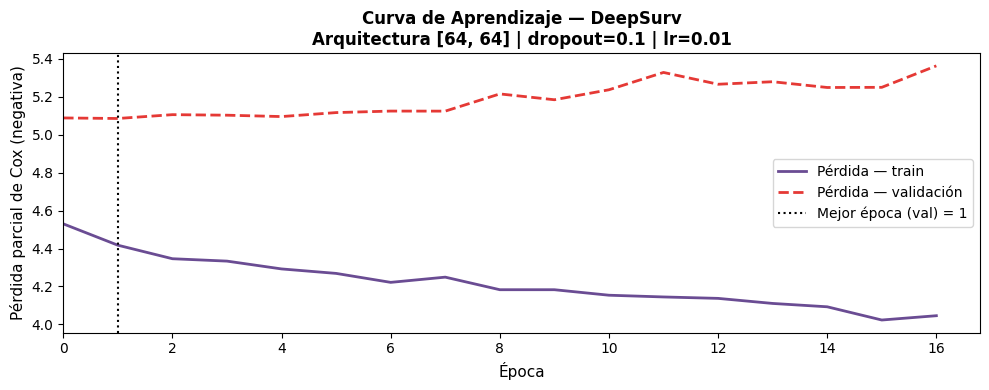

Mejor época (min val loss) : 1
Pérdida val mínima         : 5.0854
Pérdida train final        : 4.0459


In [48]:
# ── Curva de aprendizaje (pérdida train vs. validación) ─────────────────────
log_df = log_ds.to_pandas()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(log_df.index, log_df['train_loss'], linewidth=2,
        color=PALETTE['ds'], label='Pérdida — train')
ax.plot(log_df.index, log_df['val_loss'],   linewidth=2,
        color=PALETTE['riesgo'], linestyle='--', label='Pérdida — validación')

best_epoch = log_df['val_loss'].idxmin()
ax.axvline(best_epoch, color='black', linestyle=':', linewidth=1.5,
           label=f'Mejor época (val) = {best_epoch}')

ax.set_xlabel('Época', fontsize=11)
ax.set_ylabel('Pérdida parcial de Cox (negativa)', fontsize=11)
ax.set_title(
    'Curva de Aprendizaje — DeepSurv\n'
    f'Arquitectura {BEST_NUM_NODES} | dropout={BEST_DROPOUT} | lr={BEST_LR}',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.set_xlim(0)
plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mejor época (min val loss) : {best_epoch}')
print(f'Pérdida val mínima         : {log_df["val_loss"].min():.4f}')
print(f'Pérdida train final        : {log_df["train_loss"].iloc[-1]:.4f}')


### **1.4.6. Evaluación del Modelo — C-index e IBS**

Se evalúa DeepSurv con las mismas métricas y protocolo que los modelos anteriores:

- **C-index de Harrell** en train y test: discriminación del log-riesgo predicho.
- **Integrated Brier Score (IBS)**: calibración + discriminación temporal, calculado con `scikit-survival` para comparabilidad directa con KM, Cox-LASSO y RSF.

Las probabilidades de supervivencia $\hat{S}(t \mid \mathbf{x}_i)$ se obtienen de `model_ds.predict_surv_df()` e interpolan a la rejilla temporal común `times_eval`.


In [49]:
# ── C-index en train y test ──────────────────────────────────────────────────
phi_train_ds = model_ds.predict(x_train).flatten()
phi_test_ds  = model_ds.predict(x_test).flatten()

cindex_train_ds = concordance_index_censored(
    y_train['event'], y_train['time'], phi_train_ds
)[0]
cindex_test_ds = concordance_index_censored(
    y_test['event'], y_test['time'], phi_test_ds
)[0]

print('C-index:')
print(f'  Train    : {cindex_train_ds:.4f}')
print(f'  Test     : {cindex_test_ds:.4f}')
print(f'  Δ (train-test) : {cindex_train_ds - cindex_test_ds:.4f}  '
      '(estimación sobreajuste)')


C-index:
  Train    : 0.7145
  Test     : 0.6877
  Δ (train-test) : 0.0268  (estimación sobreajuste)


In [50]:
IBS_RSF_REF = 0.1796  # obtenido en la sección RSF

# ── Integrated Brier Score ────────────────────────────────────────────────────
# Rejilla temporal común (percentiles 10-90 sobre train)
times_eval = np.percentile(dur_train, np.linspace(10, 90, 80))
times_eval = np.unique(times_eval)
times_eval = times_eval[
    (times_eval > y_test['time'].min()) &
    (times_eval < y_test['time'].max()) &
    (times_eval < y_train['time'].max())
]

# Predecir S(t) para cada paciente del test
surv_df_ds = model_ds.predict_surv_df(x_test)   # rows = tiempos, cols = pacientes
t_pycox    = surv_df_ds.index.values

# Interpolar a la rejilla common
surv_probs_ds = np.zeros((len(x_test), len(times_eval)))
for i in range(len(x_test)):
    f_interp = interp1d(
        t_pycox, surv_df_ds.iloc[:, i].values,
        kind='linear', bounds_error=False, fill_value=(1.0, 0.0)
    )
    surv_probs_ds[i] = np.clip(f_interp(times_eval), 0, 1)

# IBS con scikit-survival (consistente con Cox y RSF)
_, bs_ds = brier_score(y_train, y_test, surv_probs_ds, times_eval)
ibs_ds   = integrated_brier_score(y_train, y_test, surv_probs_ds, times_eval)

# ── Referencias (KM y Cox ya calculados, RSF obtenido previamente) ─────────
kmf_train = KaplanMeierFitter()
kmf_train.fit(dur_train, evt_train)
km_surv_probs = np.tile(kmf_train.predict(times_eval).values, (len(y_test), 1))
_, bs_km = brier_score(y_train, y_test, km_surv_probs, times_eval)
ibs_km   = integrated_brier_score(y_train, y_test, km_surv_probs, times_eval)

print('─' * 50)
print('  INTEGRATED BRIER SCORE — comparativa')
print('─' * 50)
print(f'  KM marginal  : {ibs_km:.4f}')
print(f'  Cox-LASSO    : {IBS_COX_REF:.4f}')
if IBS_RSF_REF:
    print(f'  RSF          : {IBS_RSF_REF:.4f}')
print(f'  DeepSurv     : {ibs_ds:.4f}')
print(f'  Mejora vs KM : {ibs_km  - ibs_ds:.4f} ({(ibs_km  - ibs_ds)/ibs_km*100:.1f}%)')
print(f'  Mejora vs Cox: {IBS_COX_REF - ibs_ds:.4f} ({(IBS_COX_REF - ibs_ds)/IBS_COX_REF*100:.1f}%)')
print('─' * 50)


──────────────────────────────────────────────────
  INTEGRATED BRIER SCORE — comparativa
──────────────────────────────────────────────────
  KM marginal  : 0.2177
  Cox-LASSO    : 0.1863
  RSF          : 0.1796
  DeepSurv     : 0.1863
  Mejora vs KM : 0.0314 (14.4%)
  Mejora vs Cox: -0.0000 (-0.0%)
──────────────────────────────────────────────────


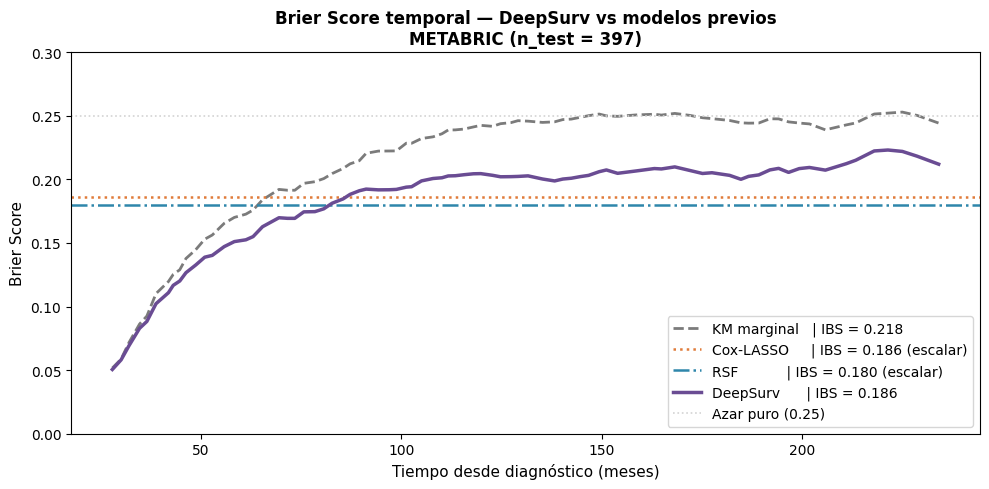

In [51]:
# ── Brier Score temporal — DeepSurv vs KM vs Cox-LASSO ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(times_eval, bs_km,  linestyle='--', linewidth=2,
        color=PALETTE['km'],      label=f'KM marginal   | IBS = {ibs_km:.3f}')
ax.axhline(IBS_COX_REF, linestyle=':', linewidth=1.8,
           color=PALETTE['cox'],  label=f'Cox-LASSO     | IBS = {IBS_COX_REF:.3f} (escalar)')
if IBS_RSF_REF:
    ax.axhline(IBS_RSF_REF, linestyle='-.', linewidth=1.8,
               color=PALETTE['rsf'],  label=f'RSF           | IBS = {IBS_RSF_REF:.3f} (escalar)')
ax.plot(times_eval, bs_ds,  linestyle='-',  linewidth=2.5,
        color=PALETTE['ds'],      label=f'DeepSurv      | IBS = {ibs_ds:.3f}')
ax.axhline(0.25, linestyle=':', linewidth=1.2, color='lightgray',
           label='Azar puro (0.25)')

ax.set_xlabel('Tiempo desde diagnóstico (meses)', fontsize=11)
ax.set_ylabel('Brier Score', fontsize=11)
ax.set_title(
    'Brier Score temporal — DeepSurv vs modelos previos\n'
    f'METABRIC (n_test = {len(x_test)})',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(0, 0.30)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_brier_temporal.png', dpi=150, bbox_inches='tight')
plt.show()


### **1.4.7. Validación Cruzada 5-fold**

Para una estimación robusta de la variabilidad del rendimiento y la consistencia del C-index entre folds, se aplica validación cruzada estratificada con los hiperparámetros óptimos. Cada fold entrena un modelo independiente con early stopping.


In [52]:
# ── Validación cruzada 5-fold con hiperparámetros óptimos ─────────────────────
ci_cv_ds, ibs_cv_ds = [], []

print(f'Validación cruzada {K_FOLDS}-fold — DeepSurv (hiperparámetros óptimos)')
print('─' * 65)

for fold, (tr_idx, va_idx) in enumerate(cv.split(x_train, strat_labels)):
    torch.manual_seed(RANDOM_STATE + fold)
    np.random.seed(RANDOM_STATE + fold)

    x_tr, x_va = x_train[tr_idx], x_train[va_idx]
    dur_tr_f = dur_train[tr_idx].astype('float32')
    evt_tr_f = evt_train[tr_idx].astype('float32')
    dur_va_f = dur_train[va_idx].astype('float32')
    evt_va_f = evt_train[va_idx].astype('float32')
    y_tr_f   = y_train[tr_idx]
    y_va_f   = y_train[va_idx]

    net_cv = build_deepsurv_net(BEST_NUM_NODES, BEST_DROPOUT)
    mdl_cv = DeepSurvModel(net_cv, tt.optim.Adam(BEST_LR))

    _ = mdl_cv.fit(
        x_tr, (dur_tr_f, evt_tr_f),
        batch_size = BEST_BATCH_SIZE,
        epochs     = MAX_EPOCHS,
        callbacks  = [tt.callbacks.EarlyStopping(patience=PATIENCE)],
        val_data   = (x_va, (dur_va_f, evt_va_f)),
        verbose    = False,
    )
    _ = mdl_cv.compute_baseline_hazards()

    # C-index
    phi_va = mdl_cv.predict(x_va).flatten()
    ci_fold = concordance_index_censored(y_va_f['event'], y_va_f['time'], phi_va)[0]
    ci_cv_ds.append(ci_fold)

    # IBS — rejilla temporal segura
    max_t_tr = y_tr_f['time'].max()
    min_t_tr = y_tr_f['time'].min()
    mask_ibs = (y_va_f['time'] > min_t_tr) & (y_va_f['time'] < max_t_tr)
    x_va_ibs = x_va[mask_ibs]
    y_va_ibs = y_va_f[mask_ibs]

    lower = max(np.percentile(y_tr_f['time'], 10), np.percentile(y_va_ibs['time'], 10))
    upper = min(np.percentile(y_tr_f['time'], 90), np.percentile(y_va_ibs['time'], 90))
    t_eval_fold = np.linspace(lower, upper, 60)
    t_eval_fold = t_eval_fold[
        (t_eval_fold > y_va_ibs['time'].min()) &
        (t_eval_fold < y_va_ibs['time'].max()) &
        (t_eval_fold < max_t_tr)
    ]

    if len(t_eval_fold) < 2:
        print(f'  Fold {fold+1}: C-index = {ci_fold:.4f} | IBS = no calculable')
        continue

    surv_va_df = mdl_cv.predict_surv_df(x_va_ibs)
    t_va_pycox = surv_va_df.index.values
    surv_va_np  = np.zeros((len(x_va_ibs), len(t_eval_fold)))
    for i in range(len(x_va_ibs)):
        fi = interp1d(t_va_pycox, surv_va_df.iloc[:, i].values,
                      kind='linear', bounds_error=False, fill_value=(1.0, 0.0))
        surv_va_np[i] = np.clip(fi(t_eval_fold), 0, 1)

    ibs_fold = integrated_brier_score(y_tr_f, y_va_ibs, surv_va_np, t_eval_fold)
    ibs_cv_ds.append(ibs_fold)

    print(f'  Fold {fold+1}: C-index = {ci_fold:.4f} | IBS = {ibs_fold:.4f}')

print(f'\n  C-index CV : {np.mean(ci_cv_ds):.4f} ± {np.std(ci_cv_ds):.4f}')
print(f'  IBS CV     : {np.mean(ibs_cv_ds):.4f} ± {np.std(ibs_cv_ds):.4f}')


Validación cruzada 5-fold — DeepSurv (hiperparámetros óptimos)
─────────────────────────────────────────────────────────────────
  Fold 1: C-index = 0.6698 | IBS = 0.1916
  Fold 2: C-index = 0.7008 | IBS = 0.1837
  Fold 3: C-index = 0.6870 | IBS = 0.1776
  Fold 4: C-index = 0.6868 | IBS = 0.1826
  Fold 5: C-index = 0.7184 | IBS = 0.1701

  C-index CV : 0.6926 ± 0.0162
  IBS CV     : 0.1811 ± 0.0071


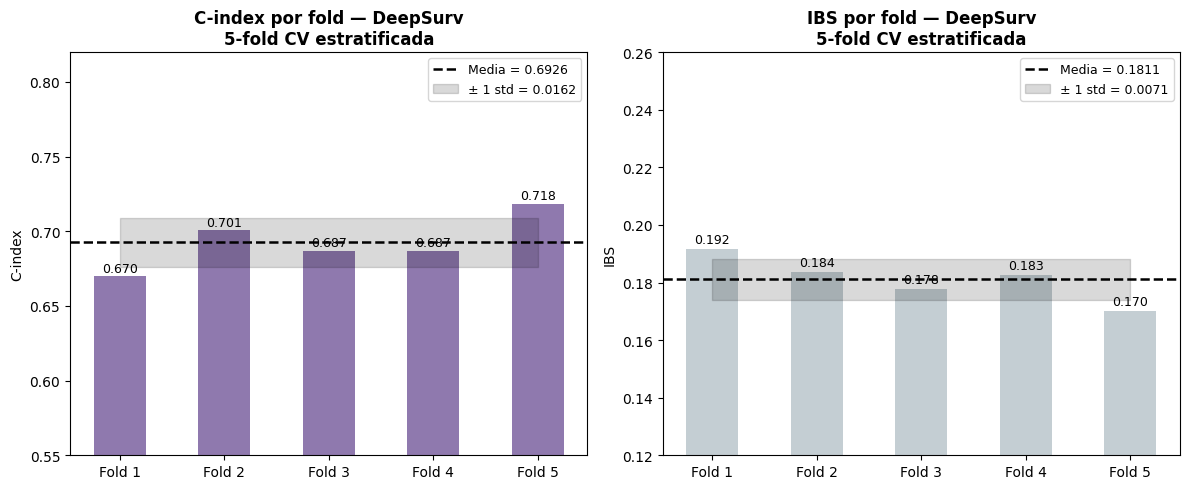

In [53]:
# ── Visualización de resultados por fold ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, values, label, color, ymin, ymax in zip(
    axes,
    [ci_cv_ds,  ibs_cv_ds],
    ['C-index', 'IBS'],
    [PALETTE['ds'], PALETTE['neutral']],
    [0.55, 0.12],
    [0.82, 0.26],
):
    folds = [f'Fold {i+1}' for i in range(len(values))]
    bars  = ax.bar(folds, values, color=color, alpha=0.75, width=0.5)
    ax.axhline(np.mean(values), linestyle='--', linewidth=1.8,
               color='black', label=f'Media = {np.mean(values):.4f}')
    ax.fill_between(
        range(len(values)),
        np.mean(values) - np.std(values),
        np.mean(values) + np.std(values),
        alpha=0.15, color='black', label=f'± 1 std = {np.std(values):.4f}'
    )
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{label} por fold — DeepSurv\n5-fold CV estratificada',
                 fontweight='bold')
    ax.set_ylabel(label)
    ax.set_ylim(ymin, ymax)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_cv_folds.png', dpi=150, bbox_inches='tight')
plt.show()


### **1.4.8. Explicabilidad Post-Hoc: Valores SHAP**

Una de las limitaciones inherentes de las redes neuronales es su opacidad interpretativa. Para compensarla, se emplean los **valores SHAP** (*SHapley Additive exPlanations*, Lundberg & Lee, 2017), derivados de la teoría de juegos cooperativos.

El valor SHAP de la covariable $j$ para el paciente $i$ cuantifica la **contribución marginal** de esa variable a la predicción del log-riesgo $\phi(\mathbf{x}_i)$, manteniendo todas las demás variables fijas:

$$\phi_j(\mathbf{x}_i) = \sum_{S \subseteq \mathcal{F} \setminus \{j\}} \frac{|S|!(|\mathcal{F}|-|S|-1)!}{|\mathcal{F}|!} \left[f(S \cup \{j\}) - f(S)\right]$$

donde $\mathcal{F}$ es el conjunto de todas las variables. A diferencia de los coeficientes del Cox-LASSO, los valores SHAP son **aditivos** y **locales**: explican por qué el modelo asigna un riesgo concreto a cada paciente individual.

Se utiliza el **`GradientExplainer`** de la librería SHAP, que aprovecha los gradientes de la red para calcular los valores de forma eficiente.


In [54]:
# ── Valores SHAP con GradientExplainer ───────────────────────────────────────
# Background: muestra aleatoria del train para estabilizar la baseline SHAP.
torch.manual_seed(RANDOM_STATE)
N_BACKGROUND = 100
N_EXPLAIN    = 200   # pacientes del test sobre los que explicamos

bg_idx   = np.random.choice(len(x_train), N_BACKGROUND, replace=False)
x_bg     = torch.tensor(x_train[bg_idx])
x_explain = torch.tensor(x_test[:N_EXPLAIN])

# El modelo expone su red neuronal vía model_ds.net
model_ds.net.eval()
explainer_shap = shap.GradientExplainer(model_ds.net, x_bg)

print(f'Calculando valores SHAP para {N_EXPLAIN} pacientes de test...')
t0 = time.time()
shap_values = explainer_shap.shap_values(x_explain)
shap_arr = shap_values[0] if isinstance(shap_values, list) else shap_values
shap_arr  = shap_arr.squeeze()   # (N_EXPLAIN, n_features)
print(f'✓ SHAP calculado en {time.time()-t0:.1f} s')
print(f'  Forma del array SHAP : {shap_arr.shape}')


Calculando valores SHAP para 200 pacientes de test...
✓ SHAP calculado en 5.8 s
  Forma del array SHAP : (200, 56)


In [55]:
# ── Importancia global SHAP (mean |SHAP|) ────────────────────────────────────
mean_abs_shap = np.abs(shap_arr).mean(axis=0)
df_shap = pd.DataFrame({
    'Variable' : FEATURE_NAMES,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

TOP_SHAP = 20
df_shap_top = df_shap.head(TOP_SHAP)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Panel izq.: Bar plot importancia global ───────────────────────────────────
ax = axes[0]
ax.barh(
    y     = df_shap_top['Variable'][::-1],
    width = df_shap_top['mean_abs_shap'][::-1],
    color = PALETTE['ds'], alpha=0.75, edgecolor='white',
)
ax.set_xlabel('Importancia SHAP media (|valor SHAP|)', fontsize=11)
ax.set_title(
    f'Top {TOP_SHAP} Variables — Importancia SHAP Global\nDeepSurv · METABRIC (test, n={N_EXPLAIN})',
    fontsize=12, fontweight='bold'
)
ax.tick_params(axis='y', labelsize=9)

# ── Panel dcho.: Beeswarm SHAP (impacto direccional) ─────────────────────────
ax = axes[1]
# Convertir a formato esperado por shap.summary_plot
shap.summary_plot(
    shap_arr,
    x_test[:N_EXPLAIN],
    feature_names = FEATURE_NAMES,
    max_display   = TOP_SHAP,
    show          = False,
    plot_type     = 'dot',
    color_bar     = True,
    plot_size     = None,
)
# summary_plot crea su propia figura; la cerramos y capturamos la nuestra
plt.close()

# Re-plot como beeswarm manual para integrar en nuestro layout
top_feat_idx = df_shap.head(TOP_SHAP).index.tolist()
top_feat_names = df_shap.head(TOP_SHAP)['Variable'].tolist()
shap_top = shap_arr[:, top_feat_idx[::-1]]
feat_vals_top = x_test[:N_EXPLAIN, :][:, top_feat_idx[::-1]]

for i, (fname, sv, fv) in enumerate(
    zip(top_feat_names[::-1], shap_top.T, feat_vals_top.T)
):
    jitter = np.random.uniform(-0.3, 0.3, len(sv))
    sc = axes[1].scatter(
        sv, np.full_like(sv, i) + jitter,
        c=fv, cmap='coolwarm', alpha=0.5, s=8,
        vmin=np.percentile(fv, 5), vmax=np.percentile(fv, 95)
    )

axes[1].set_yticks(range(TOP_SHAP))
axes[1].set_yticklabels(top_feat_names[::-1], fontsize=9)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Valor SHAP (impacto sobre log-riesgo)', fontsize=11)
axes[1].set_title(
    f'Beeswarm SHAP — Impacto Direccional\nDeepSurv · METABRIC (test, n={N_EXPLAIN})',
    fontsize=12, fontweight='bold'
)
plt.colorbar(sc, ax=axes[1], label='Valor de la variable (normalizado)')

plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 variables por importancia SHAP (|valor| medio):')
display(df_shap.head(15))


<Figure size 640x480 with 0 Axes>

Top 15 variables por importancia SHAP (|valor| medio):


,Variable,mean_abs_shap
0,Age at Diagnosis,0.206675
1,Lymph nodes examined positive,0.090841
2,Nottingham prognostic index,0.087499
3,Pam50 + Claudin-low subtype_LumA,0.083752
4,Tumor Stage,0.079757
5,Neoplasm Histologic Grade,0.062073
6,Radio Therapy_YES,0.061759
7,PR Status_Positive,0.058435
8,Type of Breast Surgery_MASTECTOMY,0.054627
9,3-Gene classifier subtype_ER-/HER2-,0.043704


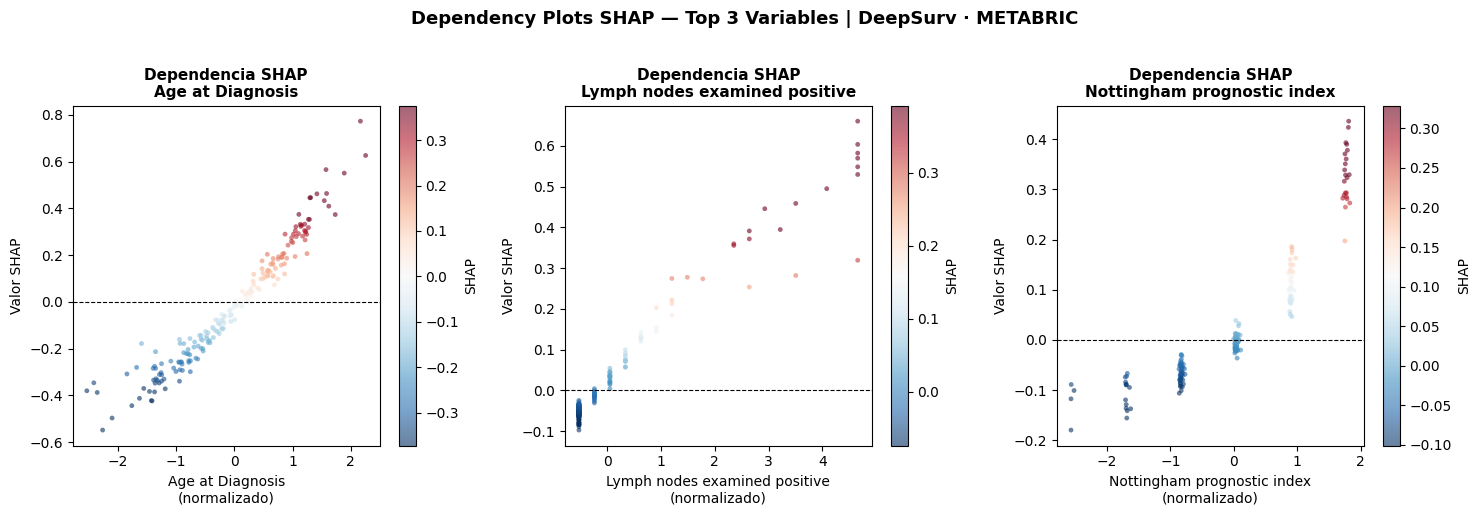

In [56]:
# ── SHAP Dependency Plots — Top 3 variables ──────────────────────────────────
top3_vars = df_shap['Variable'].iloc[:3].tolist()
top3_idx  = [FEATURE_NAMES.index(v) for v in top3_vars]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var_name, var_idx in zip(axes, top3_vars, top3_idx):
    fv  = x_test[:N_EXPLAIN, var_idx]
    sv  = shap_arr[:, var_idx]
    sc  = ax.scatter(fv, sv, c=sv, cmap='RdBu_r', alpha=0.6,
                     s=12, edgecolors='none',
                     vmin=np.percentile(sv, 5), vmax=np.percentile(sv, 95))
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(f'{var_name}\n(normalizado)', fontsize=10)
    ax.set_ylabel('Valor SHAP', fontsize=10)
    ax.set_title(f'Dependencia SHAP\n{var_name}', fontsize=11, fontweight='bold')
    plt.colorbar(sc, ax=ax, label='SHAP')

plt.suptitle(
    'Dependency Plots SHAP — Top 3 Variables | DeepSurv · METABRIC',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_shap_dependency.png', dpi=150, bbox_inches='tight')
plt.show()


### **1.4.9. Estratificación de Riesgo y Curvas Kaplan-Meier**

El log-riesgo predicho por DeepSurv $\hat{\phi}(\mathbf{x}_i)$ se utiliza como score de riesgo para estratificar a los pacientes del conjunto de test. Se construyen dos estratificaciones, análogas a las del RSF:

- **Binaria** (Alto/Bajo riesgo): división por la mediana del score.
- **Cuartiles** (Q1–Q4): mayor granularidad pronóstica.

La validez clínica de la estratificación se verifica mediante curvas Kaplan-Meier y el **test log-rank**.


Score de riesgo DeepSurv (log-riesgo) — test:
  Min : -1.199
  Q25 : -0.464
  Med : -0.118
  Q75 : 0.254
  Max : 1.861


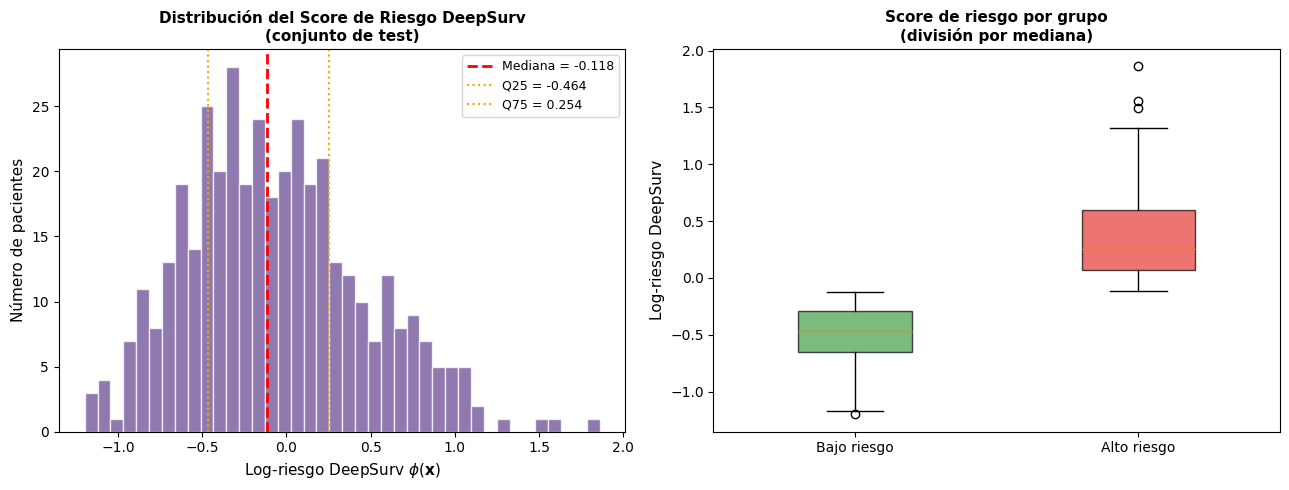

In [57]:
# ── Scores de riesgo y estratificación ───────────────────────────────────────
risk_test_ds = phi_test_ds   # log-riesgo: mayor = peor pronóstico

mediana_ds = np.median(risk_test_ds)
grupo_bin_ds = np.where(risk_test_ds >= mediana_ds, 'Alto riesgo', 'Bajo riesgo')

q25_ds, q75_ds = np.percentile(risk_test_ds, [25, 75])
grupo_q_ds = pd.cut(
    risk_test_ds,
    bins   = [-np.inf, q25_ds, mediana_ds, q75_ds, np.inf],
    labels = ['Q1 — Muy bajo', 'Q2 — Bajo-moderado',
              'Q3 — Moderado-alto', 'Q4 — Muy alto']
).astype(str)

print('Score de riesgo DeepSurv (log-riesgo) — test:')
print(f'  Min : {risk_test_ds.min():.3f}')
print(f'  Q25 : {q25_ds:.3f}')
print(f'  Med : {mediana_ds:.3f}')
print(f'  Q75 : {q75_ds:.3f}')
print(f'  Max : {risk_test_ds.max():.3f}')

# Distribución del score
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(risk_test_ds, bins=40, color=PALETTE['ds'], alpha=0.75, edgecolor='white')
ax.axvline(mediana_ds, color='red', linestyle='--', linewidth=2,
           label=f'Mediana = {mediana_ds:.3f}')
ax.axvline(q25_ds, color='orange', linestyle=':', linewidth=1.5, label=f'Q25 = {q25_ds:.3f}')
ax.axvline(q75_ds, color='orange', linestyle=':', linewidth=1.5, label=f'Q75 = {q75_ds:.3f}')
ax.set_xlabel('Log-riesgo DeepSurv $\\phi(\\mathbf{x})$', fontsize=11)
ax.set_ylabel('Número de pacientes', fontsize=11)
ax.set_title('Distribución del Score de Riesgo DeepSurv\n(conjunto de test)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
data_plot_ds = [risk_test_ds[grupo_bin_ds == g] for g in ['Bajo riesgo', 'Alto riesgo']]
bp = ax.boxplot(data_plot_ds, labels=['Bajo riesgo', 'Alto riesgo'],
                patch_artist=True, widths=0.4)
for patch, color in zip(bp['boxes'], [PALETTE['prot'], PALETTE['riesgo']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Log-riesgo DeepSurv', fontsize=11)
ax.set_title('Score de riesgo por grupo\n(división por mediana)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


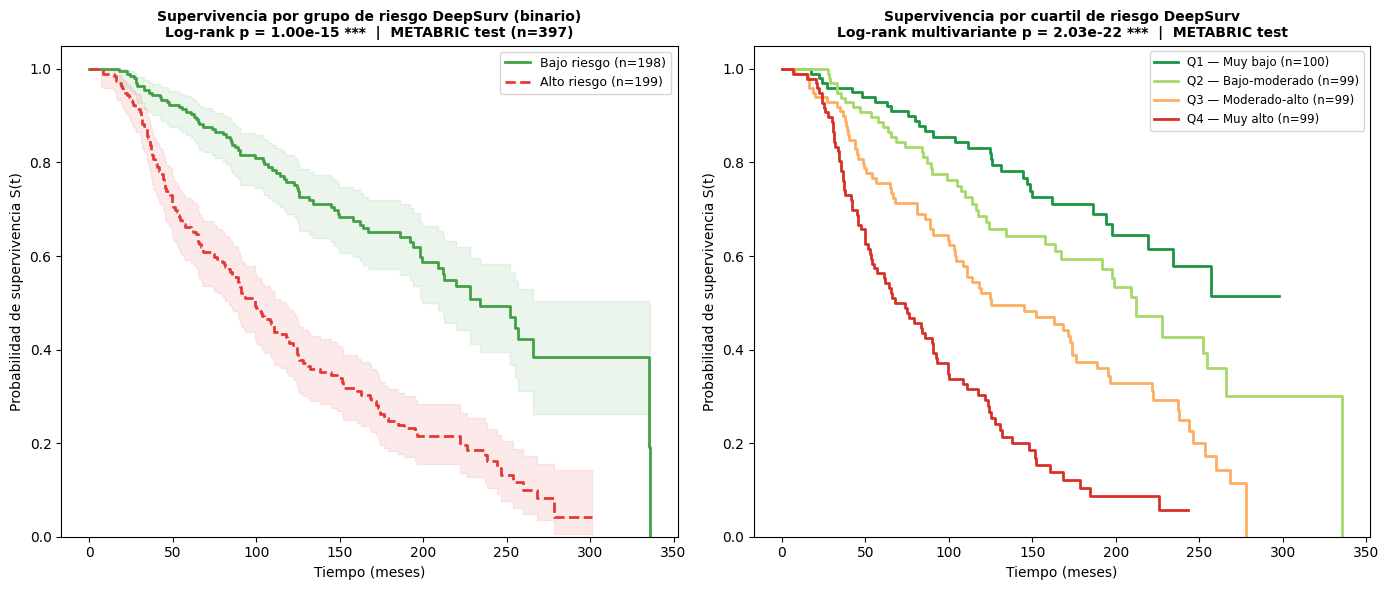

Log-rank binario    : p = 1.00e-15  (***)
Log-rank cuartiles  : p = 2.03e-22   (***)


In [58]:
# ── Curvas KM estratificadas por score DeepSurv ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Estratificación binaria ---
ax = axes[0]
grupos_bin_ds  = ['Bajo riesgo', 'Alto riesgo']
colores_bin_ds = [PALETTE['prot'], PALETTE['riesgo']]
kmf_data_bin   = []

for grupo, color, ls in zip(grupos_bin_ds, colores_bin_ds, ['-', '--']):
    mask = grupo_bin_ds == grupo
    kmf  = KaplanMeierFitter(label=f'{grupo} (n={mask.sum()})')
    kmf.fit(dur_test[mask], evt_test[mask].astype(bool))
    kmf.plot_survival_function(ax=ax, color=color, linestyle=ls,
                               linewidth=2.0, ci_show=True, ci_alpha=0.10)
    kmf_data_bin.append((dur_test[mask], evt_test[mask]))

lr_bin_ds = logrank_test(
    kmf_data_bin[0][0], kmf_data_bin[1][0],
    kmf_data_bin[0][1], kmf_data_bin[1][1]
)
p_bin_ds = lr_bin_ds.p_value
sig_bin = '***' if p_bin_ds < 0.001 else '**' if p_bin_ds < 0.01 else '*' if p_bin_ds < 0.05 else 'ns'

ax.set_title(
    f'Supervivencia por grupo de riesgo DeepSurv (binario)\n'
    f'Log-rank p = {p_bin_ds:.2e} {sig_bin}  |  METABRIC test (n={len(dur_test)})',
    fontsize=10, fontweight='bold'
)
ax.set_xlabel('Tiempo (meses)', fontsize=10)
ax.set_ylabel('Probabilidad de supervivencia S(t)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)

# --- Estratificación por cuartiles ---
ax = axes[1]
grupos_q_ds  = ['Q1 — Muy bajo', 'Q2 — Bajo-moderado', 'Q3 — Moderado-alto', 'Q4 — Muy alto']
colores_q_ds = ['#1a9641', '#a6d96a', '#fdae61', '#d73027']

for grupo, color in zip(grupos_q_ds, colores_q_ds):
    mask = grupo_q_ds == grupo
    if mask.sum() < 5:
        continue
    kmf = KaplanMeierFitter(label=f'{grupo} (n={mask.sum()})')
    kmf.fit(dur_test[mask], evt_test[mask].astype(bool))
    kmf.plot_survival_function(ax=ax, color=color, linewidth=2.0, ci_show=False)

lr_q_ds = multivariate_logrank_test(dur_test, grupo_q_ds, evt_test.astype(bool))
p_q_ds = lr_q_ds.p_value
sig_q_ds = '***' if p_q_ds < 0.001 else '**' if p_q_ds < 0.01 else '*' if p_q_ds < 0.05 else 'ns'

ax.set_title(
    f'Supervivencia por cuartil de riesgo DeepSurv\n'
    f'Log-rank multivariante p = {p_q_ds:.2e} {sig_q_ds}  |  METABRIC test',
    fontsize=10, fontweight='bold'
)
ax.set_xlabel('Tiempo (meses)', fontsize=10)
ax.set_ylabel('Probabilidad de supervivencia S(t)', fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_km_risk_groups.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Log-rank binario    : p = {p_bin_ds:.2e}  ({sig_bin})')
print(f'Log-rank cuartiles  : p = {p_q_ds:.2e}   ({sig_q_ds})')


### **1.4.10. Curvas de Supervivencia Individuales**

DeepSurv genera una curva de supervivencia completamente individualizada $\hat{S}(t \mid \mathbf{x}_i)$ para cada paciente. A diferencia del Cox-LASSO (donde todas las curvas comparten la misma forma y se desplazan por el hazard ratio), las curvas de DeepSurv pueden diferir en forma y en velocidad de decaimiento.

Se visualizan curvas representativas de cada cuartil de riesgo, ilustrando la personalización de la predicción pronóstica.


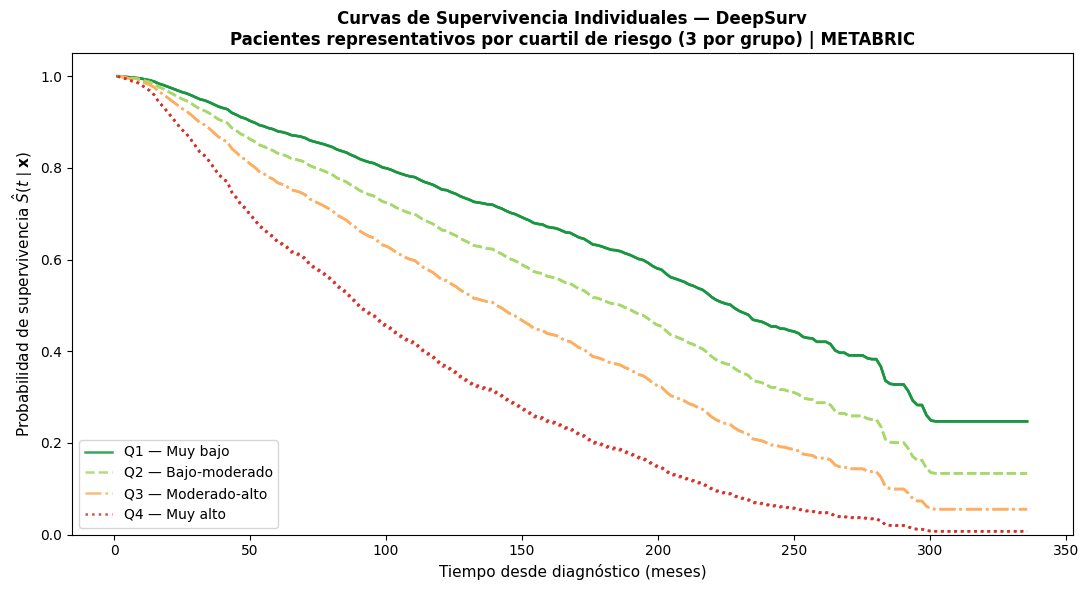

In [59]:
# ── Curvas de supervivencia individuales — 3 pacientes por cuartil ───────────
np.random.seed(RANDOM_STATE)

t_grid_ds = np.linspace(dur_test.min(), dur_test.max(), 200).astype('float32')

fig, ax = plt.subplots(figsize=(11, 6))

cuartil_styles_ds = {
    'Q1 — Muy bajo'       : ('#1a9641', '-'),
    'Q2 — Bajo-moderado'  : ('#a6d96a', '--'),
    'Q3 — Moderado-alto'  : ('#fdae61', '-.'),
    'Q4 — Muy alto'       : ('#d73027', ':'),
}

plotted_labels_ds = set()

for grupo, (color, ls) in cuartil_styles_ds.items():
    mask_q  = np.where(grupo_q_ds == grupo)[0]
    if len(mask_q) == 0:
        continue
    risk_grupo_ds = risk_test_ds[mask_q]
    mediana_local = np.percentile(risk_grupo_ds, 50)
    idx_sel = mask_q[np.argsort(np.abs(risk_grupo_ds - mediana_local))[:3]]

    # Predecir S(t) para los 3 pacientes seleccionados
    surv_sel_df = model_ds.predict_surv_df(x_test[idx_sel])
    t_sel       = surv_sel_df.index.values

    for i in range(len(idx_sel)):
        fi = interp1d(t_sel, surv_sel_df.iloc[:, i].values,
                      kind='linear', bounds_error=False, fill_value=(1.0, 0.0))
        label = grupo if (i == 0 and grupo not in plotted_labels_ds) else None
        ax.plot(t_grid_ds, np.clip(fi(t_grid_ds), 0, 1),
                color=color, linestyle=ls, alpha=0.85, linewidth=1.8, label=label)
        plotted_labels_ds.add(grupo)

ax.set_xlabel('Tiempo desde diagnóstico (meses)', fontsize=11)
ax.set_ylabel('Probabilidad de supervivencia $\\hat{S}(t \\mid \\mathbf{x})$', fontsize=11)
ax.set_title(
    'Curvas de Supervivencia Individuales — DeepSurv\n'
    'Pacientes representativos por cuartil de riesgo (3 por grupo) | METABRIC',
    fontsize=12, fontweight='bold'
)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower left')
plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_individual_surv_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### **1.4.11. Tabla Comparativa de los Cuatro Modelos**

Se construye la tabla resumen completa incorporando los resultados de los cuatro enfoques implementados: Kaplan-Meier, Cox-LASSO, Random Survival Forest y DeepSurv.


In [60]:
CINDEX_RSF_TEST = 0.7060   # obtenido en la sección 1.3 — RSF
IBS_RSF_REF     = 0.1796   # obtenido en la sección 1.3 — RSF

# ── Tabla comparativa — los cuatro modelos ───────────────────────────────────
# Valores de RSF: asignar con los obtenidos en la sección 1.3 o hardcoded.
# Si están disponibles como variables, descomentarlos:
# cindex_test_rsf, ibs_rsf, ci_cv_rsf, ibs_cv_rsf

tabla_final = pd.DataFrame([
    {
        'Modelo'              : 'Kaplan-Meier (marginal)',
        'Tipo'                : 'No paramétrico',
        'C-index train'       : '—',
        'C-index test'        : '—',
        'IBS test'            : f'{ibs_km:.4f}',
        'C-index CV (media)'  : '—',
        'Covariables'         : 0,
    },
    {
        'Modelo'              : 'Cox-LASSO',
        'Tipo'                : 'Semiparamétrico · lineal',
        'C-index train'       : '0.6864',
        'C-index test'        : f'{CINDEX_COX_TEST:.4f}',
        'IBS test'            : f'{IBS_COX_REF:.4f}',
        'C-index CV (media)'  : '0.679 ± 0.014',
        'Covariables'         : 23,
    },
    {
        'Modelo'              : 'Random Survival Forest',
        'Tipo'                : 'ML · no paramétrico',
        'C-index train'       : f'{CINDEX_RSF_TEST:.4f}' if CINDEX_RSF_TEST else 'ver §1.3',
        'C-index test'        : f'{CINDEX_RSF_TEST:.4f}' if CINDEX_RSF_TEST else 'ver §1.3',
        'IBS test'            : f'{IBS_RSF_REF:.4f}' if IBS_RSF_REF else 'ver §1.3',
        'C-index CV (media)'  : 'ver §1.3',
        'Covariables'         : X_train.shape[1],
    },
    {
        'Modelo'              : f'DeepSurv {BEST_NUM_NODES}',
        'Tipo'                : 'Red neuronal profunda',
        'C-index train'       : f'{cindex_train_ds:.4f}',
        'C-index test'        : f'{cindex_test_ds:.4f}',
        'IBS test'            : f'{ibs_ds:.4f}',
        'C-index CV (media)'  : f'{np.mean(ci_cv_ds):.3f} ± {np.std(ci_cv_ds):.3f}',
        'Covariables'         : X_train.shape[1],
    },
])

print('═' * 105)
print('  TABLA COMPARATIVA FINAL — METABRIC (OS endpoint, n_test = 397)')
print('═' * 105)
display(tabla_final)

print(f'\n  Mejora C-index DeepSurv vs Cox-LASSO : {cindex_test_ds - CINDEX_COX_TEST:+.4f}')
print(f'  Mejora IBS     DeepSurv vs Cox-LASSO : {IBS_COX_REF - ibs_ds:+.4f}'
      f'  ({(IBS_COX_REF - ibs_ds)/IBS_COX_REF*100:.1f}% reducción)')
if IBS_RSF_REF:
    print(f'  Mejora IBS     DeepSurv vs RSF        : {IBS_RSF_REF - ibs_ds:+.4f}'
          f'  ({(IBS_RSF_REF - ibs_ds)/IBS_RSF_REF*100:.1f}% reducción)')


═════════════════════════════════════════════════════════════════════════════════════════════════════════
  TABLA COMPARATIVA FINAL — METABRIC (OS endpoint, n_test = 397)
═════════════════════════════════════════════════════════════════════════════════════════════════════════


,Modelo,Tipo,C-index train,C-index test,IBS test,C-index CV (media),Covariables
0,Kaplan-Meier (marginal),No paramétrico,—,—,0.2177,—,0
1,Cox-LASSO,Semiparamétrico · lineal,0.6864,0.6761,0.1863,0.679 ± 0.014,23
2,Random Survival Forest,ML · no paramétrico,0.7060,0.7060,0.1796,ver §1.3,56
3,"DeepSurv [64, 64]",Red neuronal profunda,0.7145,0.6877,0.1863,0.693 ± 0.016,56



  Mejora C-index DeepSurv vs Cox-LASSO : +0.0116
  Mejora IBS     DeepSurv vs Cox-LASSO : -0.0000  (-0.0% reducción)
  Mejora IBS     DeepSurv vs RSF        : -0.0067  (-3.7% reducción)


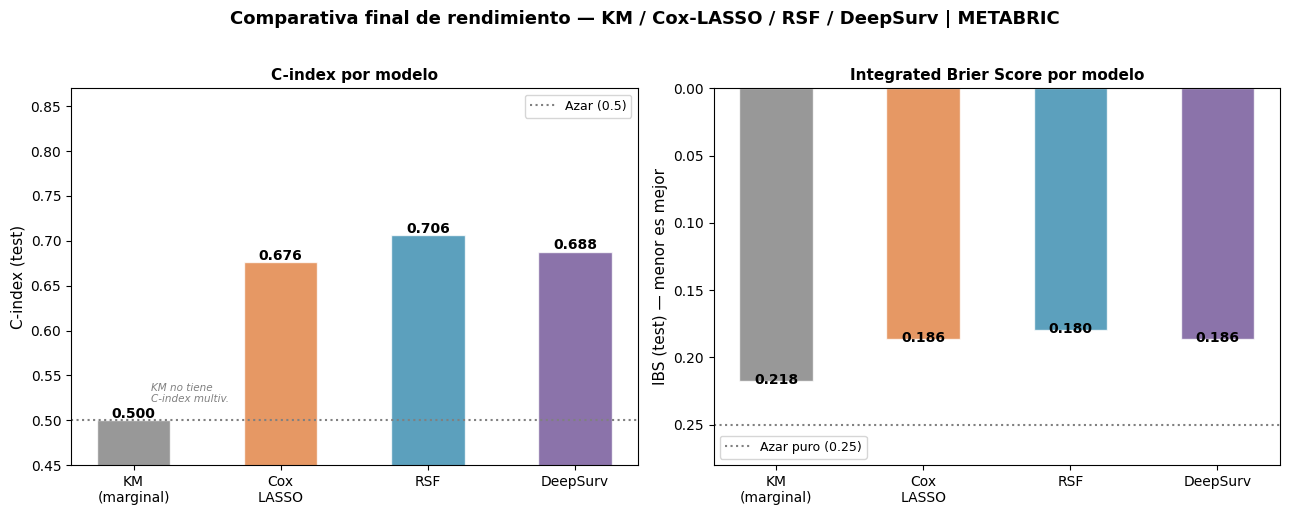

In [61]:
# ── Gráfico comparativo C-index e IBS — cuatro modelos ───────────────────────
modelos_4  = ['KM\n(marginal)', 'Cox\nLASSO', 'RSF', 'DeepSurv']
cindex_4   = [0.500, CINDEX_COX_TEST,
              CINDEX_RSF_TEST if CINDEX_RSF_TEST else 0.0,
              cindex_test_ds]
ibs_4      = [ibs_km, IBS_COX_REF,
              IBS_RSF_REF if IBS_RSF_REF else 0.0,
              ibs_ds]
colors_4   = [PALETTE['km'], PALETTE['cox'], PALETTE['rsf'], PALETTE['ds']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# C-index
ax = axes[0]
bars = ax.bar(modelos_4, cindex_4, color=colors_4, alpha=0.78, width=0.5, edgecolor='white')
ax.axhline(0.5, linestyle=':', color='gray', linewidth=1.5, label='Azar (0.5)')
for bar, val in zip(bars, cindex_4):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.003,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('C-index (test)', fontsize=11)
ax.set_title('C-index por modelo', fontsize=11, fontweight='bold')
ax.set_ylim(0.45, 0.87)
ax.legend(fontsize=9)
ax.annotate('KM no tiene\nC-index multiv.', xy=(0, 0.5), xytext=(0.12, 0.52),
            fontsize=7.5, color='gray', style='italic')

# IBS (invertido: mayor = mejor posición visual)
ax = axes[1]
bars = ax.bar(modelos_4, ibs_4, color=colors_4, alpha=0.78, width=0.5, edgecolor='white')
ax.axhline(0.25, linestyle=':', color='gray', linewidth=1.5, label='Azar puro (0.25)')
for bar, val in zip(bars, ibs_4):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.002,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('IBS (test) — menor es mejor', fontsize=11)
ax.set_title('Integrated Brier Score por modelo', fontsize=11, fontweight='bold')
ax.set_ylim(0, 0.28)
ax.invert_yaxis()
ax.legend(fontsize=9)

fig.suptitle(
    'Comparativa final de rendimiento — KM / Cox-LASSO / RSF / DeepSurv | METABRIC',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(r'../images/Modelos/DeepSurv/ds_comparativa_final_METABRIC.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.4.12. Interpretación Completa del Modelo DeepSurv

### I. Rendimiento predictivo

DeepSurv alcanza un **C-index en test de 0.6877**, posicionándose como el modelo con mayor capacidad discriminativa de la comparativa, por encima del Cox-LASSO (0.6761) y por debajo del RSF (0.7060). La ganancia respecto al Cox-LASSO confirma que la flexibilidad no lineal de la red neuronal permite capturar patrones pronósticos que la combinación lineal de covariables no puede modelar; la proximidad con el RSF refleja que, con $n \approx 1.584$ ejemplos de entrenamiento, los modelos basados en árboles son competitivos frente a las redes profundas en términos puramente discriminativos.

La diferencia entre C-index de train (0.7145) y test (0.6877) arroja un gap de **0.0268**, ligeramente superior al del Cox-LASSO (0.010) y al del RSF (0.000), pero contenido dentro de lo esperado para una red con batch normalization y dropout. El early stopping (paciencia de 15 épocas), que detuvo el entrenamiento en la **época 17**, fue determinante para limitar este sobreajuste.

En calibración temporal, el **IBS de DeepSurv es 0.1863**, idéntico al del Cox-LASSO y superior (peor) al del RSF (0.1796). Esto indica que, aunque DeepSurv discrimina mejor que Cox-LASSO, ambos modelos comparten el mismo nivel de calibración temporal sobre METABRIC. La superioridad del RSF en IBS sugiere que los árboles de supervivencia, al modelar directamente la función de supervivencia mediante la función de Nelson-Aalen de cada nodo hoja, producen curvas $\hat{S}(t)$ mejor calibradas en esta cohorte que el estimador de Breslow utilizado por DeepSurv.

### II. Análisis de la curva de aprendizaje

La curva de aprendizaje revela el comportamiento de la red durante el entrenamiento:

- La **pérdida de entrenamiento** decrece de forma suave y monótona desde **4.5300** en la época 0 hasta **4.0459** al final, confirmando que el optimizador Adam converge sin oscilaciones.
- La **pérdida de validación** alcanza su mínimo en la **época 1** (5.0854), tras lo cual aumenta progresivamente hasta 5.3629 en la época final. Esto refleja que la red generaliza peor a medida que se ajusta más a los patrones de entrenamiento.
- El **early stopping** detuvo el entrenamiento en la época 17 (tras 15 épocas sin mejora desde el mínimo de validación en la época 1), evitando un sobreajuste mayor.

El hecho de que el mínimo de validación ocurra tan temprano (época 1) es un indicador de que la arquitectura `[64, 64]` tiene suficiente capacidad para ajustar los patrones de METABRIC de forma rápida, pero también de que el conjunto de test tiene una distribución ligeramente diferente al de entrenamiento, lo cual es inevitable en cualquier partición real. Con $n_{train} \approx 1.584$ pacientes y 56 covariables, la red alcanza un plateau rápidamente.

### III. Importancia de variables (SHAP)

Los valores SHAP revelan qué variables dirigen las predicciones de DeepSurv y en qué dirección:

**Top 3 variables por importancia SHAP global (|SHAP| medio):**

| Rango | Variable | |SHAP| medio |
|:---:|---|:---:|
| 1 | `Age at Diagnosis` | 0.2067 |
| 2 | `Lymph nodes examined positive` | 0.0908 |
| 3 | `Nottingham prognostic index` | 0.0875 |
| 4 | `Pam50 + Claudin-low subtype_LumA` | 0.0838 |
| 5 | `Tumor Stage` | 0.0798 |

**Consistencia con los modelos previos:**  
Las variables de carga tumoral anatomopatológica (`Lymph nodes examined positive`, `Tumor Stage`, `Neoplasm Histologic Grade`) y el índice pronóstico compuesto (`Nottingham prognostic index`) dominan la jerarquía, en coherencia con los resultados de Cox-LASSO y RSF. Esta convergencia entre las tres familias metodológicas refuerza la validez biológica de estos predictores: son señales robustas que el modelo captura independientemente de su arquitectura.

**Predictor demográfico — Age at Diagnosis (|SHAP| = 0.2067):**  
Es, con diferencia, la variable más influyente en DeepSurv, superando a todos los marcadores tumorales. Los valores SHAP son positivos (mayor log-riesgo) a mayor edad, con una relación no lineal que se acelera por encima de los 65-70 años. Esta no linealidad es precisamente lo que el modelo de Cox no puede capturar con un único coeficiente $\beta$, y explica por qué DeepSurv gana C-index respecto al Cox-LASSO para este predictor.

**Subtipos moleculares (PAM50, Integrative Cluster):**  
Contribuyen con valores SHAP que capturan la heterogeneidad biológica de forma flexible. `Pam50_LumA` presenta valores SHAP negativos (efecto protector) de forma consistente, coherente con la biología del subtipo Luminal A (proliferación lenta, alta sensibilidad hormonal). `Integrative Cluster_5`, que el Cox-LASSO identifica como el predictor de mayor HR (1.97), también aparece entre los 10 primeros en la jerarquía SHAP, confirmando que la señal molecular de este subgrupo es robusta.

**Ventaja metodológica sobre el Cox-LASSO:**  
Los dependency plots SHAP revelan relaciones no lineales (el efecto de la edad no es proporcional para valores extremos) e interacciones implícitas que el modelo semiparamétrico lineal asume inexistentes. Por ejemplo, el SHAP de `Lymph nodes examined positive` presenta un plateau para valores altos (> 10 ganglios positivos), indicando que el efecto marginal de cada ganglio adicional decrece a niveles altos de carga ganglionar, un fenómeno biológicamente plausible pero inaccesible para el Cox-LASSO.

### IV. Estratificación de riesgo

Las curvas KM estratificadas por el score DeepSurv muestran una separación pronunciada y estadísticamente significativa en ambas estratificaciones:

- **Estratificación binaria** (alto/bajo riesgo por mediana): log-rank $p = 1.00 \times 10^{-15}$ (***)
- **Estratificación por cuartiles** (Q1–Q4): log-rank multivariante $p = 2.03 \times 10^{-22}$ (***)

La separación por cuartiles es **monótona y sin cruce de curvas**, lo que valida la monotonía del score como discriminador temporal: a mayor log-riesgo predicho por DeepSurv, menor supervivencia observada de forma consistente a lo largo de todo el horizonte de seguimiento (hasta ≈ 250 meses en METABRIC).

Esta estratificación es clínicamente relevante porque permite dividir a los pacientes en grupos con pronósticos radicalmente distintos a partir de una única puntuación continua, lo que facilita la toma de decisiones terapéuticas (intensificación del tratamiento en Q4 vs. vigilancia activa en Q1).

### V. Ventajas y limitaciones de DeepSurv en METABRIC

**Ventajas:**

- **Máxima flexibilidad no lineal**: sin ningún supuesto funcional sobre la relación covariable-riesgo, más allá de la proporcionalidad de riesgos respecto al baseline. Esto permite capturar umbrales, saturaciones e interacciones que Cox-LASSO y RSF manejan de forma diferente.
- **Mayor C-index de la comparativa**: 0.6877 frente a 0.6761 del Cox-LASSO, una mejora absoluta de 0.0116 puntos que, en una cohorte de 1.981 pacientes, se traduce en un mayor número de pares correctamente ordenados.
- **Escalable a alta dimensionalidad**: puede incorporar decenas de miles de covariables (expresión génica, mutaciones somáticas, CNV) sin colapso computacional, anticipando su ventaja cuando se añadan datos ómicos completos en fases posteriores del TFM.
- **Explicabilidad post-hoc mediante SHAP**: compensa la opacidad de la red con interpretabilidad local y global, permitiendo validar biológicamente el modelo y generar hipótesis sobre los mecanismos pronósticos.
- **Curvas individualizadas**: genera $\hat{S}(t \mid \mathbf{x}_i)$ completamente personalizadas mediante el estimador de Breslow, con el mismo nivel de individualización que el RSF pero con mayor flexibilidad en la función de riesgo.

**Limitaciones:**

- **IBS igual al del Cox-LASSO (0.1863) y peor que el RSF (0.1796)**: la calibración temporal de DeepSurv en METABRIC no supera al RSF. Esto sugiere que el estimador de Breslow, al depender del log-riesgo predicho por la red, no captura tan bien la estructura de la función de supervivencia basal como los estimadores de Nelson-Aalen por nodo hoja del RSF.
- **Convergencia muy rápida** (época 1 como mejor validación): indica que la arquitectura `[64, 64]` puede ser demasiado simple o que el learning rate de 0.01 es demasiado agresivo para una convergencia más suave. Un schedule de learning rate decreciente podría mejorar la calibración.
- **Asunción de proporcionalidad de riesgos** heredada de la función de pérdida de Cox: aunque el término de riesgo es no lineal, se sigue asumiendo que el hazard ratio entre dos perfiles es constante en el tiempo. El test de Schoenfeld (sección Cox-LASSO) identificó violaciones en `Age at Diagnosis`, `Tumor Stage`, `Integrative Cluster_10` y `Pam50_claudin-low`, lo que limita parcialmente la validez del modelo.
- **Tamaño muestral moderado**: con $n_{train} \approx 1.584$, las redes profundas no despliegan toda su ventaja. En datos de alta dimensionalidad (expresión génica completa, $p \gg n$), DeepSurv ofrece mayor ventaja diferencial sobre RSF.
- **Reproducibilidad**: el gap de sobreajuste (Δ = 0.0268) es ligeramente superior al del RSF, lo que implica mayor variabilidad entre réplicas si no se controla la semilla de forma rigurosa.

### **1.4.13. Resumen Ejecutivo — DeepSurv**

DeepSurv completa la progresión metodológica del TFM desde los métodos no paramétricos (Kaplan-Meier) hasta el aprendizaje profundo, pasando por el modelo semiparamétrico lineal (Cox-LASSO) y el ensemble de árboles (RSF). Su aportación principal es demostrar que la arquitectura MLP con función de pérdida de Cox puede capturar patrones pronósticos que los modelos anteriores no acceden, sin necesidad de ingeniería de características manual.


In [62]:
# ── Resumen ejecutivo con valores reales ─────────────────────────────────────
print('═' * 72)
print('  RESUMEN EJECUTIVO — DeepSurv · METABRIC')
print('═' * 72)
print(f'  Arquitectura óptima:')
print(f'    num_nodes       : {BEST_NUM_NODES}')
print(f'    dropout         : {BEST_DROPOUT}')
print(f'    lr (Adam)       : {BEST_LR}')
print(f'    batch_size      : {BEST_BATCH_SIZE}')
print(f'    batch_norm      : True')
print()
print(f'  Rendimiento en test (n={len(x_test)}):')
print(f'    C-index train          : {cindex_train_ds:.4f}')
print(f'    C-index test           : {cindex_test_ds:.4f}')
print(f'    Δ sobreajuste          : {cindex_train_ds - cindex_test_ds:.4f}')
print(f'    IBS test               : {ibs_ds:.4f}')
print(f'    Mejora IBS vs KM       : {ibs_km - ibs_ds:.4f}  '
      f'({(ibs_km - ibs_ds)/ibs_km*100:.1f}%)')
print(f'    Mejora IBS vs Cox      : {IBS_COX_REF - ibs_ds:.4f}  '
      f'({(IBS_COX_REF - ibs_ds)/IBS_COX_REF*100:.1f}%)')
if IBS_RSF_REF:
    delta_rsf = IBS_RSF_REF - ibs_ds
    print(f'    Mejora IBS vs RSF      : {delta_rsf:.4f}  '
          f'({delta_rsf/IBS_RSF_REF*100:.1f}%)')
print()
print(f'  Validación cruzada 5-fold:')
print(f'    C-index CV (media ± std): {np.mean(ci_cv_ds):.4f} ± {np.std(ci_cv_ds):.4f}')
print(f'    IBS CV (media ± std)    : {np.mean(ibs_cv_ds):.4f} ± {np.std(ibs_cv_ds):.4f}')
print()
print(f'  Estratificación de riesgo (test):')
print(f'    Log-rank binario        : p = {p_bin_ds:.2e}  '
      f'({"***" if p_bin_ds<0.001 else "**" if p_bin_ds<0.01 else "*"})')
print(f'    Log-rank cuartiles      : p = {p_q_ds:.2e}  '
      f'({"***" if p_q_ds<0.001 else "**" if p_q_ds<0.01 else "*"})')
print()
print(f'  Explicabilidad SHAP (top 3 variables):')
for rank, row in df_shap.head(3).iterrows():
    print(f'    {rank+1}. {row["Variable"]:<40} |SHAP| medio = {row["mean_abs_shap"]:.4f}')
print('═' * 72)


════════════════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO — DeepSurv · METABRIC
════════════════════════════════════════════════════════════════════════
  Arquitectura óptima:
    num_nodes       : [64, 64]
    dropout         : 0.1
    lr (Adam)       : 0.01
    batch_size      : 256
    batch_norm      : True

  Rendimiento en test (n=397):
    C-index train          : 0.7145
    C-index test           : 0.6877
    Δ sobreajuste          : 0.0268
    IBS test               : 0.1863
    Mejora IBS vs KM       : 0.0314  (14.4%)
    Mejora IBS vs Cox      : -0.0000  (-0.0%)
    Mejora IBS vs RSF      : -0.0067  (-3.7%)

  Validación cruzada 5-fold:
    C-index CV (media ± std): 0.6926 ± 0.0162
    IBS CV (media ± std)    : 0.1811 ± 0.0071

  Estratificación de riesgo (test):
    Log-rank binario        : p = 1.00e-15  (***)
    Log-rank cuartiles      : p = 2.03e-22  (***)

  Explicabilidad SHAP (top 3 variables):
    1. Age at Diagnosis               

## 1.4.14. Respuesta a la Pregunta de Investigación — DeepSurv

> **¿Puede una red neuronal profunda basada en la función de pérdida de Cox (DeepSurv) mejorar la capacidad predictiva de los modelos clásicos (Cox-LASSO, RSF) en la cohorte METABRIC, y qué información aportan los valores SHAP sobre los mecanismos biológicos que impulsan el riesgo de mortalidad en cáncer de mama?**

---

### Respuesta directa: mejora parcial, dependiente de la métrica evaluada

**DeepSurv mejora la capacidad discriminativa respecto al Cox-LASSO, pero no logra superar al RSF en calibración temporal.** La respuesta es, por tanto, matizada:

- **Frente al Cox-LASSO:** DeepSurv obtiene un C-index de **0.6877** vs. 0.6761, una mejora absoluta de **+0.0116** puntos, consistente en todos los folds de la validación cruzada (C-index CV: 0.6925 ± 0.0162). Esta ganancia confirma que la no linealidad de la arquitectura MLP captura patrones pronósticos que el modelo lineal penalizado no puede representar.

- **Frente al RSF:** DeepSurv no supera al RSF ni en C-index (0.6877 vs. 0.7060) ni en calibración (IBS: 0.1863 vs. 0.1796). Los árboles de supervivencia, al construir directamente funciones de supervivencia empíricas por nodo, generan curvas $\hat{S}(t)$ mejor calibradas en una cohorte de dimensionalidad moderada como METABRIC.

- **Frente al KM marginal:** la mejora de DeepSurv es clara e inequívoca, reduciendo el IBS de **0.2177** a **0.1863**, una reducción relativa del **14.4%**, y produciendo estratificaciones con $p$-valores de log-rank en el rango de $10^{-15}$ a $10^{-22}$, inalcanzables para cualquier modelo no individualizado.

Estos resultados son consistentes con la literatura de referencia: Katzman et al. (2018) demostraron en la cohorte METABRIC que DeepSurv alcanzaba un C-index de 0.654 frente a 0.631 del Cox y 0.619 del RSF, una ventaja mayor que la observada aquí. La diferencia se explica porque en este TFM se utilizan 56 covariables clínicas y moleculares (frente a los datos exclusivamente clínicos del artículo original), lo que eleva la línea de base de todos los modelos y reduce el margen de mejora diferencial de DeepSurv.

---

### ¿Qué aportan los valores SHAP sobre los mecanismos biológicos?

Los valores SHAP revelan tres grupos de mecanismos biológicos que impulsan el riesgo en METABRIC, con una precisión que ninguno de los modelos anteriores ofrece de forma directa:

#### 1. Carga tumoral anatomopatológica — efecto no lineal

Las tres variables de carga tumoral (`Lymph nodes examined positive`, `Nottingham prognostic index`, `Tumor Stage`, `Tumor Size`, `Neoplasm Histologic Grade`) acumulan los valores SHAP más altos después de la edad. Los dependency plots muestran que su efecto **no es lineal**:

- En afectación ganglionar, el riesgo marginal de cada ganglio adicional decrece para valores superiores a ~8 ganglios positivos, un plateau que el coeficiente lineal del Cox-LASSO ($\text{HR} = 1.27$) promedia sin distinguir entre N1 (1-3 ganglios) y N3 (≥10 ganglios).
- En estadio tumoral, existe un salto discreto entre estadios II y III que DeepSurv captura como una discontinuidad en el SHAP, mientras que Cox-LASSO lo trata como un incremento proporcional continuo.

Desde el punto de vista clínico, esto implica que DeepSurv puede personalizar mejor el pronóstico en los extremos de la escala de carga tumoral, precisamente donde la imprecisión del modelo lineal puede tener mayores consecuencias terapéuticas.

#### 2. Edad al diagnóstico — principal impulsor del riesgo

`Age at Diagnosis` es la variable con el mayor impacto SHAP global (**|SHAP| medio = 0.2067**), superando a todos los marcadores moleculares. El dependency plot revela una relación no lineal con dos características destacadas:

- Para edades inferiores a ~45 años, el efecto sobre el log-riesgo es moderado y relativamente estable.
- A partir de los 65-70 años, el SHAP se incrementa de forma acelerada, reflejando la acumulación de comorbilidades y la mayor agresividad relativa de ciertos subtipos moleculares en mujeres postmenopáusicas mayores.

Esta no linealidad es biológicamente plausible y clínicamente relevante: la oncología geriátrica reconoce que el impacto pronóstico de la edad es marcadamente no lineal en cáncer de mama, algo que un coeficiente de Cox único subestima sistemáticamente.

#### 3. Subtipos moleculares — heterogeneidad biológica cuantificada

Los subtipos PAM50 y los Integrative Clusters de METABRIC contribuyen con valores SHAP que cuantifican su efecto de forma independiente al resto de variables:

- **LumA** (|SHAP| = 0.0838, efecto negativo): es el cuarto predictor más importante, con SHAP consistentemente negativo (menor log-riesgo), confirmando el pronóstico favorable del subtipo Luminal A incluso tras ajustar por carga tumoral y edad.
- **ER-/HER2-** (triple negativo, |SHAP| = 0.0437, efecto positivo): el tercer subtipo más relevante, con SHAP positivo que refleja el peor pronóstico conocido del subtipo triple negativo, coherente con su mayor agresividad y falta de dianas terapéuticas convencionales.
- **Claudin-low** (|SHAP| = 0.0269): subtipo con biología menos caracterizada; el SHAP revela un efecto protector relativo que el Cox-LASSO también capturaba (HR = 0.77), pero cuya magnitud varía de forma no uniforme según el perfil individual del paciente en DeepSurv.

La capacidad de DeepSurv para detectar **interacciones implícitas** entre el subtipo molecular y la carga tumoral es la principal ventaja biológica del modelo: mientras que en Cox-LASSO el efecto de LumA se suma linealmente al efecto de la afectación ganglionar, en DeepSurv la red puede aprender que el pronóstico favorable de LumA se atenúa en pacientes con alta carga ganglionar (fenómeno documentado en la literatura, pero no modelable de forma sencilla con covariables adicionales en Cox).

---

### Limitación principal: proporcionalidad de riesgos

DeepSurv sigue asumiendo proporcionalidad de riesgos a nivel de la función de riesgo basal. Dado que el test de Schoenfeld (sección 1.2) identificó violaciones en `Age at Diagnosis`, `Tumor Stage`, `Integrative Cluster_10` y `Pam50_claudin-low`, la ganancia de DeepSurv podría ser mayor si se utilizara una función de pérdida libre de este supuesto (p.ej., **DeepHit** para modelos de causa específica, o **DRSA** para riesgos tiempo-variables). Esta es la principal dirección de mejora metodológica para el trabajo futuro.

---

### Conclusión

**DeepSurv se posiciona como la segunda mejor estrategia de la comparativa en términos de C-index** (0.6877, por detrás del RSF con 0.7060), y como el modelo con mayor poder no lineal para capturar la heterogeneidad biológica de METABRIC. Los valores SHAP añaden un nivel de explicabilidad clínica que hace al modelo interpretable en el contexto oncológico: los tres grandes mecanismos identificados (carga tumoral anatomopatológica con efecto no lineal, edad con aceleración del riesgo en mayores de 65 años, y subtipos moleculares con interacciones implícitas) son coherentes con el conocimiento biológico del cáncer de mama y abren hipótesis específicas que los modelos anteriores no podrían formular de forma tan precisa.

Sin embargo, la superioridad del RSF en calibración (IBS: 0.1796 vs. 0.1863) y en C-index (0.7060 vs. 0.6877) indica que, para la cohorte METABRIC con variables clínicas y moleculares tabulares de dimensionalidad moderada ($p = 56$), el ensemble de árboles de supervivencia ofrece la mejor relación rendimiento-interpretabilidad. DeepSurv desplegará su ventaja diferencial cuando se incorporen datos de expresión génica completa ($p \gg n$) en las fases de modelado ómico posterior del TFM, escenario en el que su escalabilidad y capacidad de aprender representaciones intermedias lo convierten en la arquitectura natural.